# Single-Run Deep Dive — Same-Ren vs Different-Ren at Matched Model Size

The two methodologies reduce a different fraction of their original scenario
tree, so comparing runs with the same *original* scenario count (as the
batch-analysis section further below does) compares runs that actually solve
different-sized models. This section instead compares the two methods at the
**same effective model size** — the same number of *reduced* (post-selection)
scenarios actually solved — by picking the largest `num_scenarios_reduced`
value achieved by an `ok` run of **both** methods.

Among completed runs, the common reduced-scenario counts are
`{55, 76, 108, 146}`; the maximum, **146**, is reached by:

- **Same-Ren**: `sc=560` (560 → 146 reduced) — `results/FTC_20251031_20251130_c30_sc560_15min_same_ren/DA`
- **Different-Ren**: `sc=170` (170 → 146 reduced) — `results/FTC_20251031_20251130_c30_sc170_15min_different_ren/DA`

The two sub-sections below run the full single-run analyzer (Fig 1–9,
descriptive stats, correlation heatmap, commitment-failure dashboard) once
per method against these two folders, so their detailed operational
behavior can be compared directly at matched model size.


# MSSP Results Analyzer — Same-Ren (sc=560 → 146 reduced scenarios)
*Matched-reduced-scenario comparison, method A of 2 — see intro above. Reduced scenarios in model: **146** (from 560 original).*
### Energy System Market Analysis

**Variables:**
| Group | Variables |
|---|---|
| Flexible Demand | `var_fd`, `var_afd_p`, `var_afd_m` |
| Generation | `pPV`, `pW` |
| BESS | `cV_dV` (net charge rate), `idV` (state), `socV` (SoC) |
| Day-Ahead | `eDA_p`, `eDA_m`, `ieDA_p`, `ieDA_m` |
| Reserves | `rU`, `rD`, `rU_B`, `rD_B`, `rU_FD`, `rD_FD` |
| Imbalance | `eIM`, `eIM1`,`eIM2`, `eIM3`, `pIB_m`, `pIB_p` |

**Data format expected:** one CSV per variable — rows = time steps, columns = scenarios.  
CI bands show P10–P90 across scenarios unless otherwise noted.


## 0 · Imports & Setup

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
print("Libraries loaded ✓")


Libraries loaded ✓


## 1 · Configuration

Edit the block below to point to your data. Three loading modes are supported:
- **Option A** – one CSV per variable (rows = timesteps, cols = scenarios) → set `data_dir`
- **Option B** – single wide CSV with `(variable, scenario)` MultiIndex columns → set `single_csv`
- **Option C** – HDF5 store with variable names as keys → set `hdf5_file`

If no files are found the script falls back to **synthetic data** so every cell runs out-of-the-box.


In [2]:
CONFIG = dict(
    # ── Data location ─────────────────────────────────────────────────────
    data_dir   = "../../HG/results/FTC_20251031_20251130_c31_sc560_15min_same_ren/DA",
    file_ext   = ".txt",       # Option A: folder with one TXT per variable (nested dirs allowed)
    single_csv = None,         # Option B: path to wide CSV
    hdf5_file  = None,         # Option C: path to HDF5

    # ── Time axis ─────────────────────────────────────────────────────────
    n_periods    = 24,         # number of time steps (e.g. 24 h)
    period_label = "Hour",     # x-axis label

    # ── CI percentiles ────────────────────────────────────────────────────
    ci_low  = 10,
    ci_high = 90,

    # ── Save figures ──────────────────────────────────────────────────────
    save_figs  = True,         # set True to export PNGs
    fig_dir    = "figures/same_ren/",
    fig_format = "png",
    dpi        = 150,
)

UNITS = {
    "var_fd":"MW",  "var_afd_p":"MW",  "var_afd_m":"MW",
    "pPV":"MW",     "pW":"MW",
    "cV_dV":"MW",   "idV":"–",         "socV":"MWh",
    "eDA_p":"MWh",  "eDA_m":"MWh",     "ieDA_p":"MWh",  "ieDA_m":"MWh",
    "rU":"MW",      "rD":"MW",
    "rU_B":"MW",    "rD_B":"MW",       "rU_FD":"MW",    "rD_FD":"MW",
    "eIM":"MWh", "eIM_1":"MWh", "eIM_2":"MWh", "eIM_3":"MWh",    "pIB_m":"MWh",     "pIB_p":"MWh",
}

COLORS = dict(
    median="#1a1a2e", ci_fill="#4a90d9",
    pos="#27ae60",    neg="#e74c3c",
    bess="#8e44ad",   pv="#f39c12",
    wind="#2980b9",   reserve="#16a085",
    imbal="#c0392b",  fd="#d35400",
    da="#2c3e50",
)
print("Configuration set ✓")


Configuration set ✓


## 2 · Data Loader

In [3]:
def _synthetic_data(cfg):
    """Fallback synthetic data – replace with real loader if needed."""
    rng = np.random.default_rng(42)
    T, S = cfg["n_periods"], 50
    t = np.linspace(0, 2*np.pi, T)
    scen = [f"s{i:03d}" for i in range(S)]
    data = {}

    def _df(base, noise=0.15, lo=None, hi=None):
        mat = base[:,None] + rng.normal(0, noise*(np.abs(base).mean()+0.01), (T,S))
        if lo is not None: mat = np.clip(mat, lo, None)
        if hi is not None: mat = np.clip(mat, None, hi)
        return pd.DataFrame(mat, columns=scen)

    solar = np.maximum(0, np.sin(t - np.pi/3))
    wind  = 0.4 + 0.3*np.sin(2*t + 0.5)
    dem   = 1.0 + 0.4*np.sin(t - np.pi/2)
    sf_b  = np.where(rng.random(T) > 0.75, rng.uniform(0,0.3,T), 0)

    data["pPV"]      = _df(solar*2.0, lo=0)
    data["pW"]       = _df(wind*1.5,  lo=0)
    data["socV"]     = _df(0.5+0.3*np.sin(t), noise=0.05, lo=0, hi=1.0)
    data["cV_dV"]    = _df(0.3*np.sin(t+1.0), noise=0.2)
    data["idV"]      = pd.DataFrame((rng.random((T,S))>0.5).astype(float), columns=scen)
    data["var_fd"]   = _df(dem, lo=0)
    data["var_afd_p"]= _df(np.abs(0.1*np.sin(t)), lo=0)
    data["var_afd_m"]= _df(np.abs(0.1*np.cos(t)), lo=0)
    eDA              = dem*0.9
    data["eDA_p"]    = _df(eDA, lo=0)
    data["eDA_m"]    = _df(eDA*0.1, lo=0)
    data["ieDA_p"]   = _df(sf_b, noise=0.3, lo=0)
    data["ieDA_m"]   = _df(sf_b*0.5, noise=0.3, lo=0)
    data["rU"]       = _df(0.2+0.1*np.sin(t), lo=0)
    data["rD"]       = _df(0.2+0.1*np.cos(t), lo=0)
    data["rU_B"]     = _df(0.1*np.abs(np.sin(t)), lo=0)
    data["rD_B"]     = _df(0.1*np.abs(np.cos(t)), lo=0)
    data["rU_FD"]    = _df(0.1*np.abs(np.sin(t+0.5)), lo=0)
    data["rD_FD"]    = _df(0.1*np.abs(np.cos(t+0.5)), lo=0)
    data["eIM"]      = _df(0.05*np.sin(3*t))
    data["pIB_p"]    = _df(sf_b*0.8, noise=0.4, lo=0)
    data["pIB_m"]    = _df(sf_b*0.6, noise=0.4, lo=0)
    return data

def load_data(cfg):
    data = {}
    if cfg.get("hdf5_file") and os.path.exists(cfg["hdf5_file"]):
        with pd.HDFStore(cfg["hdf5_file"], mode="r") as s:
            for k in s.keys():
                data[k.lstrip("/").replace("-","_")] = s[k]
        return data
    if cfg.get("single_csv") and os.path.exists(cfg["single_csv"]):
        wide = pd.read_csv(cfg["single_csv"], header=[0,1], index_col=0)
        for v in wide.columns.get_level_values(0).unique():
            data[v.replace("-","_")] = wide[v]
        return data
    files = glob.glob(os.path.join(cfg["data_dir"], "**", f"*{cfg['file_ext']}"), recursive=True)
    if not files:
        print("⚠️  No result files found – using SYNTHETIC data.")
        return _synthetic_data(cfg)

    # MMOBEC 15-min block files: one scenario is stored as n_periods rows.
    # First row of each block starts with: scenario probability q1 q2 ... qN.
    BLOCK_TXT_VARS = {
        "lPIB", "lNIB", "pIB_p", "pIB_m", "lI_1", "lI_2", "lI_3",
        "eDA_p", "eDA_m", "pW", "pPV", "dV", "cV", "var_fd", "eIM",
        "eIM_1", "eIM_2", "eIM_3",
    }

    def _scen_name(val):
        try:
            return f"s{int(float(val)):03d}"
        except Exception:
            return str(val)

    def _wide_from_matrix(values, scen_names, n_q=None):
        values = values.astype(float).T
        values.columns = scen_names
        n_t_cfg = int(cfg.get("n_periods", 24))
        if n_q is None and values.shape[0] % n_t_cfg == 0:
            n_q = values.shape[0] // n_t_cfg
        if n_q and values.shape[0] % n_q == 0:
            n_t = values.shape[0] // n_q
            values.index = pd.MultiIndex.from_tuples(
                [(t, q) for t in range(1, n_t + 1) for q in range(1, n_q + 1)],
                names=["t", "q"],
            )
        else:
            values.index = np.arange(1, values.shape[0] + 1)
        return values

    def _load_block_txt(path, name):
        rows = []
        with open(path, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if line and not line.startswith("#"):
                    rows.append(line.split())
        if not rows:
            return None

        n_t = int(cfg.get("n_periods", 24))
        i = 0
        scen_names, vectors = [], []
        while i < len(rows):
            header = rows[i]
            if len(header) < 3 or i + n_t > len(rows):
                return None
            scenario = header[0]
            first_period_values = [float(x) for x in header[2:]]
            n_q = len(first_period_values)
            vector = first_period_values[:]

            for j in range(1, n_t):
                period_values = [float(x) for x in rows[i + j]]
                if len(period_values) != n_q:
                    return None
                vector.extend(period_values)

            scen_names.append(_scen_name(scenario))
            vectors.append(vector)
            i += n_t

        cfg.setdefault("_txt_subperiods", {})[name] = n_q
        return _wide_from_matrix(pd.DataFrame(vectors, index=scen_names), scen_names, n_q=n_q)

    def _load_txt(path, name):
        if name in BLOCK_TXT_VARS:
            block_df = _load_block_txt(path, name)
            if block_df is not None:
                return block_df

        df = pd.read_csv(path, sep=r"\s+", header=None, comment="#", engine="python")
        if df.shape[1] <= 2 or df.shape[0] < 2:
            return None
        scen_names = [_scen_name(v) for v in df.iloc[:, 0]]
        values = df.iloc[:, 2:].astype(float)
        return _wide_from_matrix(values, scen_names)

    for f in sorted(files):
        base = os.path.splitext(os.path.basename(f))[0]
        if base.endswith("_params") or base in {"numscen", "profit_ec", "time_ec", "pIB_p-pIB_m", "solver_log", "scenarios", "tree"}:
            continue
        name = base.replace("-","_")
        if name == "eIM_TOT":
            name = "eIM"

        df = _load_txt(f, name)
        if df is None:
            continue
        data[name] = df
    return data

# ── helpers ──────────────────────────────────────────────────────────────────
def _t(df):
    if isinstance(df.index, pd.MultiIndex) and {"t", "q"}.issubset(df.index.names):
        t_vals = df.index.get_level_values("t").astype(float).to_numpy()
        q_vals = df.index.get_level_values("q").astype(float).to_numpy()
        n_q = max(1, int(df.index.get_level_values("q").nunique()))
        return t_vals + (q_vals - 1) / n_q
    return np.arange(1, df.shape[0] + 1)

def _format_hour_axis(ax, t=None):
    n_periods = int(CONFIG.get("n_periods", 24))
    ticks = np.arange(1, n_periods + 1)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(i) for i in ticks])
    ax.set_xlim(1, n_periods + 1 - 1 / max(1, int(CONFIG.get("_active_n_q", 1))))

def _operational_ts_data(data, ref_names=("socV", "cV", "pIB_p", "pPV")):
    """Keep variables that share the operational (t, q) time index."""
    ref = next((data[name] for name in ref_names if name in data), None)
    if ref is None:
        return {}
    return {
        name: df
        for name, df in data.items()
        if isinstance(df, pd.DataFrame) and df.index.equals(ref.index)
    }


def _ci(df, lo=None, hi=None):
    lo = lo or CONFIG["ci_low"]; hi = hi or CONFIG["ci_high"]
    return df.median(axis=1).values, np.percentile(df.values,lo,axis=1), np.percentile(df.values,hi,axis=1)

def _band(ax, t, df, color, label, alpha=0.18, lw=2, lo=None, hi=None):
    med, low, high = _ci(df, lo, hi)
    ax.fill_between(t, low, high, color=color, alpha=alpha, zorder=1)
    ax.plot(t, med, color=color, lw=lw, label=label, zorder=2)
    _format_hour_axis(ax, t)
    return med, low, high

def _annotate_socv_initial(ax):
    init = data_meta.get("socV_initial")
    if init is None:
        return
    init_mean = float(init.mean())
    ax.axhline(init_mean, color=COLORS["bess"], lw=1.2, ls=":", alpha=0.9,
               label=f"Initial SoC mean ({init_mean:.3f})")


def _save(fig, name):
    if CONFIG["save_figs"]:
        os.makedirs(CONFIG["fig_dir"], exist_ok=True)
        fig.savefig(os.path.join(CONFIG["fig_dir"], f"{name}.{CONFIG['fig_format']}"),
                    dpi=CONFIG["dpi"], bbox_inches="tight")

# ── LOAD ─────────────────────────────────────────────────────────────────────
data = load_data(CONFIG)
data_meta = {}

def _trim_initial_socv(data):
    """socV is saved with one extra initial state; plots use only operational steps."""
    if "socV" not in data:
        return data
    ref_name = next((name for name in ["cV", "dV", "cV_dV", "pIB_p"] if name in data), None)
    if ref_name is None:
        return data

    soc = data["socV"]
    ref = data[ref_name]
    if soc.shape[0] == ref.shape[0] + 1:
        data_meta["socV_initial"] = soc.iloc[0].copy()
        soc_plot = soc.iloc[1:].copy()
        if len(soc_plot) == len(ref):
            soc_plot.index = ref.index
        data["socV"] = soc_plot
        if isinstance(soc_plot.index, pd.MultiIndex) and "q" in soc_plot.index.names:
            CONFIG["_active_n_q"] = int(soc_plot.index.get_level_values("q").nunique())
        init_mean = data_meta["socV_initial"].mean()
        print(f"Dropped initial socV state for plots: socV now shape={data['socV'].shape}; initial mean={init_mean:.4f}")
    return data

data = _trim_initial_socv(data)
print(f"Variables loaded ({len(data)}): {sorted(data.keys())}")
for v, df in sorted(data.items()):

    print(f"  {v:<14} shape={df.shape}   NaN={df.isna().sum().sum()}")

Dropped initial socV state for plots: socV now shape=(96, 151); initial mean=0.4000
Variables loaded (33): ['cV', 'cV_dV', 'dV', 'eDA_m', 'eDA_p', 'eIM', 'eIM_1', 'eIM_2', 'eIM_3', 'idV', 'ieDA_m', 'ieDA_p', 'lD', 'lI_1', 'lI_2', 'lI_3', 'lNIB', 'lPIB', 'lR', 'pIB_m', 'pIB_p', 'pPV', 'pW', 'rD', 'rD_B', 'rD_FD', 'rU', 'rU_B', 'rU_FD', 'socV', 'var_afd_m', 'var_afd_p', 'var_fd']
  cV             shape=(96, 151)   NaN=0
  cV_dV          shape=(96, 151)   NaN=0
  dV             shape=(96, 151)   NaN=0
  eDA_m          shape=(96, 151)   NaN=0
  eDA_p          shape=(96, 151)   NaN=0
  eIM            shape=(96, 151)   NaN=0
  eIM_1          shape=(96, 151)   NaN=0
  eIM_2          shape=(96, 151)   NaN=0
  eIM_3          shape=(96, 151)   NaN=0
  idV            shape=(96, 151)   NaN=0
  ieDA_m         shape=(96, 151)   NaN=0
  ieDA_p         shape=(96, 151)   NaN=0
  lD             shape=(96, 151)   NaN=0
  lI_1           shape=(96, 151)   NaN=0
  lI_2           shape=(96, 151)   NaN=0
  lI

## 2b ? How `pIB_p` and `pIB_m` are calculated

The model defines both variables as non-negative and enforces this balance in `model_builder.py`:

`pIB_p[t,q,s] - pIB_m[t,q,s] = eDA_m + pW + pPV + dV*dQ - eDA_p - eIM - var_fd - cV*dQ`

Therefore the saved values are the positive and negative parts of the same net imbalance:

- `pIB_p = max(balance, 0)`
- `pIB_m = max(-balance, 0)`

If hydrogen variables are loaded, the model also adds `+ eFC_on - eEL - eCOMP + eFC_sb` to the balance.


In [4]:
try:
    display
except NameError:
    display = print

def _align_for_calc(data, names):
    dfs = [data[n] for n in names if n in data]
    if not dfs:
        return {}
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    return {n: data[n].loc[common_index, common_cols] for n in names if n in data}

needed = ["eDA_m", "pW", "pPV", "dV", "eDA_p", "eIM", "var_fd", "cV"]
available = _align_for_calc(data, needed + ["eFC_on", "eEL", "eCOMP", "eFC_sb", "pIB_p", "pIB_m"])
missing = [n for n in needed if n not in available]

if missing:
    print("Cannot recalculate pIB_p/pIB_m. Missing variables:", missing)
else:
    sample_df = available[needed[0]]
    if isinstance(sample_df.index, pd.MultiIndex) and "q" in sample_df.index.names:
        n_q = sample_df.index.get_level_values("q").nunique()
    else:
        n_q = max(1, sample_df.shape[0] // CONFIG["n_periods"])
    dQ = 1 / n_q

    balance = (
        available["eDA_m"]
        + available["pW"]
        + available["pPV"]
        + available["dV"] * dQ
        - available["eDA_p"]
        - available["eIM"]
        - available["var_fd"]
        - available["cV"] * dQ
    )
    if {"eFC_on", "eEL", "eCOMP", "eFC_sb"}.issubset(available):
        balance = balance + available["eFC_on"] - available["eEL"] - available["eCOMP"] + available["eFC_sb"]

    pIB_p_calc = balance.clip(lower=0)
    pIB_m_calc = (-balance).clip(lower=0)

    print(f"Detected n_q={n_q}; using dQ={dQ:.4f}")
    display(pd.DataFrame({
        "balance_mean": balance.mean(axis=1),
        "pIB_p_calc_mean": pIB_p_calc.mean(axis=1),
        "pIB_m_calc_mean": pIB_m_calc.mean(axis=1),
    }).head(12))

    if "pIB_p" in available and "pIB_m" in available:
        print("Absolute error vs stored pIB_p:")
        display((available["pIB_p"] - pIB_p_calc).abs().stack().describe())
        print("Absolute error vs stored pIB_m:")
        display((available["pIB_m"] - pIB_m_calc).abs().stack().describe())


Detected n_q=4; using dQ=0.2500


balance_mean  pIB_p_calc_mean  pIB_m_calc_mean
t q                                                
1 1 -2.159011e-02     0.000000e+00     2.159011e-02
  2 -9.616036e-03     3.176267e-16     9.616036e-03
  3 -6.520246e-03     4.464120e-03     1.098437e-02
  4 -3.268710e-02     2.020530e-03     3.470763e-02
2 1  4.797126e-03     4.797126e-03     1.168160e-14
  2 -1.258743e-14     3.529186e-17     1.262272e-14
  3  1.423841e-03     1.423841e-03     9.217057e-15
  4 -1.029619e-02     3.456954e-03     1.375315e-02
3 1  1.729469e-02     2.773031e-02     1.043562e-02
  2 -5.393188e-03     5.086093e-03     1.047928e-02
  3 -4.695648e-03     5.635762e-03     1.033141e-02
  4 -1.257616e-02     6.346263e-03     1.892242e-02

Absolute error vs stored pIB_p:


count    1.449600e+04
mean     2.674159e-15
std      5.194667e-14
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.440892e-16
max      1.701750e-12
dtype: float64

Absolute error vs stored pIB_m:


count    1.449600e+04
mean     3.603159e-15
std      3.699156e-14
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      6.886852e-16
max      1.664675e-12
dtype: float64

## 3 · Descriptive Statistics

Summary table: mean, std, min, P10, median, P90, max, % zeros and % negatives across all time steps and scenarios.

In [5]:
rows = []
for var, df in sorted(data.items()):
    flat = df.values.flatten()
    rows.append({
        "Variable" : var,
        "Unit"     : UNITS.get(var,"–"),
        "T"        : df.shape[0],
        "S"        : df.shape[1],
        "Mean"     : np.nanmean(flat),
        "Std"      : np.nanstd(flat),
        "Min"      : np.nanmin(flat),
        "P10"      : np.nanpercentile(flat,10),
        "Median"   : np.nanmedian(flat),
        "P90"      : np.nanpercentile(flat,90),
        "Max"      : np.nanmax(flat),
        "% zero"   : 100*np.mean(flat==0),
        "% neg"    : 100*np.mean(flat<0),
    })

summary = pd.DataFrame(rows).set_index("Variable")
pd.set_option("display.float_format", "{:.4f}".format)
display(summary)


,Unit,T,S,Mean,Std,Min,P10,Median,P90,Max,% zero,% neg
Variable,,,,,,,,,,,,
cV,–,96,151,0.3832,0.9550,0.0000,0.0000,0.0000,3.0000,3.0000,77.7249,0.0000
cV_dV,MW,96,151,-0.0900,1.5393,-3.0000,-3.0000,0.0000,3.0000,3.0000,58.5955,19.1294
dV,–,96,151,0.4732,1.0463,0.0000,0.0000,0.0000,3.0000,3.0000,80.8706,0.0000
eDA_m,MWh,96,151,5.7624,2.9319,1.4018,2.1557,5.4840,9.5400,10.2900,0.0000,0.0000
eDA_p,MWh,96,151,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000
eIM,MWh,96,151,0.8238,2.1208,-2.9300,-1.6743,1.2170,3.7560,5.1450,0.0000,47.0682
eIM_1,MWh,96,151,0.3435,1.5904,-2.6636,-1.1880,0.0000,3.2187,5.0917,26.3314,40.8113
eIM_2,MWh,96,151,0.0952,1.1529,-2.6635,-1.0492,0.0000,0.6583,5.1450,45.1504,28.3595
eIM_3,MWh,96,151,0.3851,1.8786,-2.9300,-1.6532,0.0000,3.6428,5.1450,49.1446,26.8764


### Per-timestep spread (mean over scenarios → variability over time)

In [6]:
spread = []
for var, df in sorted(data.items()):
    spread.append({
        "Variable"          : var,
        "Unit"              : UNITS.get(var,"–"),
        "Time-mean of mean" : df.mean(axis=1).mean(),
        "Std of mean"       : df.mean(axis=1).std(),
        "Avg scen spread"   : df.std(axis=1).mean(),
        "Max scen spread"   : df.std(axis=1).max(),
    })
pd.DataFrame(spread).set_index("Variable")


,Unit,Time-mean of mean,Std of mean,Avg scen spread,Max scen spread
Variable,,,,,
cV,–,0.3832,0.8686,0.2058,1.4352
cV_dV,MW,-0.0900,1.3787,0.5197,1.5564
dV,–,0.4732,0.8843,0.3249,1.4476
eDA_m,MWh,5.7624,2.9103,0.1785,2.2508
eDA_p,MWh,0.0000,0.0000,0.0000,0.0000
eIM,MWh,0.8238,2.0266,0.5453,2.2209
eIM_1,MWh,0.3435,1.3116,0.7493,2.0176
eIM_2,MWh,0.0952,0.7588,0.7239,2.4460
eIM_3,MWh,0.3851,1.7243,0.4848,2.3913


## 4 · Fig 1 – Renewable Generation & BESS SoC

**What to look for:**
- Width of the CI band → how uncertain is each generation source.
- SoC dip/peak alignment with PV peak → confirms solar-driven charging.
- If SoC CI is wide, the BESS dispatch varies significantly across scenarios.


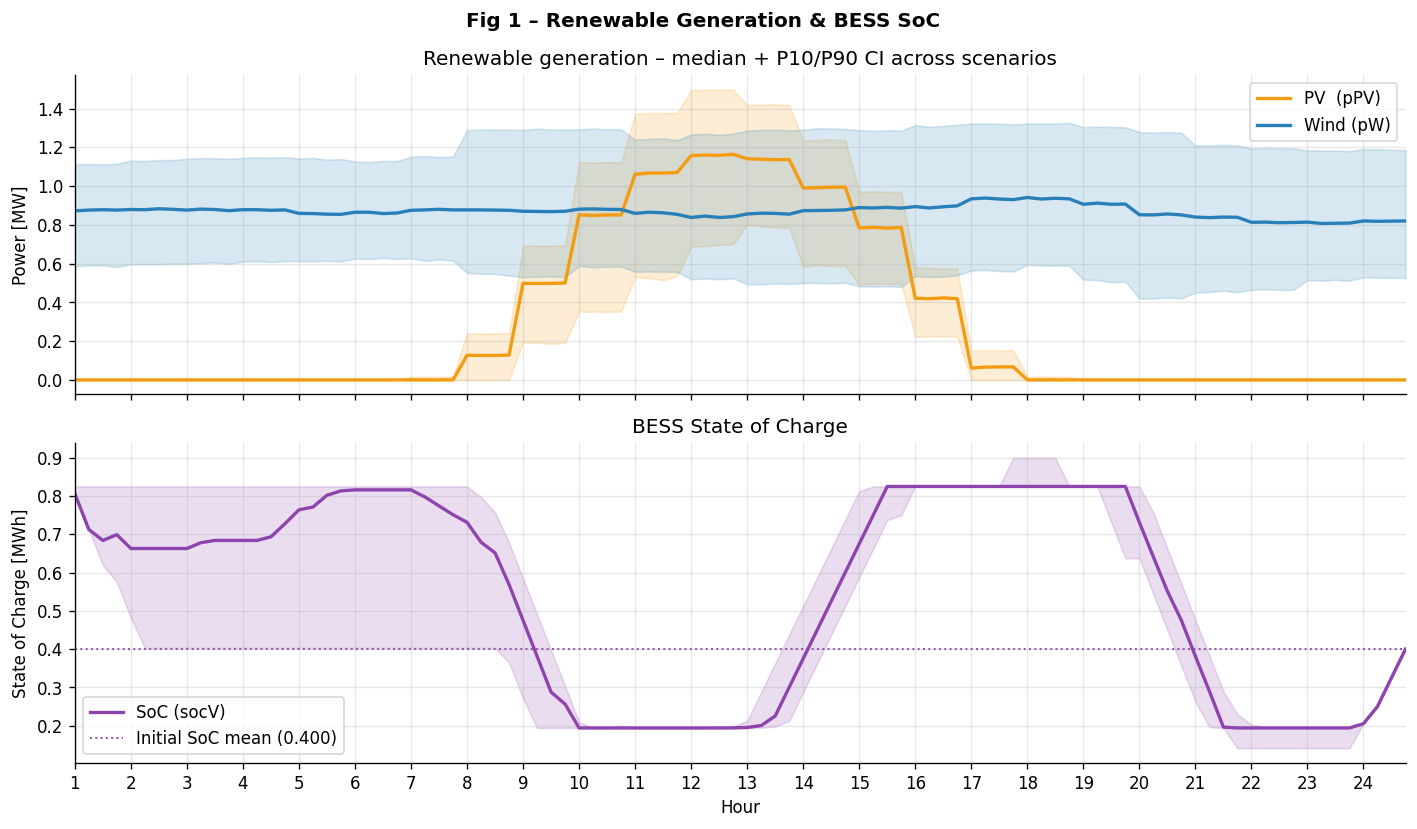

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 1 – Renewable Generation & BESS SoC", fontweight="bold")
t = _t(next(iter(data.values())))

if "pPV" in data: _band(ax1, t, data["pPV"], COLORS["pv"],   "PV  (pPV)")
if "pW"  in data: _band(ax1, t, data["pW"],  COLORS["wind"], "Wind (pW)")
ax1.set_ylabel("Power [MW]"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("Renewable generation – median + P10/P90 CI across scenarios")

if "socV" in data:
    _band(ax2, t, data["socV"], COLORS["bess"], "SoC (socV)")
    _annotate_socv_initial(ax2)
ax2.set_ylabel("State of Charge [MWh]"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("BESS State of Charge")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig1_generation"); plt.show()


## 5 · Fig 2 – BESS Operation (cV_dV & idV)

**What to look for:**
- `cV_dV > 0` → BESS is charging; `< 0` → discharging. Diverging colours make this instant to read.
- `idV` bar height → in what fraction of scenarios is the BESS actually dispatched to discharge at that hour.
- Discrepancy between median `cV_dV < 0` and low `idV` → some scenarios charge while others discharge (high uncertainty in dispatch decision).


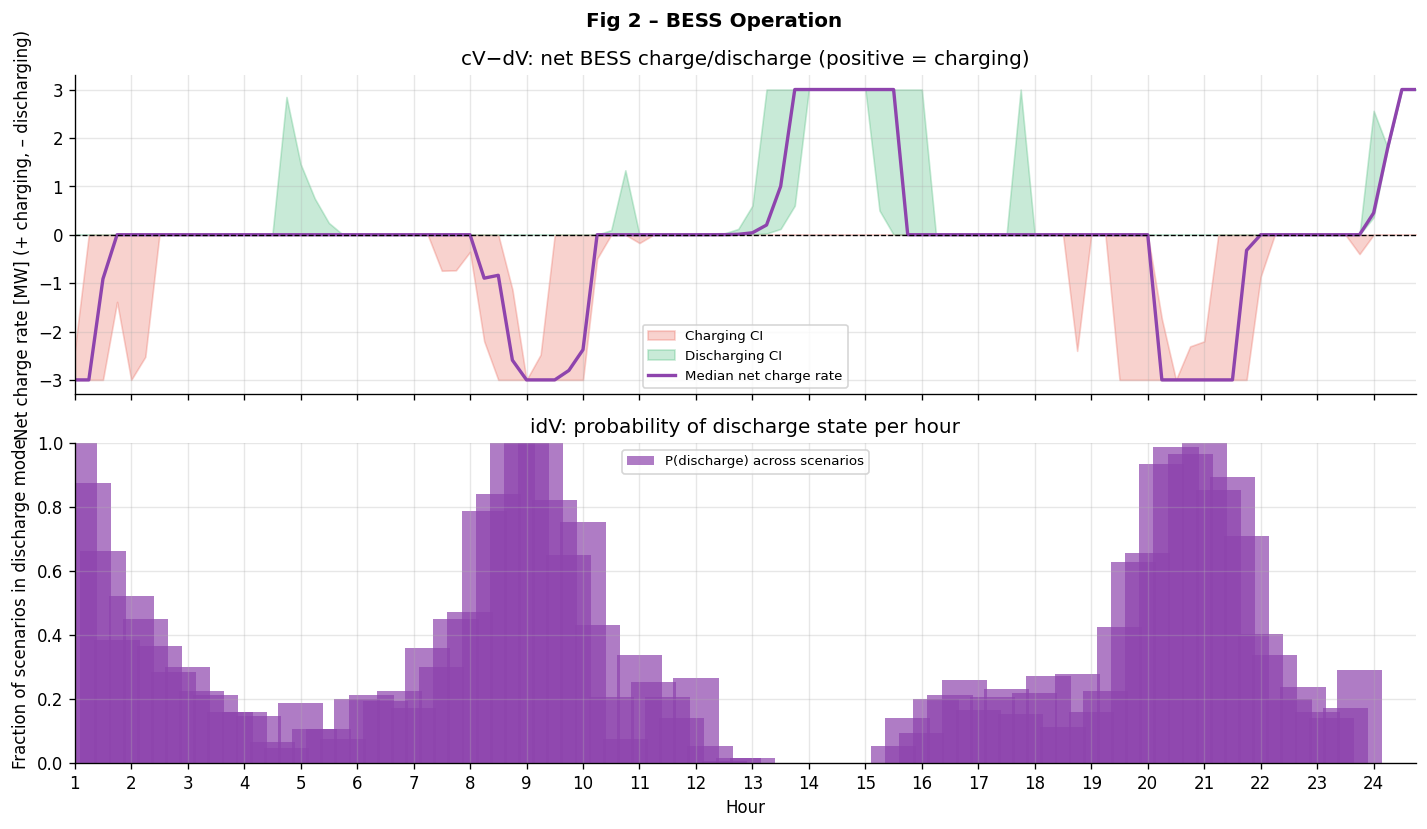

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 2 – BESS Operation", fontweight="bold")
t = _t(next(iter(data.values())))

if "cV_dV" in data:
    med, lo, hi = _ci(data["cV_dV"])
    ax1.fill_between(t, np.minimum(lo,0), np.minimum(hi,0), color=COLORS["neg"], alpha=0.25, label="Charging CI")
    ax1.fill_between(t, np.maximum(lo,0), np.maximum(hi,0), color=COLORS["pos"], alpha=0.25, label="Discharging CI")
    ax1.plot(t, med, color=COLORS["bess"], lw=2, label="Median net charge rate")
    ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("Net charge rate [MW] (+ charging, – discharging)")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("cV−dV: net BESS charge/discharge (positive = charging)")

if "idV" in data:
    ax2.bar(t, data["idV"].mean(axis=1), color=COLORS["bess"], alpha=0.7, label="P(discharge) across scenarios")
    ax2.set_ylim(0,1)
    ax2.set_ylabel("Fraction of scenarios in discharge mode")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
    ax2.set_title("idV: probability of discharge state per hour")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig2_bess_operation"); plt.show()


## 6 · Fig 3 – Flexible Demand

**What to look for:**
- Panel (a): total `var_fd` — does the EC smooth its demand effectively?
- Panel (b): mirrored `var_afd_p` / `var_afd_m` — are both shifts active simultaneously (arbitrage) or mutually exclusive?
- Panel (c): boxplot of **net shift** — wide boxes indicate high scenario uncertainty in how the FD is used. Outliers suggest extreme activation events.


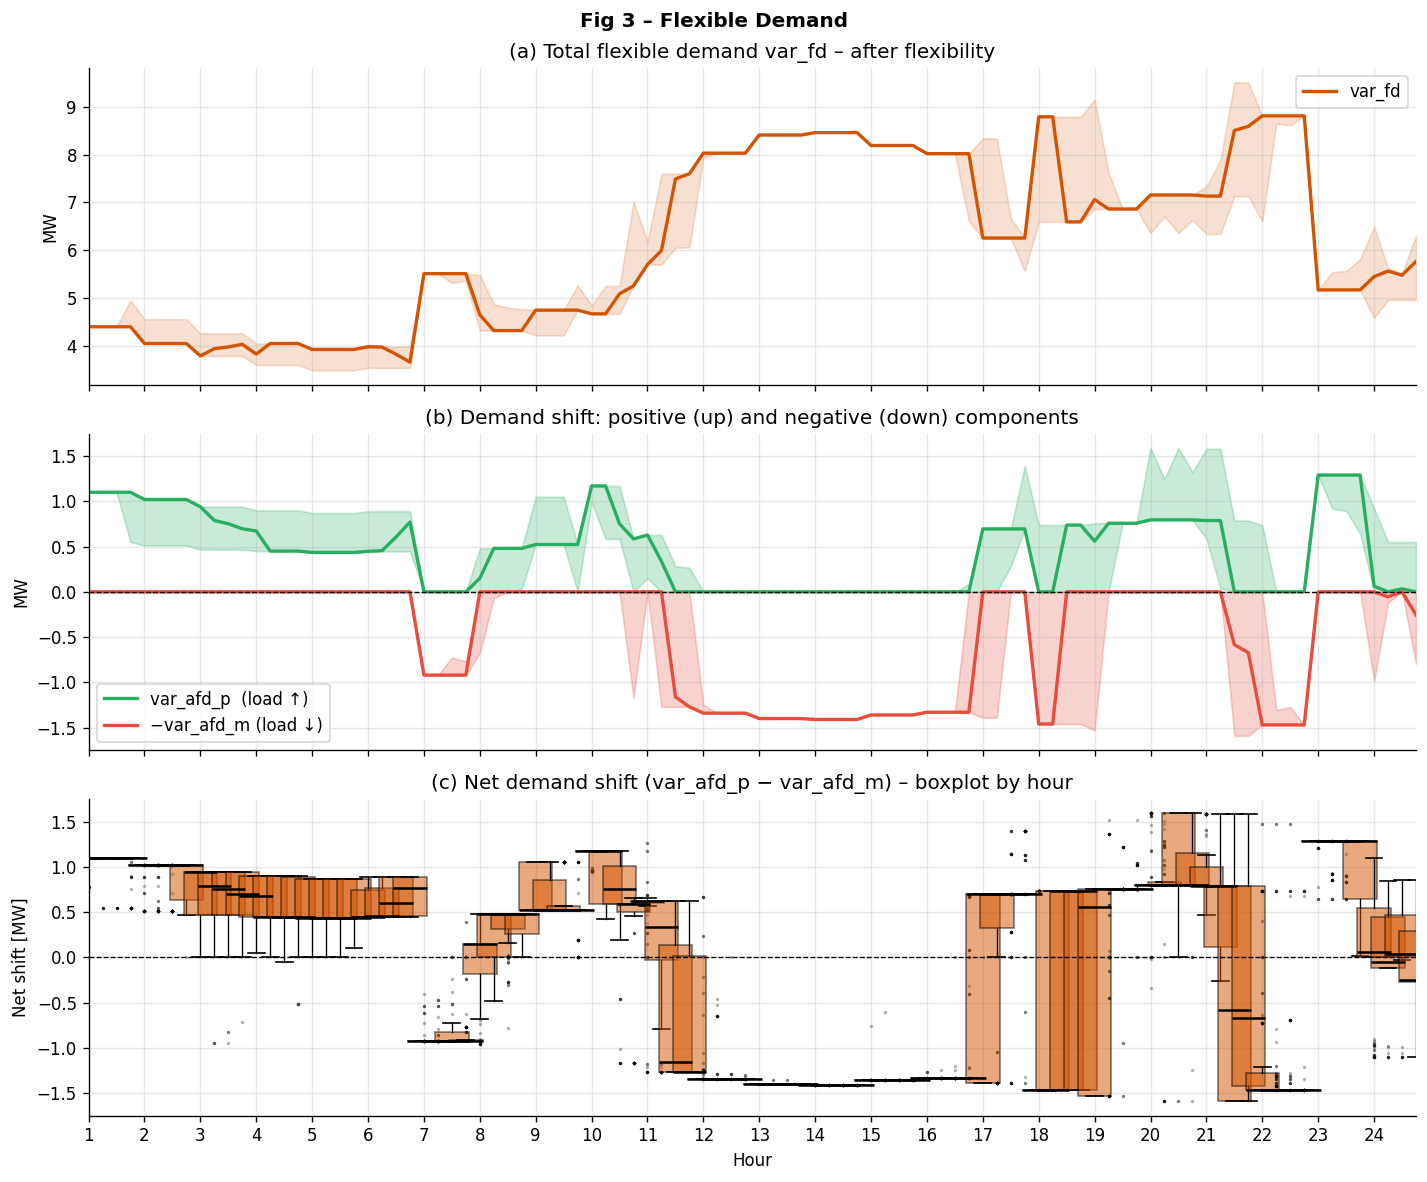

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 3 – Flexible Demand", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) total flexible demand
if "var_fd" in data:
    _band(ax1, t, data["var_fd"], COLORS["fd"], "var_fd")
ax1.set_ylabel("MW"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("(a) Total flexible demand var_fd – after flexibility")

# (b) positive / negative shifts mirrored
if "var_afd_p" in data and "var_afd_m" in data:
    med_p, lp, hp = _ci(data["var_afd_p"])
    med_m, lm, hm = _ci(data["var_afd_m"])
    ax2.fill_between(t,  lp,  hp, color=COLORS["pos"], alpha=0.25)
    ax2.plot(t, med_p, color=COLORS["pos"], lw=2, label="var_afd_p  (load ↑)")
    ax2.fill_between(t, -hm, -lm, color=COLORS["neg"], alpha=0.25)
    ax2.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−var_afd_m (load ↓)")
    ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.set_ylabel("MW"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("(b) Demand shift: positive (up) and negative (down) components")

# (c) net shift boxplot per hour
if "var_afd_p" in data and "var_afd_m" in data:
    net = (data["var_afd_p"] - data["var_afd_m"]).values
    ax3.boxplot([net[i,:] for i in range(len(t))],
                positions=t, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor=COLORS["fd"], alpha=0.5),
                medianprops=dict(color="k", lw=1.5),
                whiskerprops=dict(lw=0.8),
                flierprops=dict(marker=".", ms=2, alpha=0.3))
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("Net shift [MW]"); ax3.grid(alpha=0.3)
ax3.set_title("(c) Net demand shift (var_afd_p − var_afd_m) – boxplot by hour")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig3_flexible_demand"); plt.show()


## 7 · Fig 4 – Day-Ahead Commitment 
**What to look for:**
- **Panel (a):** committed energy in DA
- **Panel (b):** commited energy in RM
- **Panel (c):** commited energy in IM1
- **Panel (d):** commited energy in IM2
- **Panel (e):** commited energy in IM3


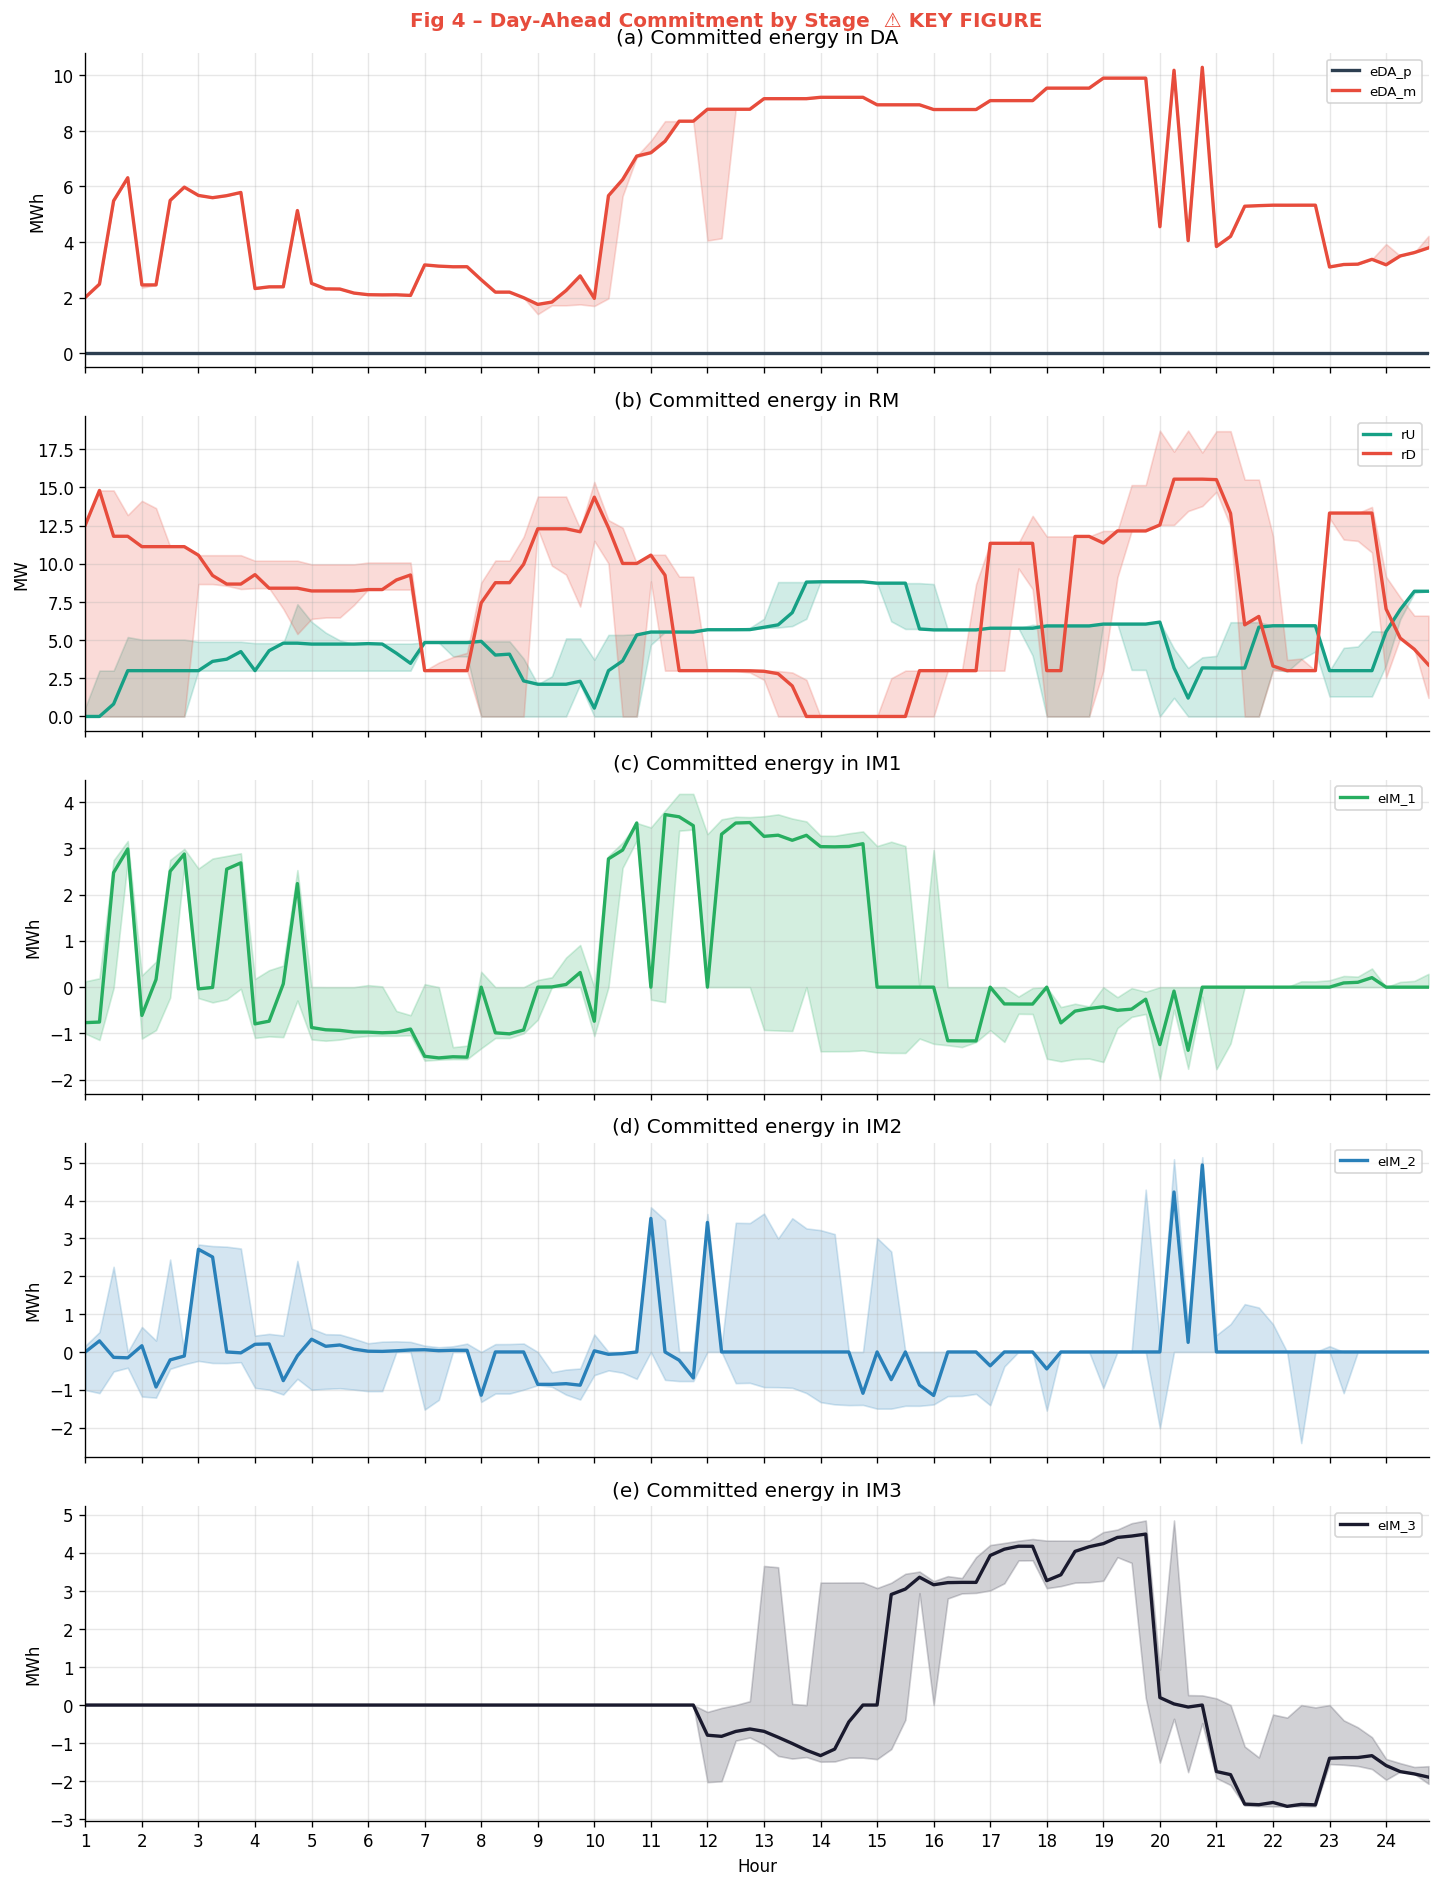

In [10]:
fig, axs = plt.subplots(5, 1, figsize=(12,16), sharex=True)
fig.suptitle("Fig 4 – Day-Ahead Commitment by Stage  ⚠️ KEY FIGURE",
             fontweight="bold", color=COLORS["neg"])
t = _t(next(iter(data.values())))

# (a) committed energy in DA
if "eDA_p" in data:
    med, lo, hi = _ci(data["eDA_p"])
    axs[0].fill_between(t, lo, hi, color=COLORS["da"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["da"], label="eDA_p")
if "eDA_m" in data:
    med, lo, hi = _ci(data["eDA_m"])
    axs[0].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["neg"], label="eDA_m")
axs[0].set_ylabel("MWh"); axs[0].legend(fontsize=8); axs[0].grid(alpha=0.3)
axs[0].set_title("(a) Committed energy in DA")

# (b) committed energy in RM
if "rU" in data:
    med, lo, hi = _ci(data["rU"])
    axs[1].fill_between(t, lo, hi, color=COLORS["reserve"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["reserve"], label="rU")
if "rD" in data:
    med, lo, hi = _ci(data["rD"])
    axs[1].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["neg"], label="rD")
axs[1].set_ylabel("MW"); axs[1].legend(fontsize=8); axs[1].grid(alpha=0.3)
axs[1].set_title("(b) Committed energy in RM")

# (c) committed energy in IM1
if "eIM_1" in data:
    med, lo, hi = _ci(data["eIM_1"])
    axs[2].fill_between(t, lo, hi, color=COLORS["pos"], alpha=0.2)
    axs[2].plot(t, med, lw=2, color=COLORS["pos"], label="eIM_1")
axs[2].set_ylabel("MWh"); axs[2].legend(fontsize=8); axs[2].grid(alpha=0.3)
axs[2].set_title("(c) Committed energy in IM1")

# (d) committed energy in IM2
if "eIM_2" in data:
    med, lo, hi = _ci(data["eIM_2"])
    axs[3].fill_between(t, lo, hi, color=COLORS["wind"], alpha=0.2)
    axs[3].plot(t, med, lw=2, color=COLORS["wind"], label="eIM_2")
axs[3].set_ylabel("MWh"); axs[3].legend(fontsize=8); axs[3].grid(alpha=0.3)
axs[3].set_title("(d) Committed energy in IM2")

# (e) committed energy in IM3
if "eIM_3" in data:
    med, lo, hi = _ci(data["eIM_3"])
    axs[4].fill_between(t, lo, hi, color=COLORS["median"], alpha=0.2)
    axs[4].plot(t, med, lw=2, color=COLORS["median"], label="eIM_3")
axs[4].set_ylabel("MWh"); axs[4].legend(fontsize=8); axs[4].grid(alpha=0.3)
axs[4].set_title("(e) Committed energy in IM3")
axs[4].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axs[4], t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig4_da_commitment"); plt.show()

## 8 · Fig 5 – Reserve Provision (Upward & Downward)

**What to look for:**
- Which asset (BESS vs FD) carries the bulk of reserve provision at each hour.
- Dashed total line vs. stacked area → if total > BESS + FD something is off (data check).
- Wide CI on the total reserve → significant scenario uncertainty in reserve matching.


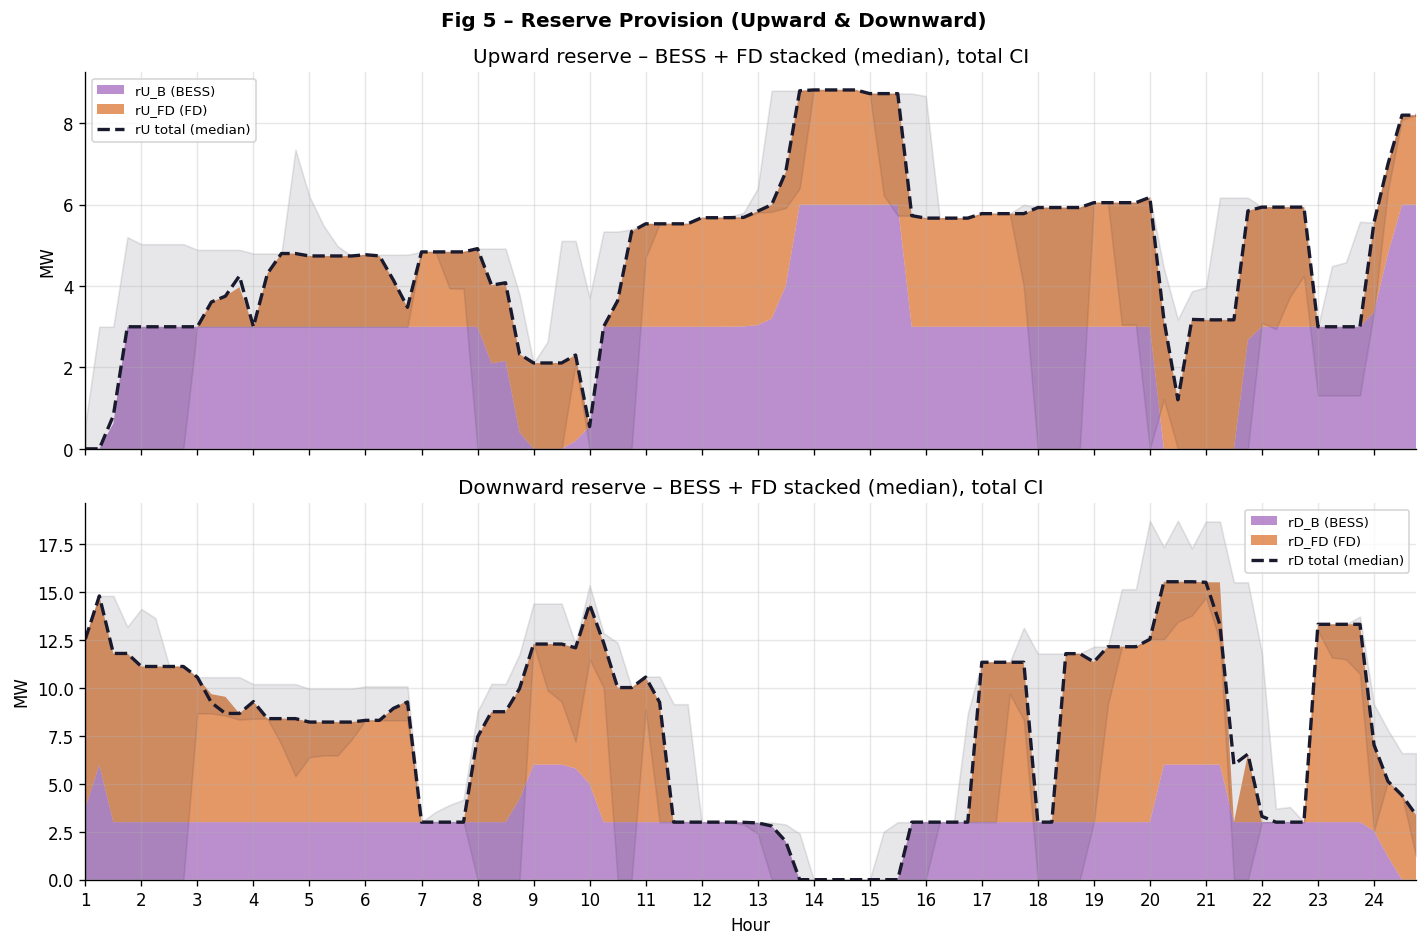

In [11]:
fig, (ax_u, ax_d) = plt.subplots(2, 1, figsize=(12,8), sharex=True)
fig.suptitle("Fig 5 – Reserve Provision (Upward & Downward)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, label, r_tot, r_b, r_fd in [
    (ax_u, "Upward",   "rU",  "rU_B",  "rU_FD"),
    (ax_d, "Downward", "rD",  "rD_B",  "rD_FD"),
]:
    med_b  = data[r_b ].median(axis=1).values if r_b  in data else np.zeros(len(t))
    med_fd = data[r_fd].median(axis=1).values if r_fd in data else np.zeros(len(t))
    ax.stackplot(t, med_b, med_fd,
                 labels=[f"{r_b} (BESS)", f"{r_fd} (FD)"],
                 colors=[COLORS["bess"], COLORS["fd"]], alpha=0.6)
    if r_tot in data:
        med_tot, lo, hi = _ci(data[r_tot])
        ax.plot(t, med_tot, color=COLORS["median"], lw=2, ls="--",
                label=f"{r_tot} total (median)")
        ax.fill_between(t, lo, hi, color=COLORS["median"], alpha=0.1)
    ax.set_ylabel("MW"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_title(f"{label} reserve – BESS + FD stacked (median), total CI")

ax_d.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax_d, t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig5_reserves"); plt.show()


## 9 · Fig 6 – Imbalance & Intraday Position ⚠️ KEY FIGURE

**What to look for:**
- **Panel (a):** mirrored pIB_p / pIB_m — does the EC mostly over-deliver or under-deliver?
- **Panel (b):** net imbalance bars — red hours = under-delivery (penalty exposure); green = over-delivery (spill or revenue).
- **Panel (c):** `eIM` — does intraday trading reduce imbalance at the same hours where panel (b) is red? If yes, the intraday market is effective.


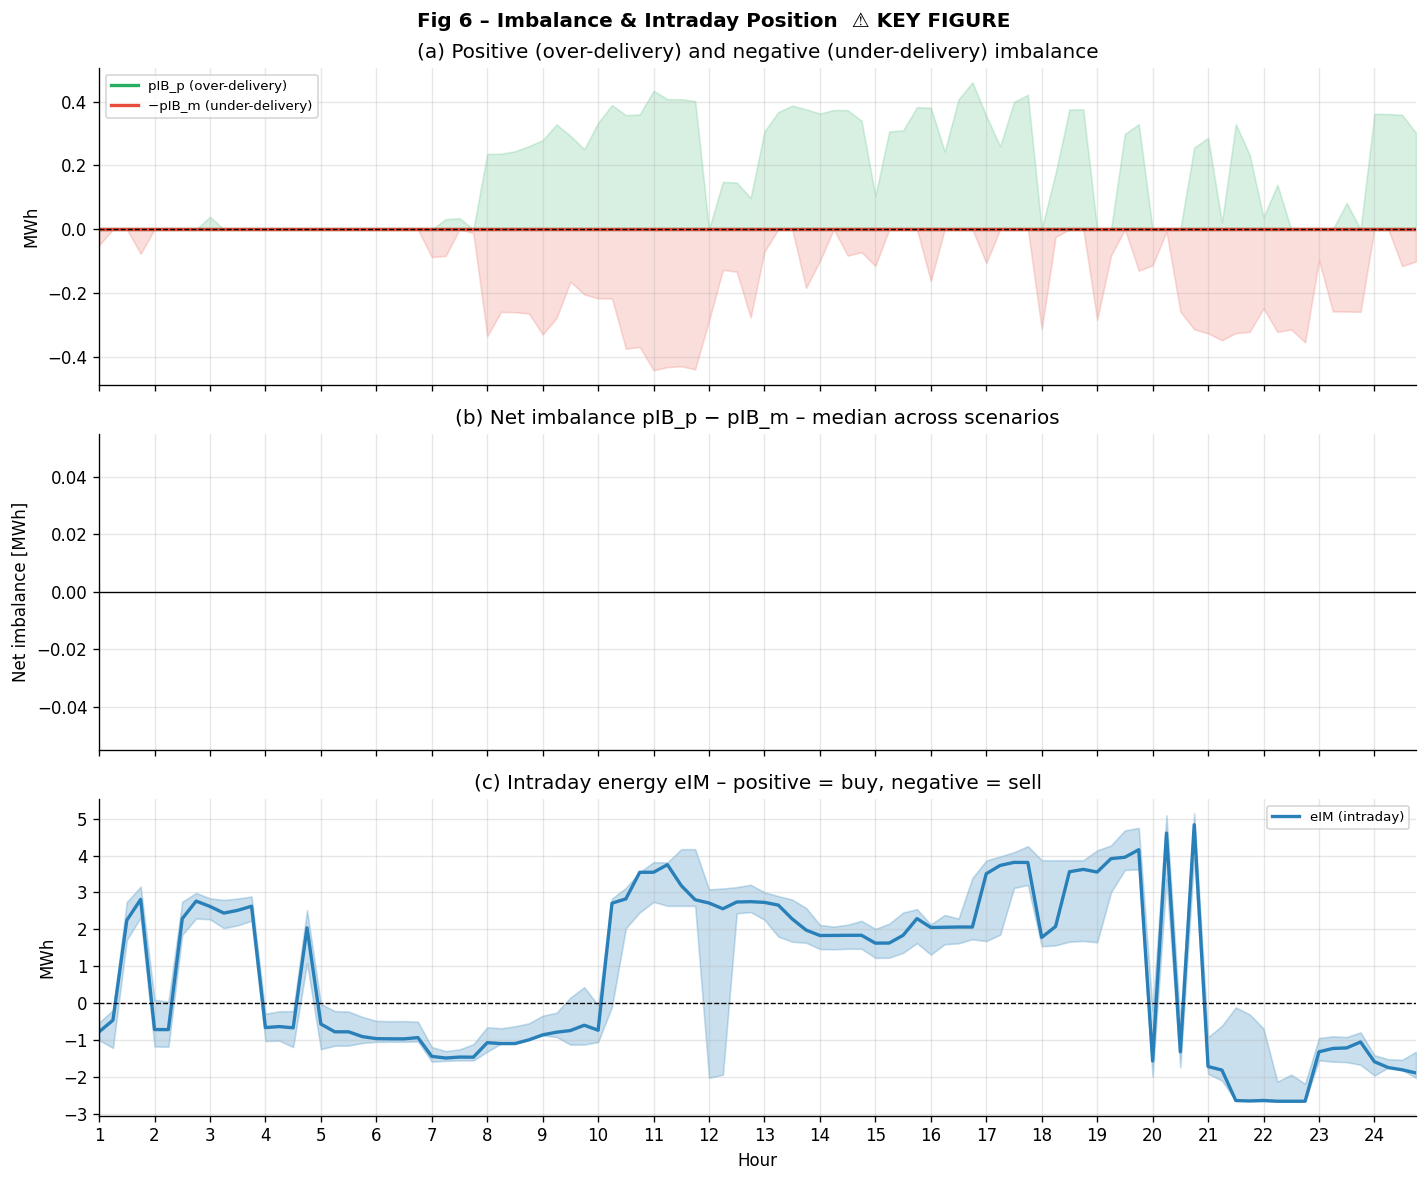

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 6 – Imbalance & Intraday Position  ⚠️ KEY FIGURE", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) pIB_p / pIB_m mirrored
if "pIB_p" in data:
    _band(ax1, t, data["pIB_p"], COLORS["pos"], "pIB_p (over-delivery)")
if "pIB_m" in data:
    med_m, lo_m, hi_m = _ci(data["pIB_m"])
    ax1.fill_between(t, -hi_m, -lo_m, color=COLORS["neg"], alpha=0.18)
    ax1.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−pIB_m (under-delivery)")
ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("MWh"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("(a) Positive (over-delivery) and negative (under-delivery) imbalance")

# (b) net imbalance bar
if "pIB_p" in data and "pIB_m" in data:
    net_med = (data["pIB_p"] - data["pIB_m"]).median(axis=1).values
    ax2.bar(t, net_med, color=[COLORS["pos"] if v>=0 else COLORS["neg"] for v in net_med], alpha=0.75)
    ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("Net imbalance [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Net imbalance pIB_p − pIB_m – median across scenarios")

# (c) eIM intraday
if "eIM" in data:
    med_im, lo_im, hi_im = _ci(data["eIM"])
    ax3.fill_between(t, lo_im, hi_im, color=COLORS["wind"], alpha=0.25)
    ax3.plot(t, med_im, color=COLORS["wind"], lw=2, label="eIM (intraday)")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("MWh"); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
ax3.set_title("(c) Intraday energy eIM – positive = buy, negative = sell")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig6_imbalance"); plt.show()


## 10 · Fig 7 – Scenario Fan Charts (spaghetti)

**What to look for:**
- Are traces clustered (low spread) or spread widely (high uncertainty)?
- Bimodal shapes → two distinct operating regimes across scenarios.
- Extreme outlier traces → which scenario drives the worst case?

> You can change `vars_to_show` to inspect any subset of variables.


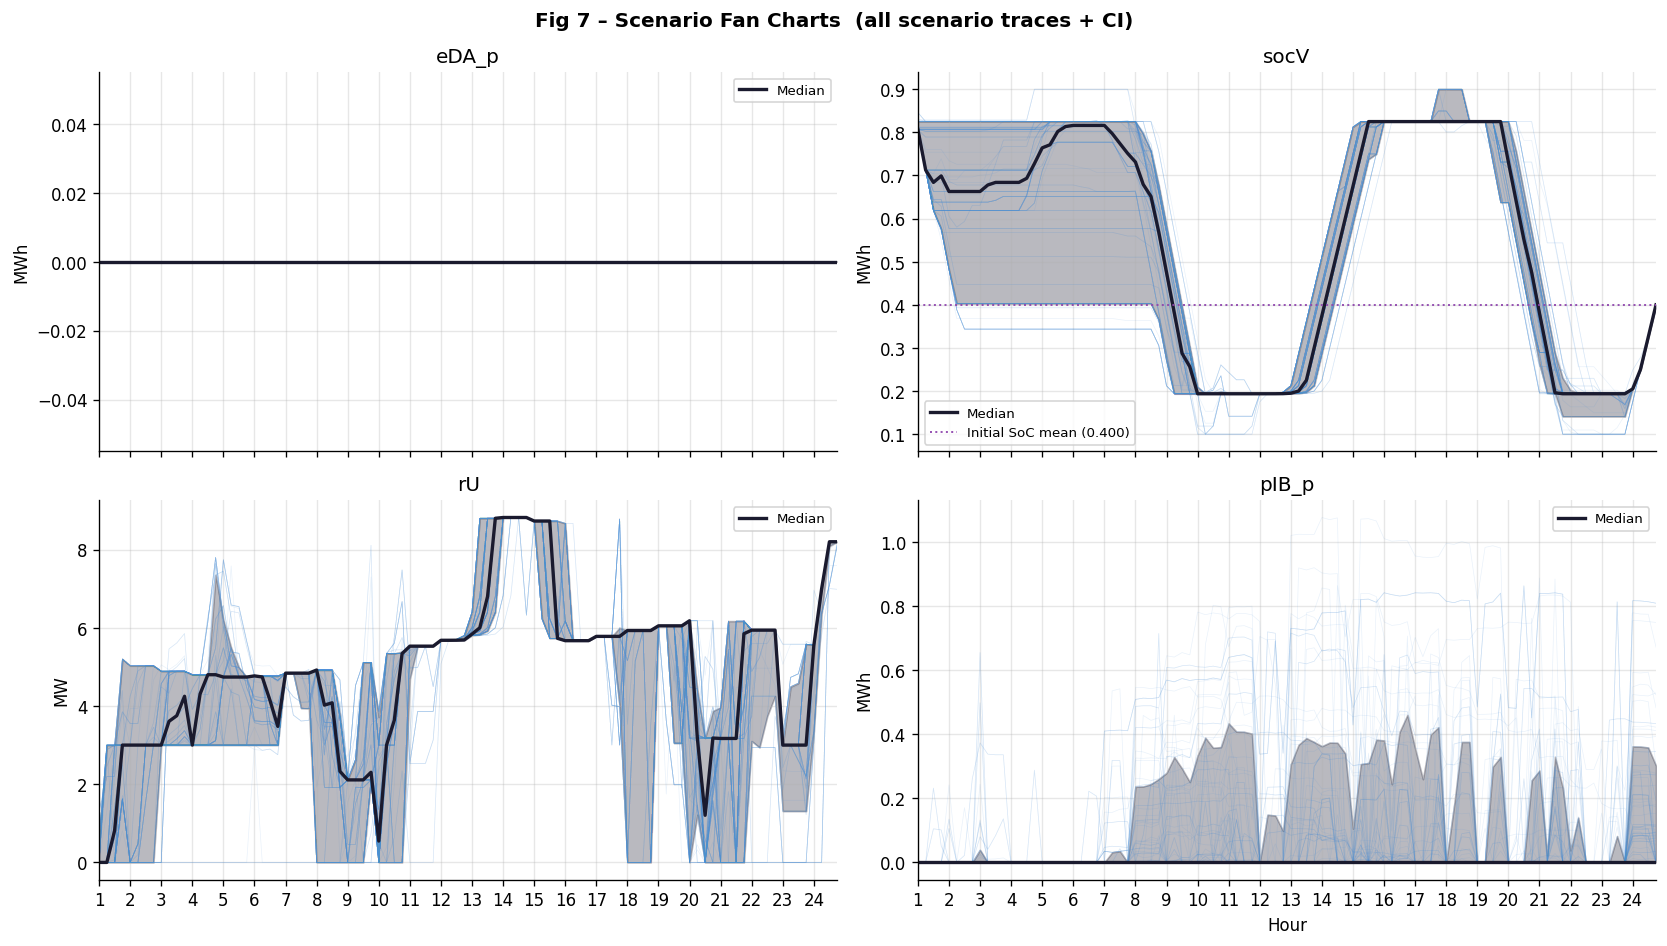

In [13]:
vars_to_show = ["eDA_p", "socV", "rU", "pIB_p"]   # ← edit here
vars_to_show = [v for v in vars_to_show if v in data]

ncols = 2
nrows = int(np.ceil(len(vars_to_show)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), sharex=True)
axes = np.array(axes).flatten()
fig.suptitle("Fig 7 – Scenario Fan Charts  (all scenario traces + CI)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, var in zip(axes, vars_to_show):
    df = data[var]
    for col in df.columns:
        ax.plot(t, df[col].values, color=COLORS["ci_fill"], lw=0.4, alpha=0.12)
    _band(ax, t, df, COLORS["median"], "Median", alpha=0.3)
    if var == "socV":
        _annotate_socv_initial(ax)
    ax.set_title(var); ax.set_ylabel(UNITS.get(var,"–")); ax.grid(alpha=0.3); ax.legend(fontsize=8)

for ax in axes[len(vars_to_show):]: ax.set_visible(False)
axes[-1].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axes[-1], t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig7_scenario_fans"); plt.show()


## 11 ? Market Benefit Distribution

Boxplot of total scenario benefit by market. CI markers show P10-P90 across scenarios.


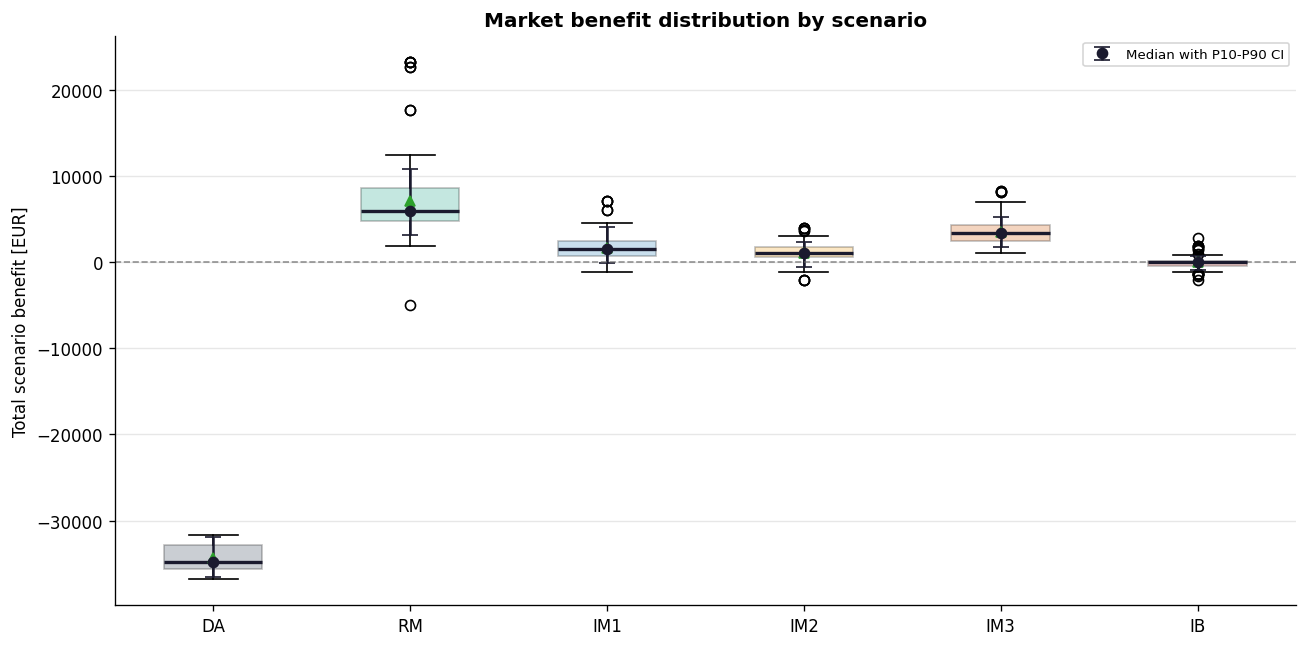

,median,P10,P90,mean
DA,-34826.9501,-36510.7811,-31922.6021,-34339.5020
RM,5903.5764,3190.0885,10846.6057,7132.1585
IM1,1482.4393,-156.8912,4054.5829,1641.1120
IM2,1079.9724,-621.3820,2331.9848,1072.7749
IM3,3353.9771,1757.5031,5276.7207,3521.8279
IB,-3.1917,-882.7197,741.5982,-33.1828


In [14]:
def _aligned_product_total(*dfs):
    dfs = [df for df in dfs if df is not None]
    if not dfs:
        return None
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    if len(common_index) == 0 or len(common_cols) == 0:
        return None
    prod = dfs[0].loc[common_index, common_cols].copy()
    for df in dfs[1:]:
        prod = prod * df.loc[common_index, common_cols]
    return prod.sum(axis=0)

market_benefits = {}

if {"lD", "eDA_p", "eDA_m"}.issubset(data):
    da_net = data["eDA_p"] - data["eDA_m"]
    market_benefits["DA"] = _aligned_product_total(data["lD"], da_net)

if {"lR", "rU", "rD"}.issubset(data):
    rm_reserve = data["rU"] + data["rD"]
    market_benefits["RM"] = _aligned_product_total(data["lR"], rm_reserve)

for i in [1, 2, 3]:
    li = f"lI_{i}"
    ei = f"eIM_{i}"
    if {li, ei}.issubset(data):
        market_benefits[f"IM{i}"] = _aligned_product_total(data[li], data[ei])

if {"lPIB", "pIB_p", "lNIB", "pIB_m"}.issubset(data):
    ib_income = _aligned_product_total(data["lPIB"], data["pIB_p"])
    ib_costs = _aligned_product_total(data["lNIB"], data["pIB_m"])
    if ib_income is not None and ib_costs is not None:
        common_cols = ib_income.index.intersection(ib_costs.index)
        market_benefits["IB"] = ib_income.loc[common_cols] - ib_costs.loc[common_cols]

market_order = ["DA", "RM", "IM1", "IM2", "IM3", "IB"]
market_benefits = {k: market_benefits[k].dropna() for k in market_order if k in market_benefits and market_benefits[k] is not None}

if not market_benefits:
    print("No market benefit data available for this run.")
else:
    labels = list(market_benefits.keys())
    values = [market_benefits[k].values for k in labels]
    positions = np.arange(1, len(labels) + 1)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bp = ax.boxplot(values, positions=positions, labels=labels, patch_artist=True, showmeans=True)
    for patch, color in zip(bp["boxes"], [COLORS["da"], COLORS["reserve"], COLORS["wind"], COLORS["pv"], COLORS["fd"], COLORS["imbal"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
    for med in bp["medians"]:
        med.set_color(COLORS["median"])
        med.set_linewidth(2)

    ci_low, ci_high = CONFIG["ci_low"], CONFIG["ci_high"]
    medians = np.array([np.median(v) for v in values])
    lo = np.array([np.percentile(v, ci_low) for v in values])
    hi = np.array([np.percentile(v, ci_high) for v in values])
    ax.errorbar(positions, medians, yerr=[medians - lo, hi - medians], fmt="o",
                color=COLORS["median"], ecolor=COLORS["median"], capsize=5,
                label=f"Median with P{ci_low}-P{ci_high} CI")
    ax.axhline(0, color="#666666", lw=1, ls="--", alpha=0.7)
    ax.set_ylabel("Total scenario benefit [EUR]")
    ax.set_title("Market benefit distribution by scenario", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout(); _save(fig, "fig_market_benefits_boxplot"); plt.show()

    benefit_summary = pd.DataFrame({
        "median": medians,
        f"P{ci_low}": lo,
        f"P{ci_high}": hi,
        "mean": [np.mean(v) for v in values],
    }, index=labels)
    display(benefit_summary)


## 11 · Fig 8 – Correlation Heatmap

**What to look for:**
- Strong positive correlation (dark blue) between PV/Wind and reserve/FD → renewable surplus drives reserve provision.
- Strong negative correlation between `socV` and `pIB_m` → better SoC management reduces imbalance penalties.
- Any unexpected high correlation that reveals hidden structural coupling in the model.


Excluded constant variables from correlation heatmap: ['eDA_p', 'ieDA_m', 'ieDA_p', 'pIB_m', 'pIB_p']
Correlation heatmap uses 28 operational variables with shared index 96 time points.


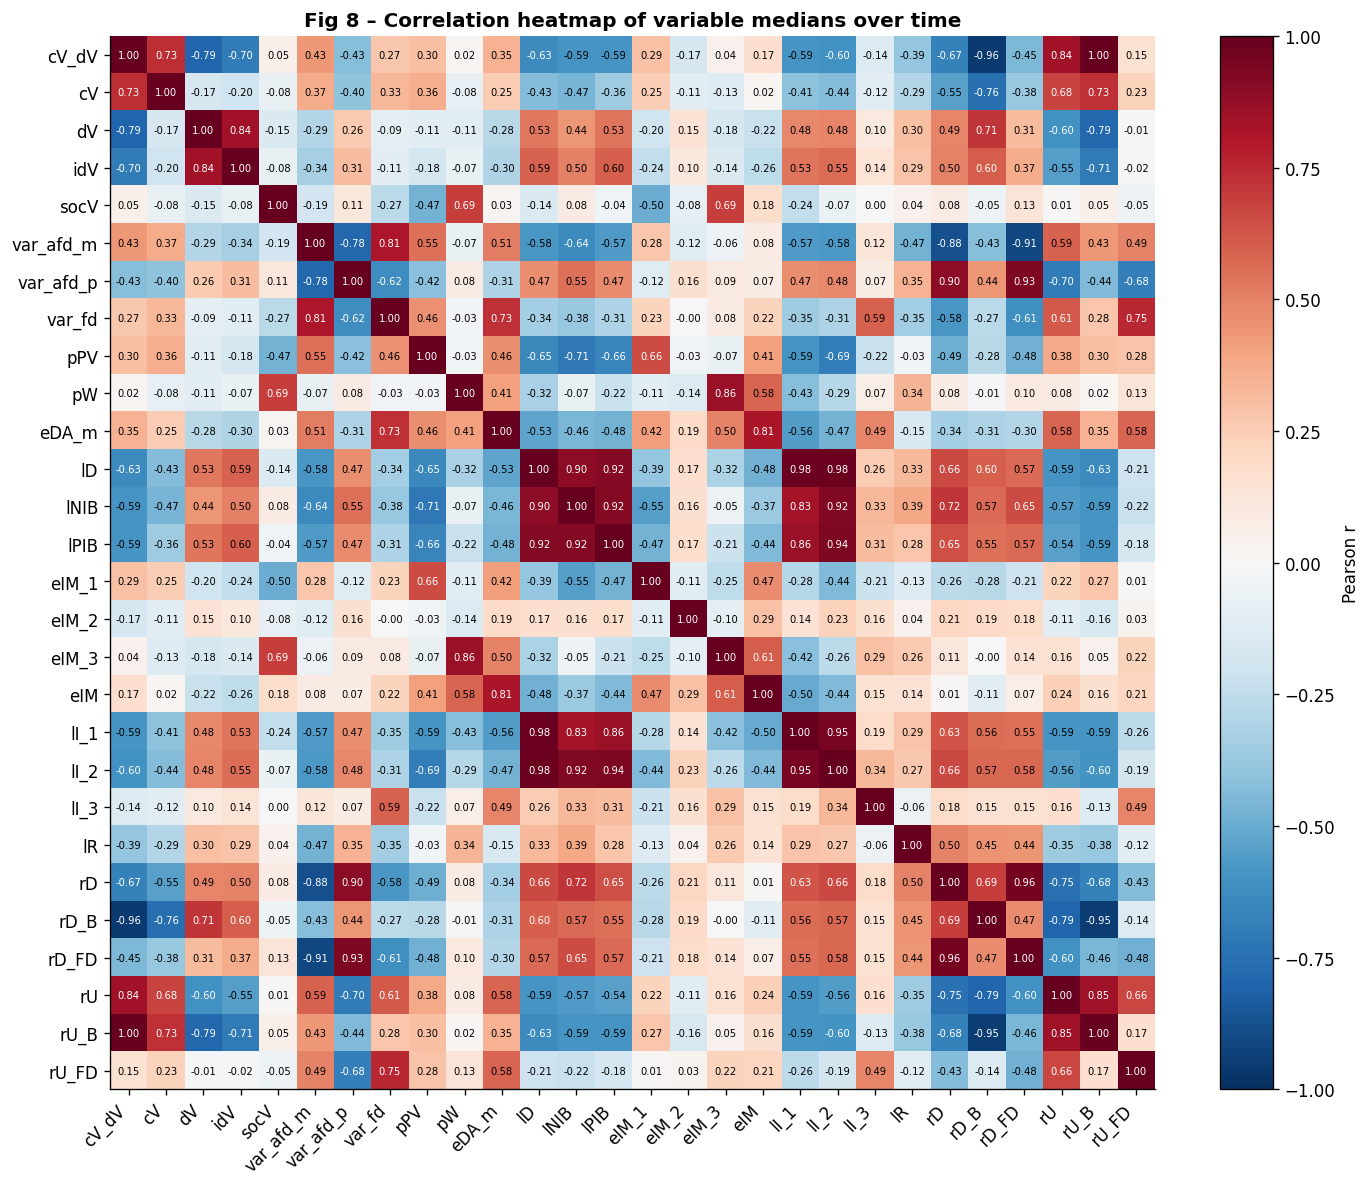

In [15]:
op_data = _operational_ts_data(data)
med_df = pd.DataFrame({v: df.median(axis=1) for v, df in op_data.items()})
empty_vars = med_df.columns[med_df.isna().all()].tolist()
if empty_vars:
    print("Dropped empty variables from correlation heatmap:", empty_vars)
med_df = med_df.dropna(axis=1, how="all")
std = med_df.std(axis=0)
constant_vars = std[std <= 1e-12].index.tolist()
if constant_vars:
    print("Excluded constant variables from correlation heatmap:", constant_vars)
med_df = med_df.loc[:, std > 1e-12]
corr = med_df.corr(min_periods=2)
if corr.isna().any().any():
    print("Warning: correlation contains NaN values due to insufficient data for some variable pairs. NaN values are preserved.")
print(f"Correlation heatmap uses {med_df.shape[1]} operational variables with shared index {med_df.shape[0]} time points.")

fig, ax = plt.subplots(figsize=(12,10))
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#d3d3d3")
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i,j]
        text = f"{val:.2f}" if not np.isnan(val) else "NaN"
        color = "white" if not np.isnan(val) and abs(val) > 0.6 else "black"
        ax.text(j, i, text, ha="center", va="center",
                fontsize=6, color=color)
ax.set_title("Fig 8 – Correlation heatmap of variable medians over time", fontweight="bold")
plt.tight_layout(); _save(fig, "fig8_correlation"); plt.show()


## 12 · Fig 9 – Commitment Failure Dashboard ⚠️ KEY FIGURE

One-page answer to *"when and how severely did the EC miss its day-ahead commitments?"*

| Sub-panel | What it shows |
|---|---|
| **(a) Risk strip** | colour = fraction of scenarios with `pIB_m > 0`; red hours = most risky |
| **(b) Shortfall bars** | median magnitude of `pIB_m` (CI band) |
| **(c) Delivered power** | actual delivered power from `pPV + pW - cV_dV` when available; otherwise show `pIB_m` under-delivery proxy |
| **(d) CDF** | cumulative distribution of total daily under-delivery across all scenarios; P90 marks the tail risk |


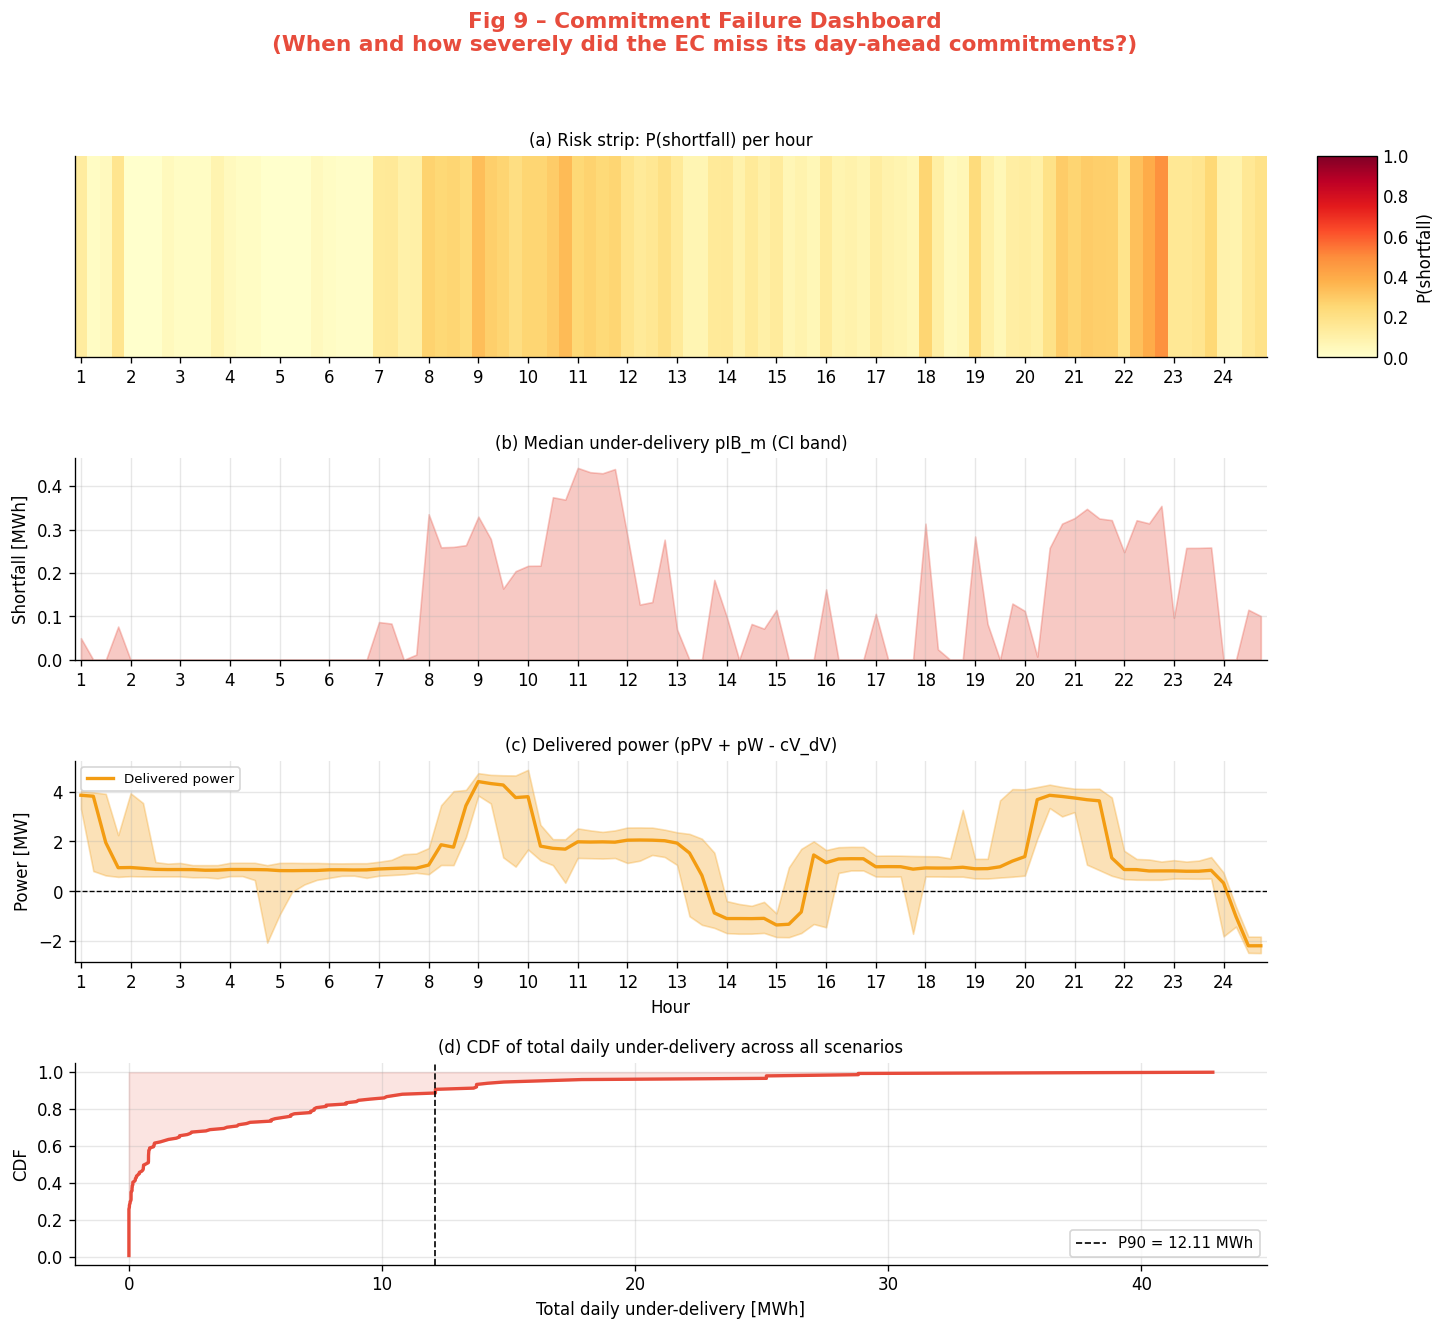

In [16]:
fig = plt.figure(figsize=(14,12))
fig.suptitle("Fig 9 – Commitment Failure Dashboard\n"
             "(When and how severely did the EC miss its day-ahead commitments?)",
             fontweight="bold", color=COLORS["neg"], fontsize=13)

gs = gridspec.GridSpec(4, 2, width_ratios=[20, 1], wspace=0.08, hspace=0.5)
ax1 = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax4 = fig.add_subplot(gs[3, 0])

t_arr = _t(next(iter(data.values())))
T = len(t_arr)
step = float(np.min(np.diff(t_arr))) if len(t_arr) > 1 else 1.0
x_edges = np.concatenate([t_arr - step/2, [t_arr[-1] + step/2]])
bar_width = min(0.8, step * 0.9)

# (a) risk heat-strip
prob = np.zeros(T)
if "pIB_m" in data:
    prob = (data["pIB_m"] > 1e-6).mean(axis=1).values
heat = ax1.pcolormesh(x_edges, [0, 1], prob[None, :], cmap="YlOrRd",
                      vmin=0, vmax=1, shading="auto")
fig.colorbar(heat, cax=cax, orientation="vertical")
cax.set_ylabel("P(shortfall)")
cax.yaxis.set_label_position("right")
cax.tick_params(axis="both", which="both", length=0)
ax1.set_yticks([])
ax1.set_title("(a) Risk strip: P(shortfall) per hour", fontsize=10)
ax1.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
ax1.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
ax1.set_xlim(x_edges[0], x_edges[-1])

# (b) shortfall bars
if "pIB_m" in data:
    med, lo, hi = _ci(data["pIB_m"])
    ax2.fill_between(t_arr, lo, hi, color=COLORS["neg"], alpha=0.3)
    ax2.bar(t_arr, med, color=COLORS["neg"], alpha=0.7, width=bar_width)
ax2.set_ylabel("Shortfall [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Median under-delivery pIB_m (CI band)", fontsize=10)

# (c) delivered power
if {"pPV", "pW", "cV_dV"}.issubset(data):
    delivered = data["pPV"] + data["pW"] - data["cV_dV"]
    med_del, lo_del, hi_del = _ci(delivered)
    ax3.fill_between(t_arr, lo_del, hi_del, color=COLORS["pv"], alpha=0.3)
    ax3.plot(t_arr, med_del, color=COLORS["pv"], lw=2, label="Delivered power")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
    ax3.set_ylabel("Power [MW]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Delivered power (pPV + pW - cV_dV)", fontsize=10)
else:
    if "pIB_m" in data:
        med_ib, lo_ib, hi_ib = _ci(data["pIB_m"])
        ax3.fill_between(t_arr, lo_ib, hi_ib, color=COLORS["imbal"], alpha=0.3)
        ax3.plot(t_arr, med_ib, color=COLORS["imbal"], lw=2, label="pIB_m median")
    ax3.set_ylabel("pIB_m [MWh]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Negative imbalance pIB_m – proxy for under-delivery cost", fontsize=10)

# (d) CDF of total daily under-delivery
if "pIB_m" in data:
    sf_tot = data["pIB_m"].sum(axis=0).values
    sf_s   = np.sort(sf_tot)
    cdf    = np.arange(1,len(sf_s)+1)/len(sf_s)
    ax4.plot(sf_s, cdf, color=COLORS["neg"], lw=2)
    ax4.fill_betweenx(cdf, 0, sf_s, color=COLORS["neg"], alpha=0.15)
    p90 = np.percentile(sf_s,90)
    ax4.axvline(p90, color="k", ls="--", lw=1, label=f"P90 = {p90:.2f} MWh")
    ax4.set_xlabel("Total daily under-delivery [MWh]")
    ax4.set_ylabel("CDF"); ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
    ax4.set_title("(d) CDF of total daily under-delivery across all scenarios", fontsize=10)
else:
    ax4.text(0.5, 0.5, "No pIB_m data available for daily under-delivery CDF",
             ha="center", va="center", transform=ax4.transAxes)
    ax4.set_axis_off()

_save(fig, "fig9_commitment_dashboard"); plt.show()

## 13 · Export Descriptive Statistics to CSV

In [17]:
if CONFIG["save_figs"]:
    os.makedirs(CONFIG["fig_dir"], exist_ok=True)
    out = os.path.join(CONFIG["fig_dir"], "descriptive_stats.csv")
    summary.to_csv(out)
    print(f"Saved → {out}")
else:
    print("Set CONFIG['save_figs'] = True to export.")


Saved → figures/same_ren/descriptive_stats.csv


# MSSP Results Analyzer — Different-Ren (sc=170 → 146 reduced scenarios)
*Matched-reduced-scenario comparison, method B of 2 — see intro above. Reduced scenarios in model: **146** (from 170 original).*
### Energy System Market Analysis

**Variables:**
| Group | Variables |
|---|---|
| Flexible Demand | `var_fd`, `var_afd_p`, `var_afd_m` |
| Generation | `pPV`, `pW` |
| BESS | `cV_dV` (net charge rate), `idV` (state), `socV` (SoC) |
| Day-Ahead | `eDA_p`, `eDA_m`, `ieDA_p`, `ieDA_m` |
| Reserves | `rU`, `rD`, `rU_B`, `rD_B`, `rU_FD`, `rD_FD` |
| Imbalance | `eIM`, `eIM1`,`eIM2`, `eIM3`, `pIB_m`, `pIB_p` |

**Data format expected:** one CSV per variable — rows = time steps, columns = scenarios.  
CI bands show P10–P90 across scenarios unless otherwise noted.


## 0 · Imports & Setup

In [18]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
print("Libraries loaded ✓")


Libraries loaded ✓


## 1 · Configuration

Edit the block below to point to your data. Three loading modes are supported:
- **Option A** – one CSV per variable (rows = timesteps, cols = scenarios) → set `data_dir`
- **Option B** – single wide CSV with `(variable, scenario)` MultiIndex columns → set `single_csv`
- **Option C** – HDF5 store with variable names as keys → set `hdf5_file`

If no files are found the script falls back to **synthetic data** so every cell runs out-of-the-box.


In [19]:
CONFIG = dict(
    # ── Data location ─────────────────────────────────────────────────────
    data_dir   = "../../QHS/results/FTC_20251031_20251130_c31_sc170_15min_different_ren/DA",
    file_ext   = ".txt",       # Option A: folder with one TXT per variable (nested dirs allowed)
    single_csv = None,         # Option B: path to wide CSV
    hdf5_file  = None,         # Option C: path to HDF5

    # ── Time axis ─────────────────────────────────────────────────────────
    n_periods    = 24,         # number of time steps (e.g. 24 h)
    period_label = "Hour",     # x-axis label

    # ── CI percentiles ────────────────────────────────────────────────────
    ci_low  = 10,
    ci_high = 90,

    # ── Save figures ──────────────────────────────────────────────────────
    save_figs  = True,         # set True to export PNGs
    fig_dir    = "figures/dif_ren/",
    fig_format = "png",
    dpi        = 150,
)

UNITS = {
    "var_fd":"MW",  "var_afd_p":"MW",  "var_afd_m":"MW",
    "pPV":"MW",     "pW":"MW",
    "cV_dV":"MW",   "idV":"–",         "socV":"MWh",
    "eDA_p":"MWh",  "eDA_m":"MWh",     "ieDA_p":"MWh",  "ieDA_m":"MWh",
    "rU":"MW",      "rD":"MW",
    "rU_B":"MW",    "rD_B":"MW",       "rU_FD":"MW",    "rD_FD":"MW",
    "eIM":"MWh", "eIM_1":"MWh", "eIM_2":"MWh", "eIM_3":"MWh",    "pIB_m":"MWh",     "pIB_p":"MWh",
}

COLORS = dict(
    median="#1a1a2e", ci_fill="#4a90d9",
    pos="#27ae60",    neg="#e74c3c",
    bess="#8e44ad",   pv="#f39c12",
    wind="#2980b9",   reserve="#16a085",
    imbal="#c0392b",  fd="#d35400",
    da="#2c3e50",
)
print("Configuration set ✓")


Configuration set ✓


## 2 · Data Loader

In [20]:
def _synthetic_data(cfg):
    """Fallback synthetic data – replace with real loader if needed."""
    rng = np.random.default_rng(42)
    T, S = cfg["n_periods"], 50
    t = np.linspace(0, 2*np.pi, T)
    scen = [f"s{i:03d}" for i in range(S)]
    data = {}

    def _df(base, noise=0.15, lo=None, hi=None):
        mat = base[:,None] + rng.normal(0, noise*(np.abs(base).mean()+0.01), (T,S))
        if lo is not None: mat = np.clip(mat, lo, None)
        if hi is not None: mat = np.clip(mat, None, hi)
        return pd.DataFrame(mat, columns=scen)

    solar = np.maximum(0, np.sin(t - np.pi/3))
    wind  = 0.4 + 0.3*np.sin(2*t + 0.5)
    dem   = 1.0 + 0.4*np.sin(t - np.pi/2)
    sf_b  = np.where(rng.random(T) > 0.75, rng.uniform(0,0.3,T), 0)

    data["pPV"]      = _df(solar*2.0, lo=0)
    data["pW"]       = _df(wind*1.5,  lo=0)
    data["socV"]     = _df(0.5+0.3*np.sin(t), noise=0.05, lo=0, hi=1.0)
    data["cV_dV"]    = _df(0.3*np.sin(t+1.0), noise=0.2)
    data["idV"]      = pd.DataFrame((rng.random((T,S))>0.5).astype(float), columns=scen)
    data["var_fd"]   = _df(dem, lo=0)
    data["var_afd_p"]= _df(np.abs(0.1*np.sin(t)), lo=0)
    data["var_afd_m"]= _df(np.abs(0.1*np.cos(t)), lo=0)
    eDA              = dem*0.9
    data["eDA_p"]    = _df(eDA, lo=0)
    data["eDA_m"]    = _df(eDA*0.1, lo=0)
    data["ieDA_p"]   = _df(sf_b, noise=0.3, lo=0)
    data["ieDA_m"]   = _df(sf_b*0.5, noise=0.3, lo=0)
    data["rU"]       = _df(0.2+0.1*np.sin(t), lo=0)
    data["rD"]       = _df(0.2+0.1*np.cos(t), lo=0)
    data["rU_B"]     = _df(0.1*np.abs(np.sin(t)), lo=0)
    data["rD_B"]     = _df(0.1*np.abs(np.cos(t)), lo=0)
    data["rU_FD"]    = _df(0.1*np.abs(np.sin(t+0.5)), lo=0)
    data["rD_FD"]    = _df(0.1*np.abs(np.cos(t+0.5)), lo=0)
    data["eIM"]      = _df(0.05*np.sin(3*t))
    data["pIB_p"]    = _df(sf_b*0.8, noise=0.4, lo=0)
    data["pIB_m"]    = _df(sf_b*0.6, noise=0.4, lo=0)
    return data

def load_data(cfg):
    data = {}
    if cfg.get("hdf5_file") and os.path.exists(cfg["hdf5_file"]):
        with pd.HDFStore(cfg["hdf5_file"], mode="r") as s:
            for k in s.keys():
                data[k.lstrip("/").replace("-","_")] = s[k]
        return data
    if cfg.get("single_csv") and os.path.exists(cfg["single_csv"]):
        wide = pd.read_csv(cfg["single_csv"], header=[0,1], index_col=0)
        for v in wide.columns.get_level_values(0).unique():
            data[v.replace("-","_")] = wide[v]
        return data
    files = glob.glob(os.path.join(cfg["data_dir"], "**", f"*{cfg['file_ext']}"), recursive=True)
    if not files:
        print("⚠️  No result files found – using SYNTHETIC data.")
        return _synthetic_data(cfg)

    # MMOBEC 15-min block files: one scenario is stored as n_periods rows.
    # First row of each block starts with: scenario probability q1 q2 ... qN.
    BLOCK_TXT_VARS = {
        "lPIB", "lNIB", "pIB_p", "pIB_m", "lI_1", "lI_2", "lI_3",
        "eDA_p", "eDA_m", "pW", "pPV", "dV", "cV", "var_fd", "eIM",
        "eIM_1", "eIM_2", "eIM_3",
    }

    def _scen_name(val):
        try:
            return f"s{int(float(val)):03d}"
        except Exception:
            return str(val)

    def _wide_from_matrix(values, scen_names, n_q=None):
        values = values.astype(float).T
        values.columns = scen_names
        n_t_cfg = int(cfg.get("n_periods", 24))
        if n_q is None and values.shape[0] % n_t_cfg == 0:
            n_q = values.shape[0] // n_t_cfg
        if n_q and values.shape[0] % n_q == 0:
            n_t = values.shape[0] // n_q
            values.index = pd.MultiIndex.from_tuples(
                [(t, q) for t in range(1, n_t + 1) for q in range(1, n_q + 1)],
                names=["t", "q"],
            )
        else:
            values.index = np.arange(1, values.shape[0] + 1)
        return values

    def _load_block_txt(path, name):
        rows = []
        with open(path, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if line and not line.startswith("#"):
                    rows.append(line.split())
        if not rows:
            return None

        n_t = int(cfg.get("n_periods", 24))
        i = 0
        scen_names, vectors = [], []
        while i < len(rows):
            header = rows[i]
            if len(header) < 3 or i + n_t > len(rows):
                return None
            scenario = header[0]
            first_period_values = [float(x) for x in header[2:]]
            n_q = len(first_period_values)
            vector = first_period_values[:]

            for j in range(1, n_t):
                period_values = [float(x) for x in rows[i + j]]
                if len(period_values) != n_q:
                    return None
                vector.extend(period_values)

            scen_names.append(_scen_name(scenario))
            vectors.append(vector)
            i += n_t

        cfg.setdefault("_txt_subperiods", {})[name] = n_q
        return _wide_from_matrix(pd.DataFrame(vectors, index=scen_names), scen_names, n_q=n_q)

    def _load_txt(path, name):
        if name in BLOCK_TXT_VARS:
            block_df = _load_block_txt(path, name)
            if block_df is not None:
                return block_df

        df = pd.read_csv(path, sep=r"\s+", header=None, comment="#", engine="python")
        if df.shape[1] <= 2 or df.shape[0] < 2:
            return None
        scen_names = [_scen_name(v) for v in df.iloc[:, 0]]
        values = df.iloc[:, 2:].astype(float)
        return _wide_from_matrix(values, scen_names)

    for f in sorted(files):
        base = os.path.splitext(os.path.basename(f))[0]
        if base.endswith("_params") or base in {"numscen", "profit_ec", "time_ec", "pIB_p-pIB_m", "solver_log", "scenarios", "tree"}:
            continue
        name = base.replace("-","_")
        if name == "eIM_TOT":
            name = "eIM"

        df = _load_txt(f, name)
        if df is None:
            continue
        data[name] = df
    return data

# ── helpers ──────────────────────────────────────────────────────────────────
def _t(df):
    if isinstance(df.index, pd.MultiIndex) and {"t", "q"}.issubset(df.index.names):
        t_vals = df.index.get_level_values("t").astype(float).to_numpy()
        q_vals = df.index.get_level_values("q").astype(float).to_numpy()
        n_q = max(1, int(df.index.get_level_values("q").nunique()))
        return t_vals + (q_vals - 1) / n_q
    return np.arange(1, df.shape[0] + 1)

def _format_hour_axis(ax, t=None):
    n_periods = int(CONFIG.get("n_periods", 24))
    ticks = np.arange(1, n_periods + 1)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(i) for i in ticks])
    ax.set_xlim(1, n_periods + 1 - 1 / max(1, int(CONFIG.get("_active_n_q", 1))))

def _operational_ts_data(data, ref_names=("socV", "cV", "pIB_p", "pPV")):
    """Keep variables that share the operational (t, q) time index."""
    ref = next((data[name] for name in ref_names if name in data), None)
    if ref is None:
        return {}
    return {
        name: df
        for name, df in data.items()
        if isinstance(df, pd.DataFrame) and df.index.equals(ref.index)
    }


def _ci(df, lo=None, hi=None):
    lo = lo or CONFIG["ci_low"]; hi = hi or CONFIG["ci_high"]
    return df.median(axis=1).values, np.percentile(df.values,lo,axis=1), np.percentile(df.values,hi,axis=1)

def _band(ax, t, df, color, label, alpha=0.18, lw=2, lo=None, hi=None):
    med, low, high = _ci(df, lo, hi)
    ax.fill_between(t, low, high, color=color, alpha=alpha, zorder=1)
    ax.plot(t, med, color=color, lw=lw, label=label, zorder=2)
    _format_hour_axis(ax, t)
    return med, low, high

def _annotate_socv_initial(ax):
    init = data_meta.get("socV_initial")
    if init is None:
        return
    init_mean = float(init.mean())
    ax.axhline(init_mean, color=COLORS["bess"], lw=1.2, ls=":", alpha=0.9,
               label=f"Initial SoC mean ({init_mean:.3f})")


def _save(fig, name):
    if CONFIG["save_figs"]:
        os.makedirs(CONFIG["fig_dir"], exist_ok=True)
        fig.savefig(os.path.join(CONFIG["fig_dir"], f"{name}.{CONFIG['fig_format']}"),
                    dpi=CONFIG["dpi"], bbox_inches="tight")

# ── LOAD ─────────────────────────────────────────────────────────────────────
data = load_data(CONFIG)
data_meta = {}

def _trim_initial_socv(data):
    """socV is saved with one extra initial state; plots use only operational steps."""
    if "socV" not in data:
        return data
    ref_name = next((name for name in ["cV", "dV", "cV_dV", "pIB_p"] if name in data), None)
    if ref_name is None:
        return data

    soc = data["socV"]
    ref = data[ref_name]
    if soc.shape[0] == ref.shape[0] + 1:
        data_meta["socV_initial"] = soc.iloc[0].copy()
        soc_plot = soc.iloc[1:].copy()
        if len(soc_plot) == len(ref):
            soc_plot.index = ref.index
        data["socV"] = soc_plot
        if isinstance(soc_plot.index, pd.MultiIndex) and "q" in soc_plot.index.names:
            CONFIG["_active_n_q"] = int(soc_plot.index.get_level_values("q").nunique())
        init_mean = data_meta["socV_initial"].mean()
        print(f"Dropped initial socV state for plots: socV now shape={data['socV'].shape}; initial mean={init_mean:.4f}")
    return data

data = _trim_initial_socv(data)
print(f"Variables loaded ({len(data)}): {sorted(data.keys())}")
for v, df in sorted(data.items()):

    print(f"  {v:<14} shape={df.shape}   NaN={df.isna().sum().sum()}")

Dropped initial socV state for plots: socV now shape=(96, 141); initial mean=0.4000
Variables loaded (33): ['cV', 'cV_dV', 'dV', 'eDA_m', 'eDA_p', 'eIM', 'eIM_1', 'eIM_2', 'eIM_3', 'idV', 'ieDA_m', 'ieDA_p', 'lD', 'lI_1', 'lI_2', 'lI_3', 'lNIB', 'lPIB', 'lR', 'pIB_m', 'pIB_p', 'pPV', 'pW', 'rD', 'rD_B', 'rD_FD', 'rU', 'rU_B', 'rU_FD', 'socV', 'var_afd_m', 'var_afd_p', 'var_fd']
  cV             shape=(96, 141)   NaN=0
  cV_dV          shape=(96, 141)   NaN=0
  dV             shape=(96, 141)   NaN=0
  eDA_m          shape=(96, 141)   NaN=0
  eDA_p          shape=(96, 141)   NaN=0
  eIM            shape=(96, 141)   NaN=0
  eIM_1          shape=(96, 141)   NaN=0
  eIM_2          shape=(96, 141)   NaN=0
  eIM_3          shape=(96, 141)   NaN=0
  idV            shape=(96, 141)   NaN=0
  ieDA_m         shape=(96, 141)   NaN=0
  ieDA_p         shape=(96, 141)   NaN=0
  lD             shape=(96, 141)   NaN=0
  lI_1           shape=(96, 141)   NaN=0
  lI_2           shape=(96, 141)   NaN=0
  lI

## 2b ? How `pIB_p` and `pIB_m` are calculated

The model defines both variables as non-negative and enforces this balance in `model_builder.py`:

`pIB_p[t,q,s] - pIB_m[t,q,s] = eDA_m + pW + pPV + dV*dQ - eDA_p - eIM - var_fd - cV*dQ`

Therefore the saved values are the positive and negative parts of the same net imbalance:

- `pIB_p = max(balance, 0)`
- `pIB_m = max(-balance, 0)`

If hydrogen variables are loaded, the model also adds `+ eFC_on - eEL - eCOMP + eFC_sb` to the balance.


In [21]:
try:
    display
except NameError:
    display = print

def _align_for_calc(data, names):
    dfs = [data[n] for n in names if n in data]
    if not dfs:
        return {}
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    return {n: data[n].loc[common_index, common_cols] for n in names if n in data}

needed = ["eDA_m", "pW", "pPV", "dV", "eDA_p", "eIM", "var_fd", "cV"]
available = _align_for_calc(data, needed + ["eFC_on", "eEL", "eCOMP", "eFC_sb", "pIB_p", "pIB_m"])
missing = [n for n in needed if n not in available]

if missing:
    print("Cannot recalculate pIB_p/pIB_m. Missing variables:", missing)
else:
    sample_df = available[needed[0]]
    if isinstance(sample_df.index, pd.MultiIndex) and "q" in sample_df.index.names:
        n_q = sample_df.index.get_level_values("q").nunique()
    else:
        n_q = max(1, sample_df.shape[0] // CONFIG["n_periods"])
    dQ = 1 / n_q

    balance = (
        available["eDA_m"]
        + available["pW"]
        + available["pPV"]
        + available["dV"] * dQ
        - available["eDA_p"]
        - available["eIM"]
        - available["var_fd"]
        - available["cV"] * dQ
    )
    if {"eFC_on", "eEL", "eCOMP", "eFC_sb"}.issubset(available):
        balance = balance + available["eFC_on"] - available["eEL"] - available["eCOMP"] + available["eFC_sb"]

    pIB_p_calc = balance.clip(lower=0)
    pIB_m_calc = (-balance).clip(lower=0)

    print(f"Detected n_q={n_q}; using dQ={dQ:.4f}")
    display(pd.DataFrame({
        "balance_mean": balance.mean(axis=1),
        "pIB_p_calc_mean": pIB_p_calc.mean(axis=1),
        "pIB_m_calc_mean": pIB_m_calc.mean(axis=1),
    }).head(12))

    if "pIB_p" in available and "pIB_m" in available:
        print("Absolute error vs stored pIB_p:")
        display((available["pIB_p"] - pIB_p_calc).abs().stack().describe())
        print("Absolute error vs stored pIB_m:")
        display((available["pIB_m"] - pIB_m_calc).abs().stack().describe())


Detected n_q=4; using dQ=0.2500


balance_mean  pIB_p_calc_mean  pIB_m_calc_mean
t q                                                
1 1       -0.9203           0.0000           0.9203
  2       -0.9085           0.0000           0.9085
  3       -0.6016           0.0000           0.6016
  4       -0.0108           0.0000           0.0108
2 1        0.0184           0.0184           0.0000
  2        0.0161           0.0161           0.0000
  3        0.0185           0.0185           0.0000
  4        0.0083           0.0127           0.0044
3 1       -0.1377           0.0281           0.1658
  2       -0.1528           0.0131           0.1659
  3       -0.0089           0.0262           0.0351
  4        0.1457           0.1485           0.0027

Absolute error vs stored pIB_p:


count   13536.0000
mean        0.3460
std         0.7352
min         0.0000
25%         0.0000
50%         0.0000
75%         0.1075
max         2.2500
dtype: float64

Absolute error vs stored pIB_m:


count   13536.0000
mean        0.2687
std         0.6331
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0075
max         2.2500
dtype: float64

## 3 · Descriptive Statistics

Summary table: mean, std, min, P10, median, P90, max, % zeros and % negatives across all time steps and scenarios.

In [22]:
rows = []
for var, df in sorted(data.items()):
    flat = df.values.flatten()
    rows.append({
        "Variable" : var,
        "Unit"     : UNITS.get(var,"–"),
        "T"        : df.shape[0],
        "S"        : df.shape[1],
        "Mean"     : np.nanmean(flat),
        "Std"      : np.nanstd(flat),
        "Min"      : np.nanmin(flat),
        "P10"      : np.nanpercentile(flat,10),
        "Median"   : np.nanmedian(flat),
        "P90"      : np.nanpercentile(flat,90),
        "Max"      : np.nanmax(flat),
        "% zero"   : 100*np.mean(flat==0),
        "% neg"    : 100*np.mean(flat<0),
    })

summary = pd.DataFrame(rows).set_index("Variable")
pd.set_option("display.float_format", "{:.4f}".format)
display(summary)


,Unit,T,S,Mean,Std,Min,P10,Median,P90,Max,% zero,% neg
Variable,,,,,,,,,,,,
cV,–,96,141,0.4554,1.0076,0.0000,0.0000,0.0000,2.9560,3.0000,74.4459,0.0000
cV_dV,MW,96,141,0.0911,1.4543,-3.0000,-2.2299,0.0000,2.9560,3.0000,51.6253,22.8206
dV,–,96,141,0.3643,0.8763,0.0000,0.0000,0.0000,2.2299,3.0000,77.1794,0.0000
eDA_m,MWh,96,141,5.4736,2.9788,0.0000,1.8818,5.1267,11.0200,11.3400,3.5018,0.0000
eDA_p,MWh,96,141,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000
eIM,MWh,96,141,0.4120,2.6368,-3.3207,-2.4847,-0.5600,4.3110,5.5150,3.5018,52.6152
eIM_1,MWh,96,141,0.6017,1.6884,-3.1429,-0.8462,0.0000,3.5631,5.5150,52.2311,20.1980
eIM_2,MWh,96,141,0.7114,1.4991,-2.7052,-0.0275,0.0000,3.3162,5.5150,53.7677,11.3106
eIM_3,MWh,96,141,-0.9011,1.2657,-3.3207,-2.4937,0.0000,0.0000,5.5150,50.4063,48.5151


### Per-timestep spread (mean over scenarios → variability over time)

In [23]:
spread = []
for var, df in sorted(data.items()):
    spread.append({
        "Variable"          : var,
        "Unit"              : UNITS.get(var,"–"),
        "Time-mean of mean" : df.mean(axis=1).mean(),
        "Std of mean"       : df.mean(axis=1).std(),
        "Avg scen spread"   : df.std(axis=1).mean(),
        "Max scen spread"   : df.std(axis=1).max(),
    })
pd.DataFrame(spread).set_index("Variable")


,Unit,Time-mean of mean,Std of mean,Avg scen spread,Max scen spread
Variable,,,,,
cV,–,0.4554,0.9002,0.2581,1.4852
cV_dV,MW,0.0911,1.3034,0.5113,1.4852
dV,–,0.3643,0.7455,0.2656,1.3432
eDA_m,MWh,5.4736,2.8245,0.5674,3.3448
eDA_p,MWh,0.0000,0.0000,0.0000,0.0000
eIM,MWh,0.4120,2.4527,0.7059,2.9271
eIM_1,MWh,0.6017,1.4209,0.6240,2.6337
eIM_2,MWh,0.7114,1.1387,0.6486,2.4697
eIM_3,MWh,-0.9011,1.2123,0.2105,1.2540


## 4 · Fig 1 – Renewable Generation & BESS SoC

**What to look for:**
- Width of the CI band → how uncertain is each generation source.
- SoC dip/peak alignment with PV peak → confirms solar-driven charging.
- If SoC CI is wide, the BESS dispatch varies significantly across scenarios.


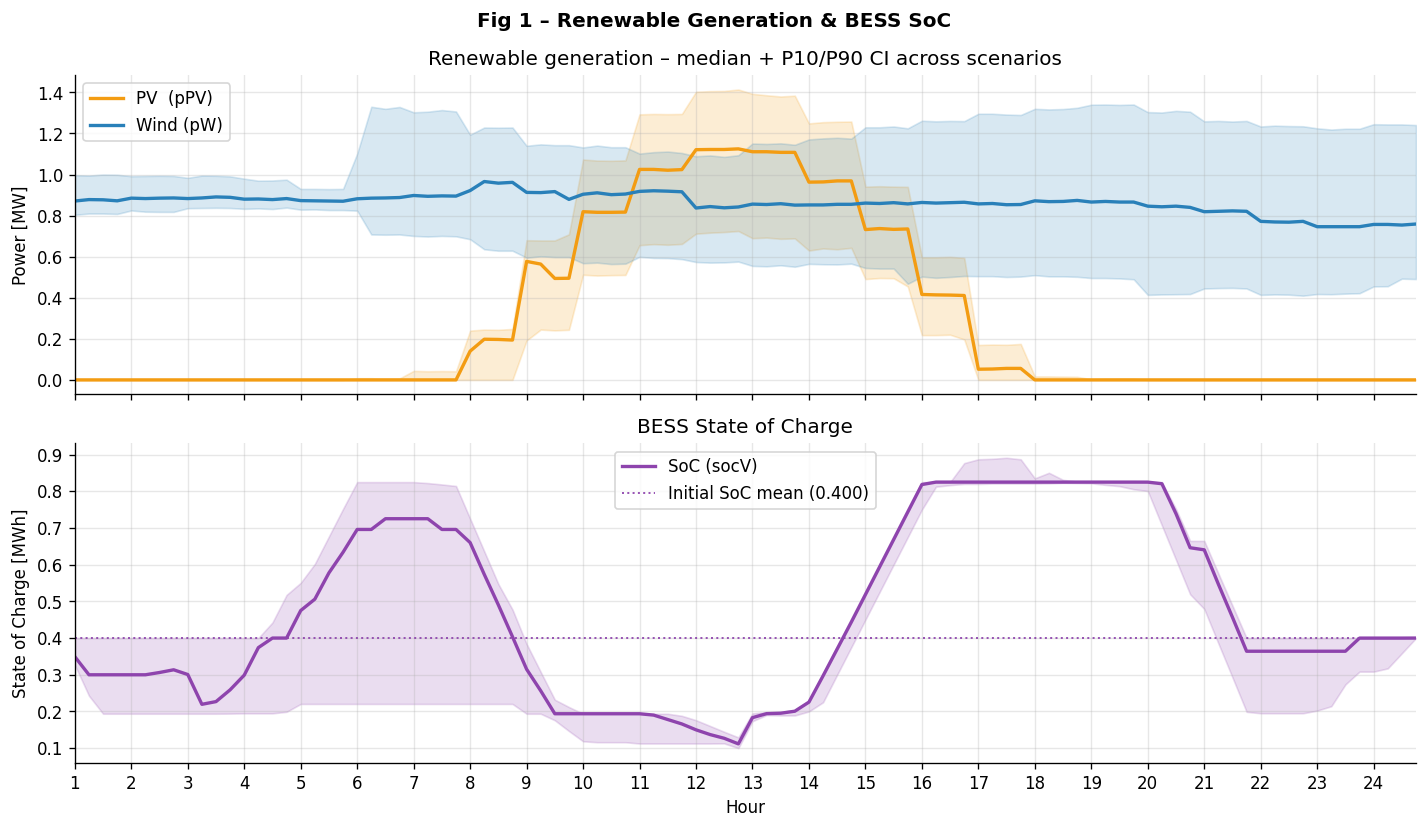

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 1 – Renewable Generation & BESS SoC", fontweight="bold")
t = _t(next(iter(data.values())))

if "pPV" in data: _band(ax1, t, data["pPV"], COLORS["pv"],   "PV  (pPV)")
if "pW"  in data: _band(ax1, t, data["pW"],  COLORS["wind"], "Wind (pW)")
ax1.set_ylabel("Power [MW]"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("Renewable generation – median + P10/P90 CI across scenarios")

if "socV" in data:
    _band(ax2, t, data["socV"], COLORS["bess"], "SoC (socV)")
    _annotate_socv_initial(ax2)
ax2.set_ylabel("State of Charge [MWh]"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("BESS State of Charge")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig1_generation"); plt.show()


## 5 · Fig 2 – BESS Operation (cV_dV & idV)

**What to look for:**
- `cV_dV > 0` → BESS is charging; `< 0` → discharging. Diverging colours make this instant to read.
- `idV` bar height → in what fraction of scenarios is the BESS actually dispatched to discharge at that hour.
- Discrepancy between median `cV_dV < 0` and low `idV` → some scenarios charge while others discharge (high uncertainty in dispatch decision).


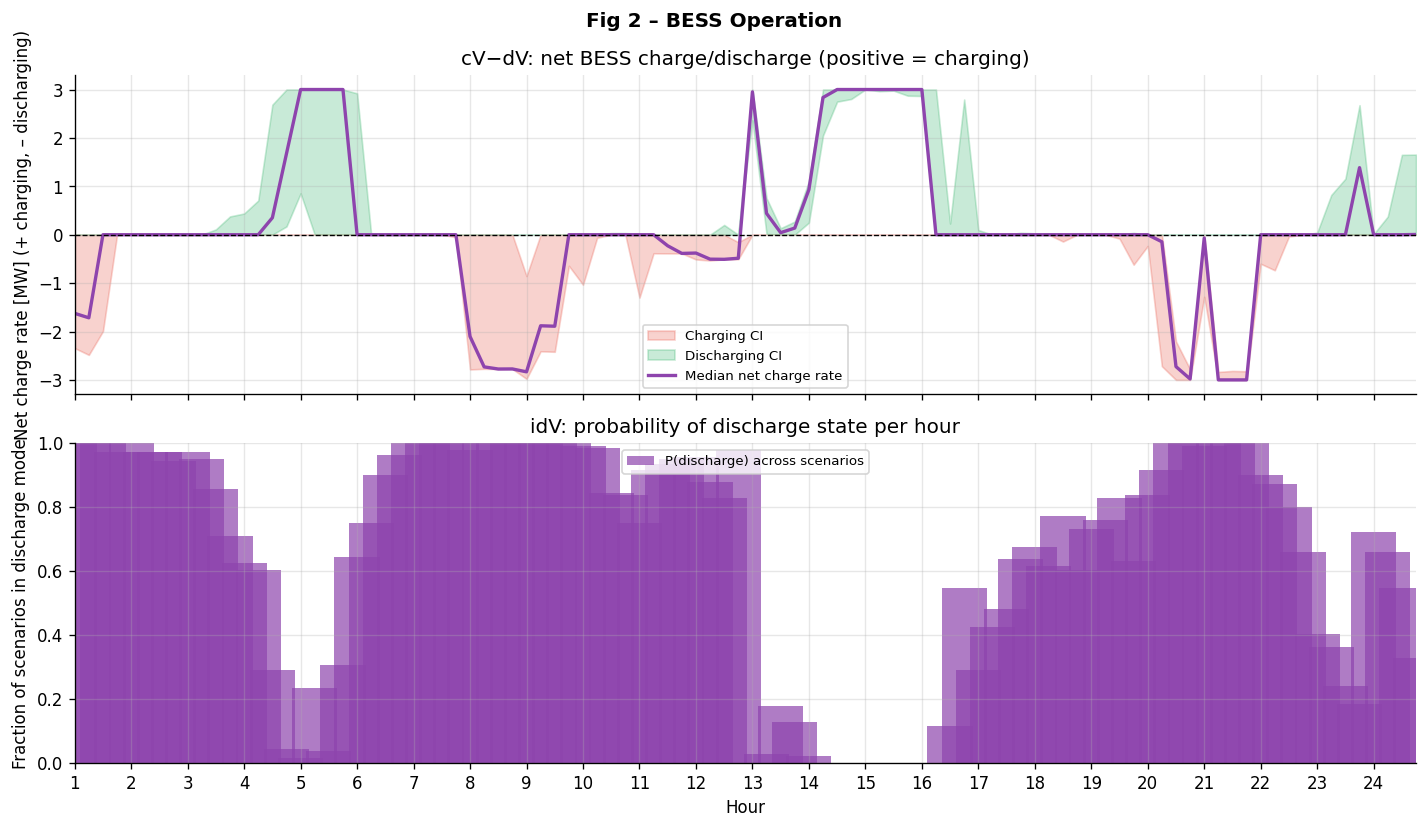

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
fig.suptitle("Fig 2 – BESS Operation", fontweight="bold")
t = _t(next(iter(data.values())))

if "cV_dV" in data:
    med, lo, hi = _ci(data["cV_dV"])
    ax1.fill_between(t, np.minimum(lo,0), np.minimum(hi,0), color=COLORS["neg"], alpha=0.25, label="Charging CI")
    ax1.fill_between(t, np.maximum(lo,0), np.maximum(hi,0), color=COLORS["pos"], alpha=0.25, label="Discharging CI")
    ax1.plot(t, med, color=COLORS["bess"], lw=2, label="Median net charge rate")
    ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("Net charge rate [MW] (+ charging, – discharging)")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("cV−dV: net BESS charge/discharge (positive = charging)")

if "idV" in data:
    ax2.bar(t, data["idV"].mean(axis=1), color=COLORS["bess"], alpha=0.7, label="P(discharge) across scenarios")
    ax2.set_ylim(0,1)
    ax2.set_ylabel("Fraction of scenarios in discharge mode")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
    ax2.set_title("idV: probability of discharge state per hour")
ax2.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax2, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig2_bess_operation"); plt.show()


## 6 · Fig 3 – Flexible Demand

**What to look for:**
- Panel (a): total `var_fd` — does the EC smooth its demand effectively?
- Panel (b): mirrored `var_afd_p` / `var_afd_m` — are both shifts active simultaneously (arbitrage) or mutually exclusive?
- Panel (c): boxplot of **net shift** — wide boxes indicate high scenario uncertainty in how the FD is used. Outliers suggest extreme activation events.


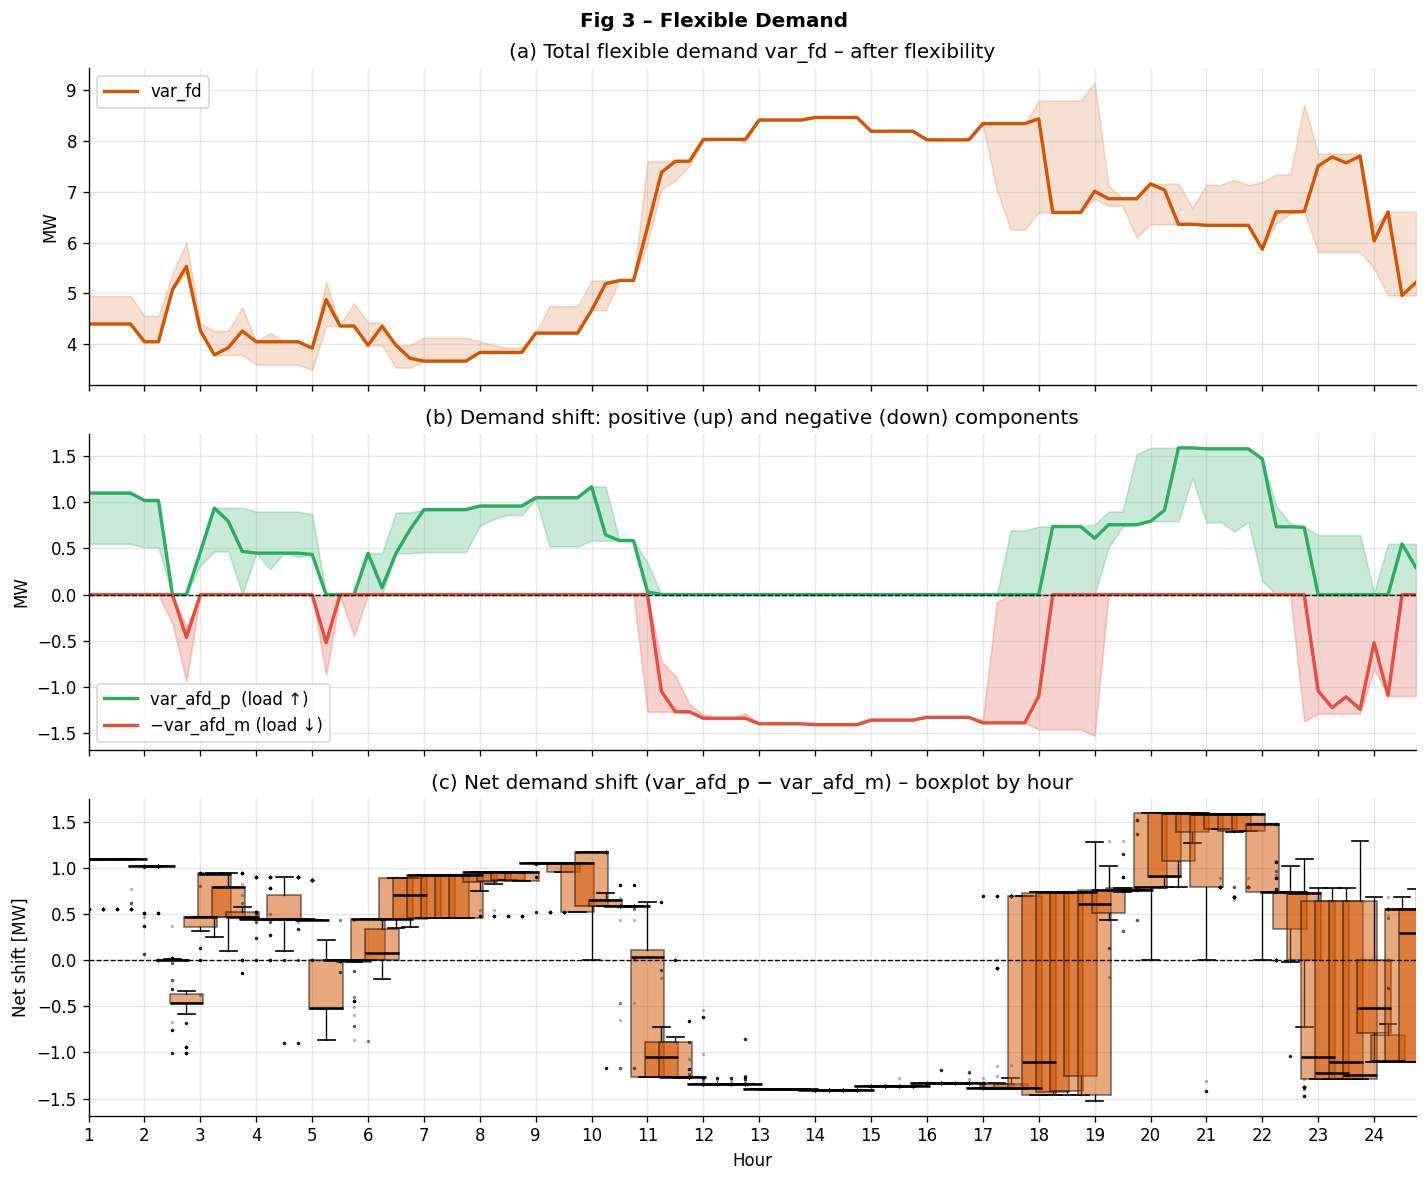

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 3 – Flexible Demand", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) total flexible demand
if "var_fd" in data:
    _band(ax1, t, data["var_fd"], COLORS["fd"], "var_fd")
ax1.set_ylabel("MW"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("(a) Total flexible demand var_fd – after flexibility")

# (b) positive / negative shifts mirrored
if "var_afd_p" in data and "var_afd_m" in data:
    med_p, lp, hp = _ci(data["var_afd_p"])
    med_m, lm, hm = _ci(data["var_afd_m"])
    ax2.fill_between(t,  lp,  hp, color=COLORS["pos"], alpha=0.25)
    ax2.plot(t, med_p, color=COLORS["pos"], lw=2, label="var_afd_p  (load ↑)")
    ax2.fill_between(t, -hm, -lm, color=COLORS["neg"], alpha=0.25)
    ax2.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−var_afd_m (load ↓)")
    ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.set_ylabel("MW"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("(b) Demand shift: positive (up) and negative (down) components")

# (c) net shift boxplot per hour
if "var_afd_p" in data and "var_afd_m" in data:
    net = (data["var_afd_p"] - data["var_afd_m"]).values
    ax3.boxplot([net[i,:] for i in range(len(t))],
                positions=t, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor=COLORS["fd"], alpha=0.5),
                medianprops=dict(color="k", lw=1.5),
                whiskerprops=dict(lw=0.8),
                flierprops=dict(marker=".", ms=2, alpha=0.3))
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("Net shift [MW]"); ax3.grid(alpha=0.3)
ax3.set_title("(c) Net demand shift (var_afd_p − var_afd_m) – boxplot by hour")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig3_flexible_demand"); plt.show()


## 7 · Fig 4 – Day-Ahead Commitment 
**What to look for:**
- **Panel (a):** committed energy in DA
- **Panel (b):** commited energy in RM
- **Panel (c):** commited energy in IM1
- **Panel (d):** commited energy in IM2
- **Panel (e):** commited energy in IM3


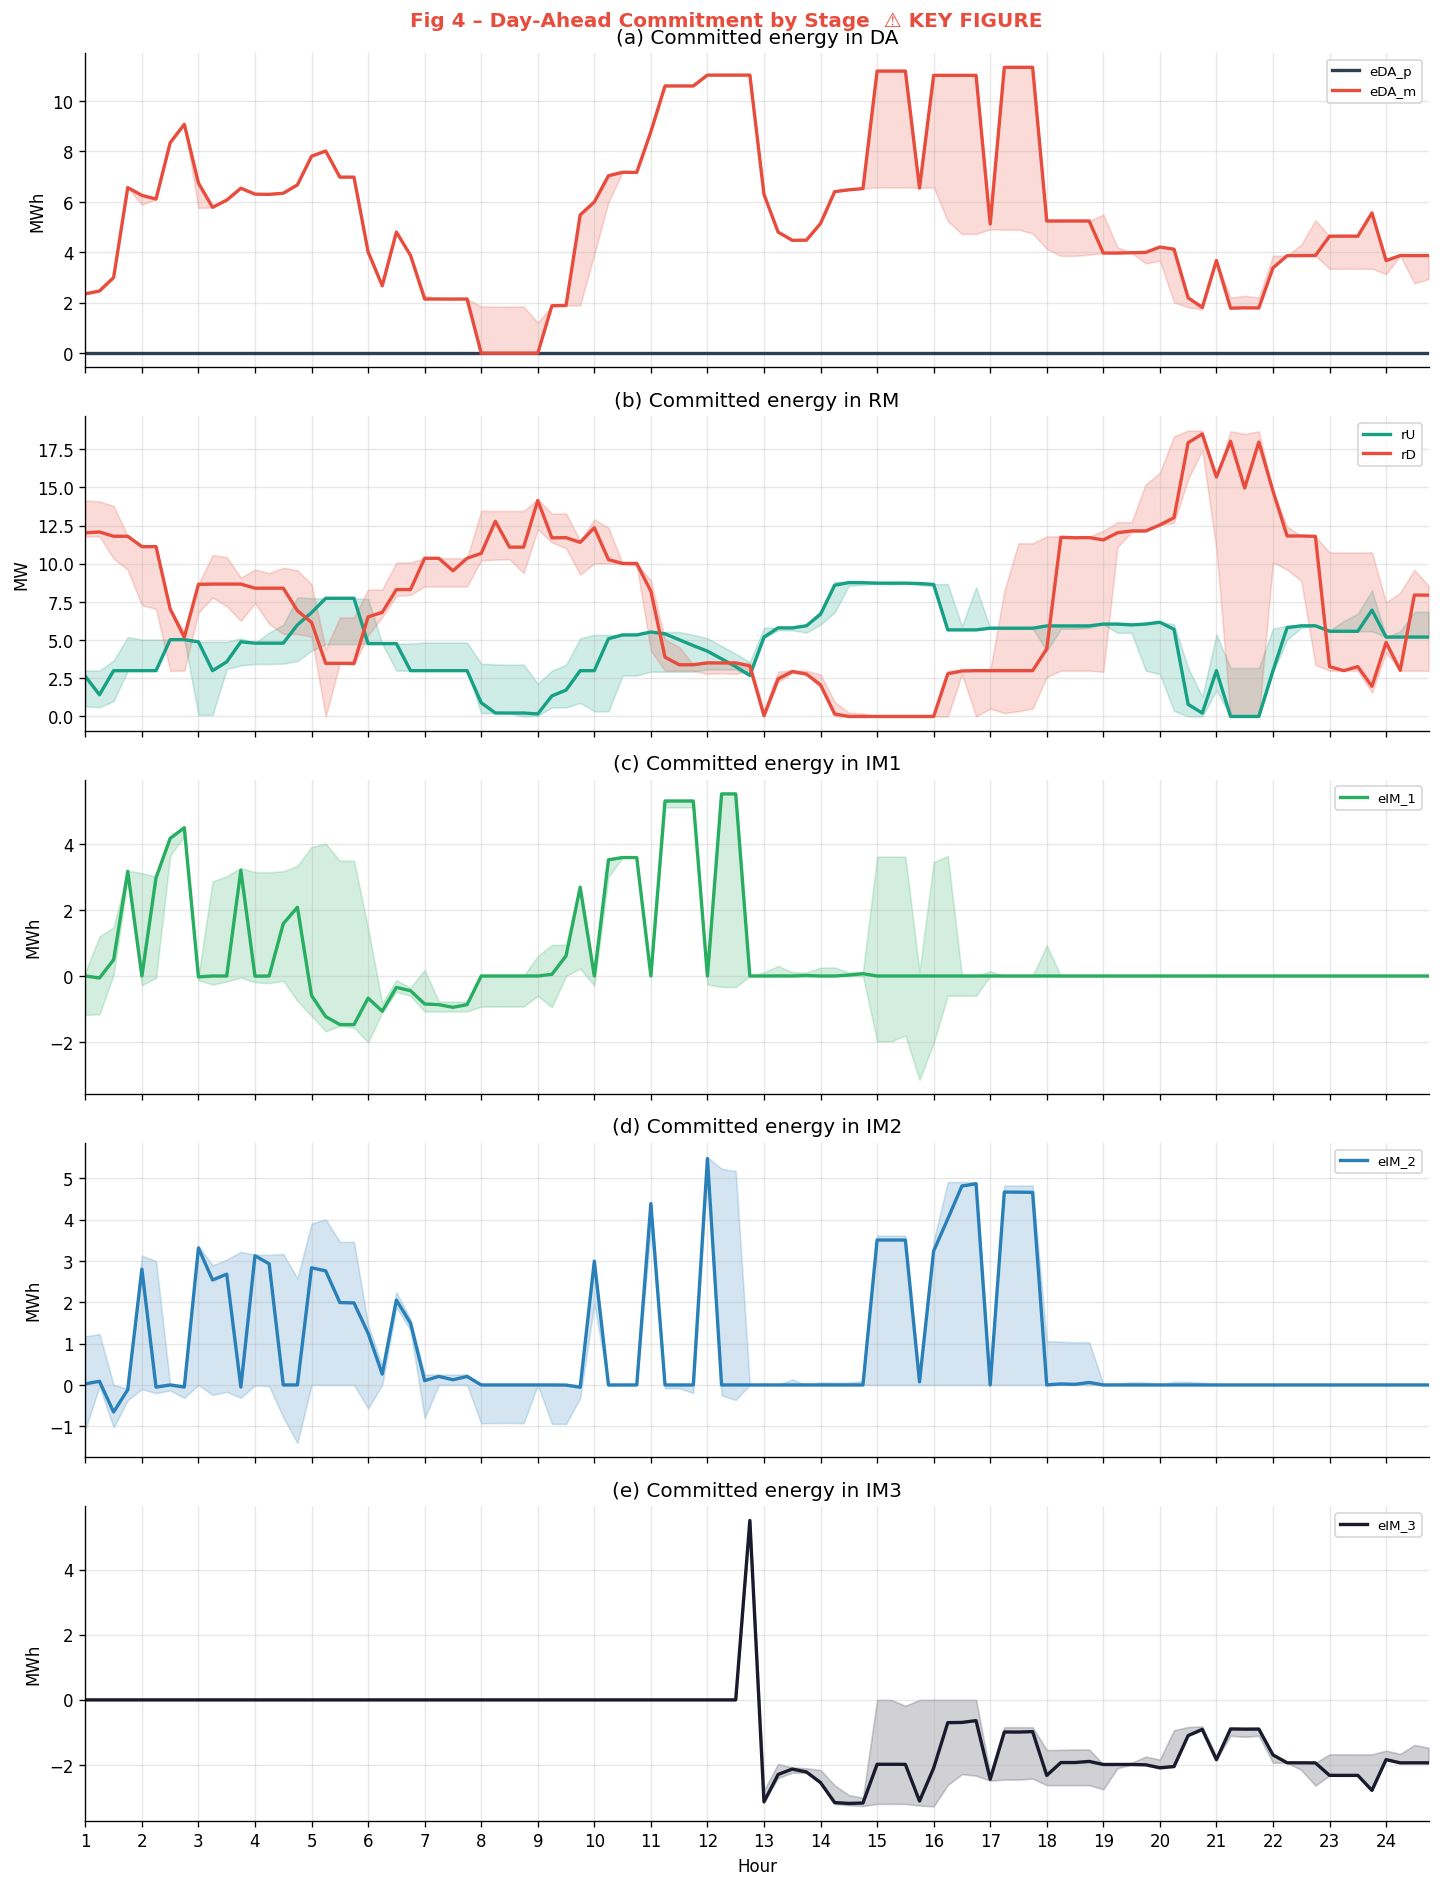

In [27]:
fig, axs = plt.subplots(5, 1, figsize=(12,16), sharex=True)
fig.suptitle("Fig 4 – Day-Ahead Commitment by Stage  ⚠️ KEY FIGURE",
             fontweight="bold", color=COLORS["neg"])
t = _t(next(iter(data.values())))

# (a) committed energy in DA
if "eDA_p" in data:
    med, lo, hi = _ci(data["eDA_p"])
    axs[0].fill_between(t, lo, hi, color=COLORS["da"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["da"], label="eDA_p")
if "eDA_m" in data:
    med, lo, hi = _ci(data["eDA_m"])
    axs[0].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[0].plot(t, med, lw=2, color=COLORS["neg"], label="eDA_m")
axs[0].set_ylabel("MWh"); axs[0].legend(fontsize=8); axs[0].grid(alpha=0.3)
axs[0].set_title("(a) Committed energy in DA")

# (b) committed energy in RM
if "rU" in data:
    med, lo, hi = _ci(data["rU"])
    axs[1].fill_between(t, lo, hi, color=COLORS["reserve"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["reserve"], label="rU")
if "rD" in data:
    med, lo, hi = _ci(data["rD"])
    axs[1].fill_between(t, lo, hi, color=COLORS["neg"], alpha=0.2)
    axs[1].plot(t, med, lw=2, color=COLORS["neg"], label="rD")
axs[1].set_ylabel("MW"); axs[1].legend(fontsize=8); axs[1].grid(alpha=0.3)
axs[1].set_title("(b) Committed energy in RM")

# (c) committed energy in IM1
if "eIM_1" in data:
    med, lo, hi = _ci(data["eIM_1"])
    axs[2].fill_between(t, lo, hi, color=COLORS["pos"], alpha=0.2)
    axs[2].plot(t, med, lw=2, color=COLORS["pos"], label="eIM_1")
axs[2].set_ylabel("MWh"); axs[2].legend(fontsize=8); axs[2].grid(alpha=0.3)
axs[2].set_title("(c) Committed energy in IM1")

# (d) committed energy in IM2
if "eIM_2" in data:
    med, lo, hi = _ci(data["eIM_2"])
    axs[3].fill_between(t, lo, hi, color=COLORS["wind"], alpha=0.2)
    axs[3].plot(t, med, lw=2, color=COLORS["wind"], label="eIM_2")
axs[3].set_ylabel("MWh"); axs[3].legend(fontsize=8); axs[3].grid(alpha=0.3)
axs[3].set_title("(d) Committed energy in IM2")

# (e) committed energy in IM3
if "eIM_3" in data:
    med, lo, hi = _ci(data["eIM_3"])
    axs[4].fill_between(t, lo, hi, color=COLORS["median"], alpha=0.2)
    axs[4].plot(t, med, lw=2, color=COLORS["median"], label="eIM_3")
axs[4].set_ylabel("MWh"); axs[4].legend(fontsize=8); axs[4].grid(alpha=0.3)
axs[4].set_title("(e) Committed energy in IM3")
axs[4].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axs[4], t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig4_da_commitment"); plt.show()

## 8 · Fig 5 – Reserve Provision (Upward & Downward)

**What to look for:**
- Which asset (BESS vs FD) carries the bulk of reserve provision at each hour.
- Dashed total line vs. stacked area → if total > BESS + FD something is off (data check).
- Wide CI on the total reserve → significant scenario uncertainty in reserve matching.


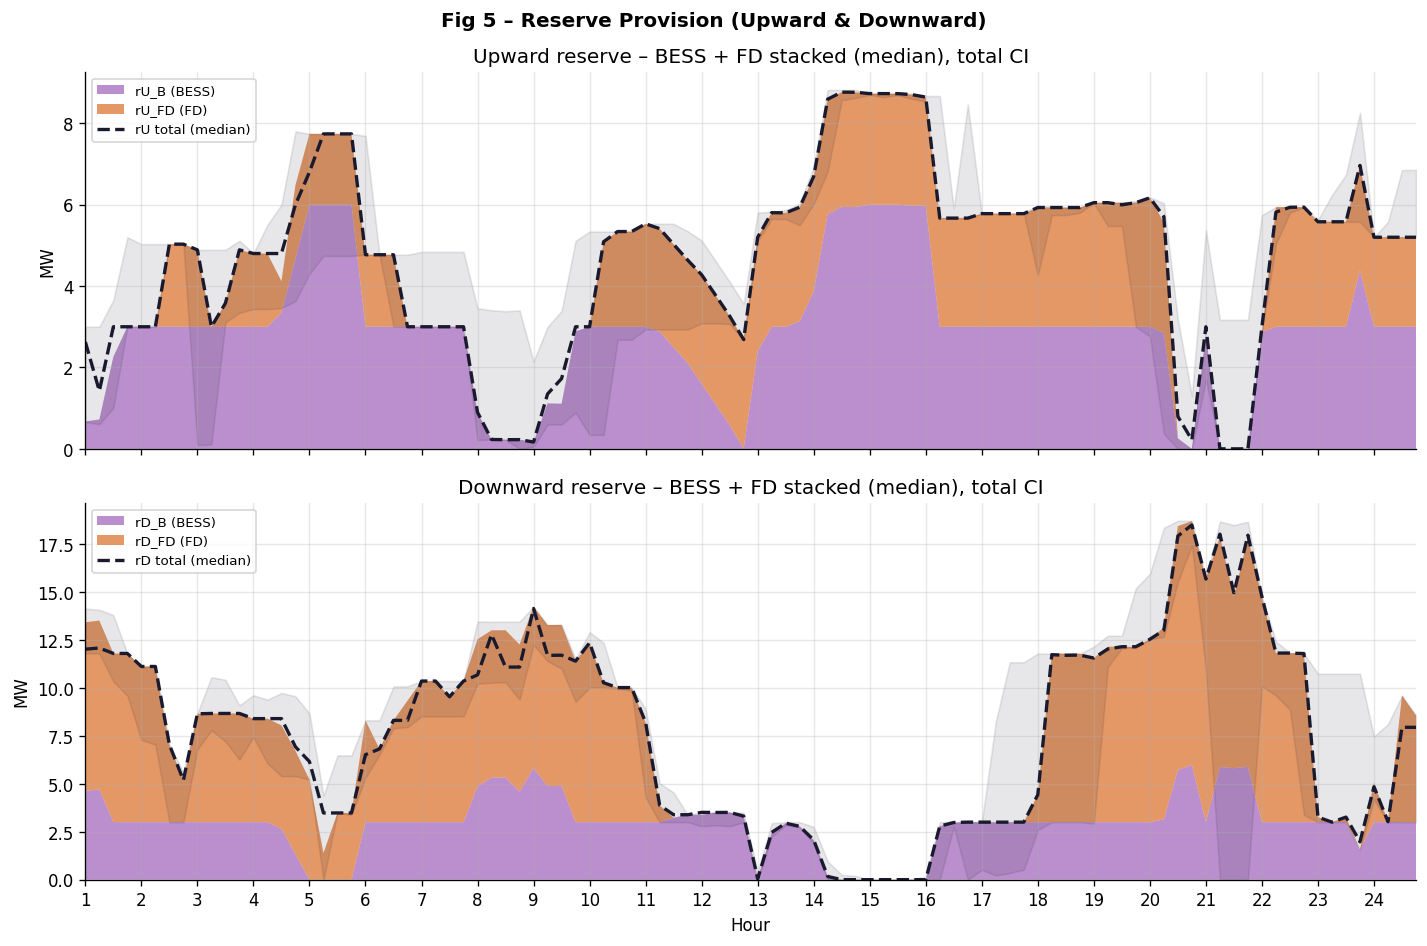

In [28]:
fig, (ax_u, ax_d) = plt.subplots(2, 1, figsize=(12,8), sharex=True)
fig.suptitle("Fig 5 – Reserve Provision (Upward & Downward)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, label, r_tot, r_b, r_fd in [
    (ax_u, "Upward",   "rU",  "rU_B",  "rU_FD"),
    (ax_d, "Downward", "rD",  "rD_B",  "rD_FD"),
]:
    med_b  = data[r_b ].median(axis=1).values if r_b  in data else np.zeros(len(t))
    med_fd = data[r_fd].median(axis=1).values if r_fd in data else np.zeros(len(t))
    ax.stackplot(t, med_b, med_fd,
                 labels=[f"{r_b} (BESS)", f"{r_fd} (FD)"],
                 colors=[COLORS["bess"], COLORS["fd"]], alpha=0.6)
    if r_tot in data:
        med_tot, lo, hi = _ci(data[r_tot])
        ax.plot(t, med_tot, color=COLORS["median"], lw=2, ls="--",
                label=f"{r_tot} total (median)")
        ax.fill_between(t, lo, hi, color=COLORS["median"], alpha=0.1)
    ax.set_ylabel("MW"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_title(f"{label} reserve – BESS + FD stacked (median), total CI")

ax_d.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax_d, t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig5_reserves"); plt.show()


## 9 · Fig 6 – Imbalance & Intraday Position ⚠️ KEY FIGURE

**What to look for:**
- **Panel (a):** mirrored pIB_p / pIB_m — does the EC mostly over-deliver or under-deliver?
- **Panel (b):** net imbalance bars — red hours = under-delivery (penalty exposure); green = over-delivery (spill or revenue).
- **Panel (c):** `eIM` — does intraday trading reduce imbalance at the same hours where panel (b) is red? If yes, the intraday market is effective.


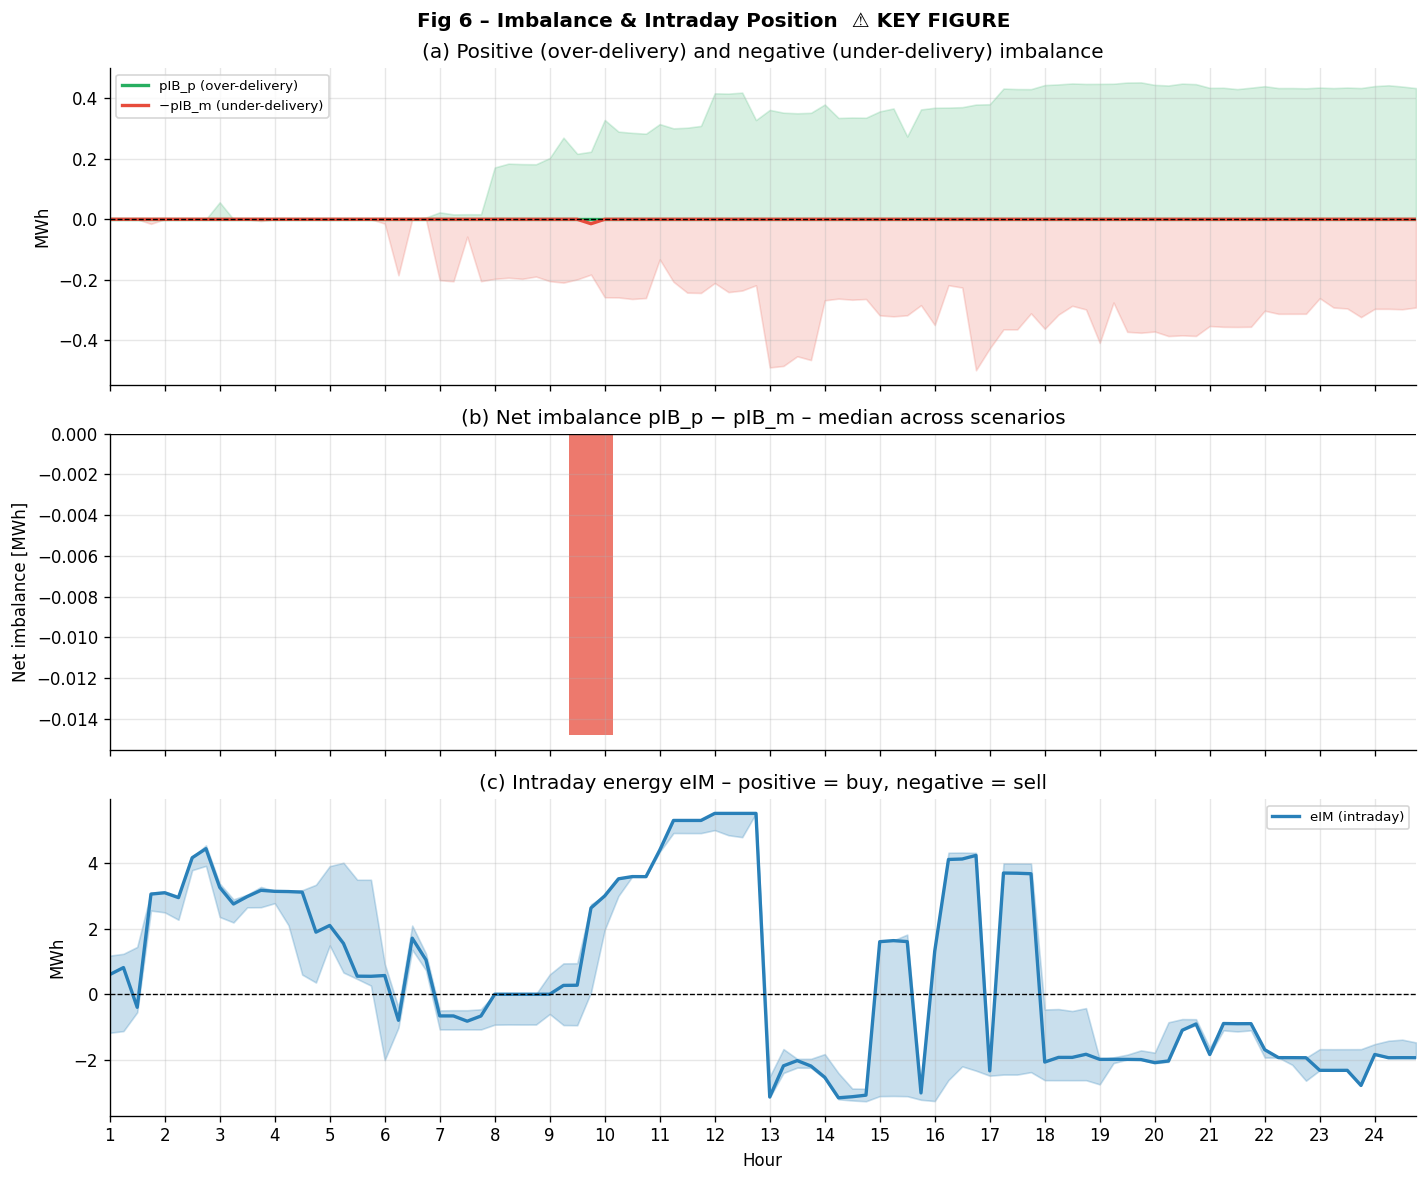

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,10), sharex=True)
fig.suptitle("Fig 6 – Imbalance & Intraday Position  ⚠️ KEY FIGURE", fontweight="bold")
t = _t(next(iter(data.values())))

# (a) pIB_p / pIB_m mirrored
if "pIB_p" in data:
    _band(ax1, t, data["pIB_p"], COLORS["pos"], "pIB_p (over-delivery)")
if "pIB_m" in data:
    med_m, lo_m, hi_m = _ci(data["pIB_m"])
    ax1.fill_between(t, -hi_m, -lo_m, color=COLORS["neg"], alpha=0.18)
    ax1.plot(t, -med_m, color=COLORS["neg"], lw=2, label="−pIB_m (under-delivery)")
ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_ylabel("MWh"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("(a) Positive (over-delivery) and negative (under-delivery) imbalance")

# (b) net imbalance bar
if "pIB_p" in data and "pIB_m" in data:
    net_med = (data["pIB_p"] - data["pIB_m"]).median(axis=1).values
    ax2.bar(t, net_med, color=[COLORS["pos"] if v>=0 else COLORS["neg"] for v in net_med], alpha=0.75)
    ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("Net imbalance [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Net imbalance pIB_p − pIB_m – median across scenarios")

# (c) eIM intraday
if "eIM" in data:
    med_im, lo_im, hi_im = _ci(data["eIM"])
    ax3.fill_between(t, lo_im, hi_im, color=COLORS["wind"], alpha=0.25)
    ax3.plot(t, med_im, color=COLORS["wind"], lw=2, label="eIM (intraday)")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
ax3.set_ylabel("MWh"); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
ax3.set_title("(c) Intraday energy eIM – positive = buy, negative = sell")
ax3.set_xlabel(CONFIG["period_label"])
_format_hour_axis(ax3, t if "t" in globals() else None)

plt.tight_layout(); _save(fig, "fig6_imbalance"); plt.show()


## 10 · Fig 7 – Scenario Fan Charts (spaghetti)

**What to look for:**
- Are traces clustered (low spread) or spread widely (high uncertainty)?
- Bimodal shapes → two distinct operating regimes across scenarios.
- Extreme outlier traces → which scenario drives the worst case?

> You can change `vars_to_show` to inspect any subset of variables.


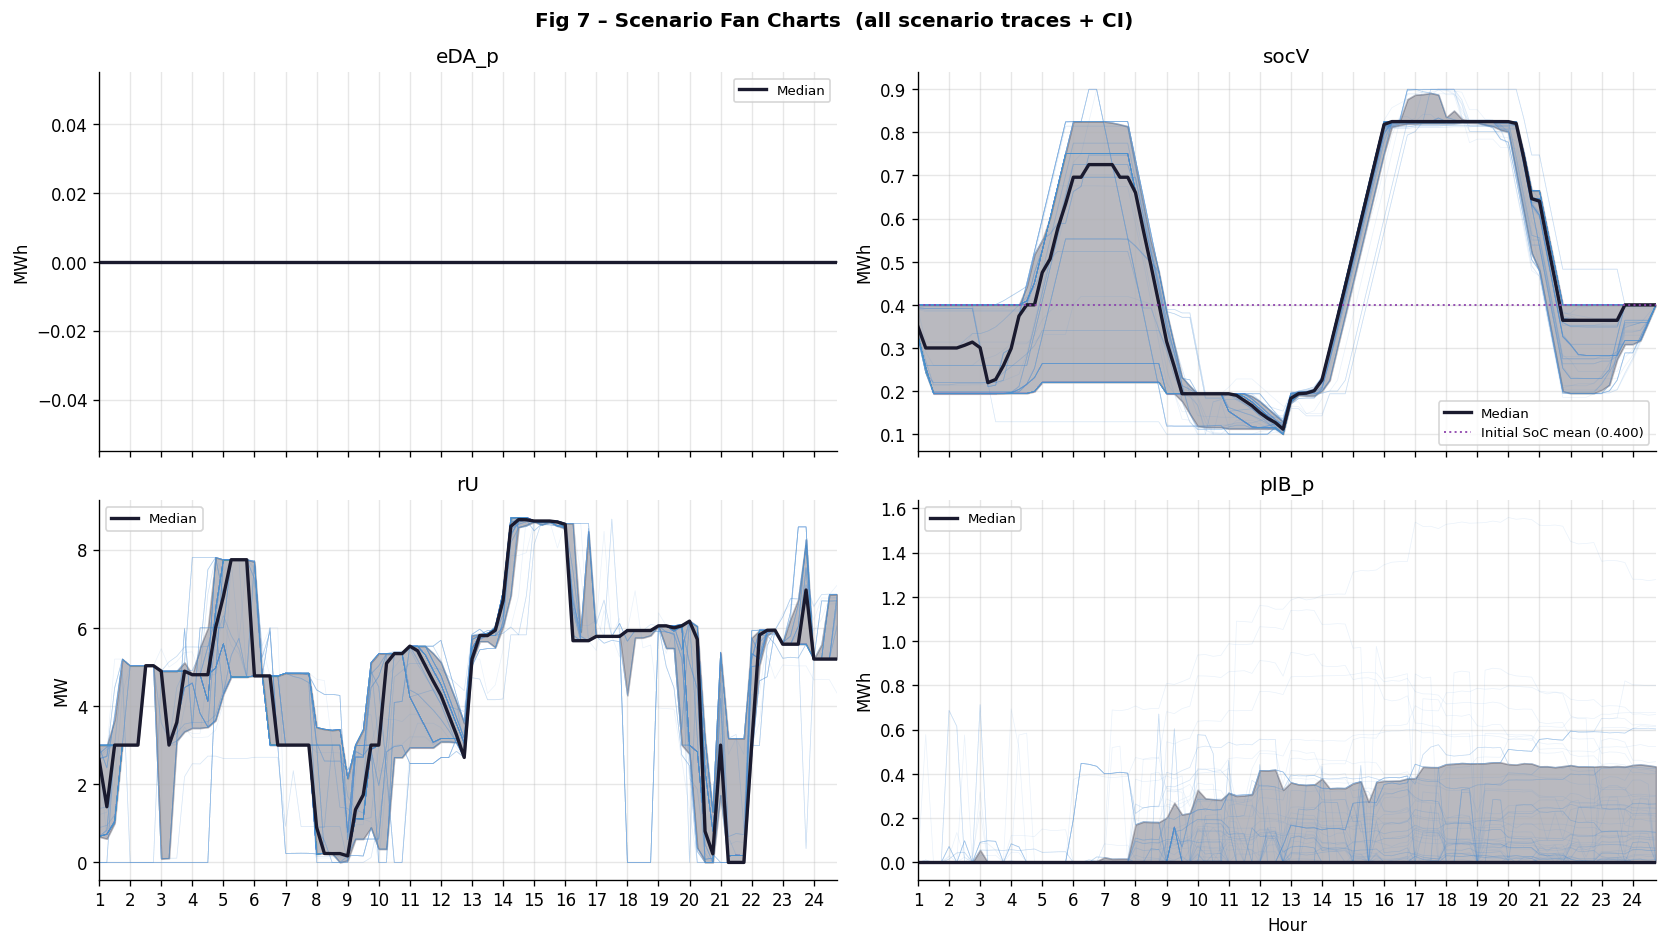

In [30]:
vars_to_show = ["eDA_p", "socV", "rU", "pIB_p"]   # ← edit here
vars_to_show = [v for v in vars_to_show if v in data]

ncols = 2
nrows = int(np.ceil(len(vars_to_show)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), sharex=True)
axes = np.array(axes).flatten()
fig.suptitle("Fig 7 – Scenario Fan Charts  (all scenario traces + CI)", fontweight="bold")
t = _t(next(iter(data.values())))

for ax, var in zip(axes, vars_to_show):
    df = data[var]
    for col in df.columns:
        ax.plot(t, df[col].values, color=COLORS["ci_fill"], lw=0.4, alpha=0.12)
    _band(ax, t, df, COLORS["median"], "Median", alpha=0.3)
    if var == "socV":
        _annotate_socv_initial(ax)
    ax.set_title(var); ax.set_ylabel(UNITS.get(var,"–")); ax.grid(alpha=0.3); ax.legend(fontsize=8)

for ax in axes[len(vars_to_show):]: ax.set_visible(False)
axes[-1].set_xlabel(CONFIG["period_label"])
_format_hour_axis(axes[-1], t if "t" in globals() else None)
plt.tight_layout(); _save(fig, "fig7_scenario_fans"); plt.show()


## 11 ? Market Benefit Distribution

Boxplot of total scenario benefit by market. CI markers show P10-P90 across scenarios.


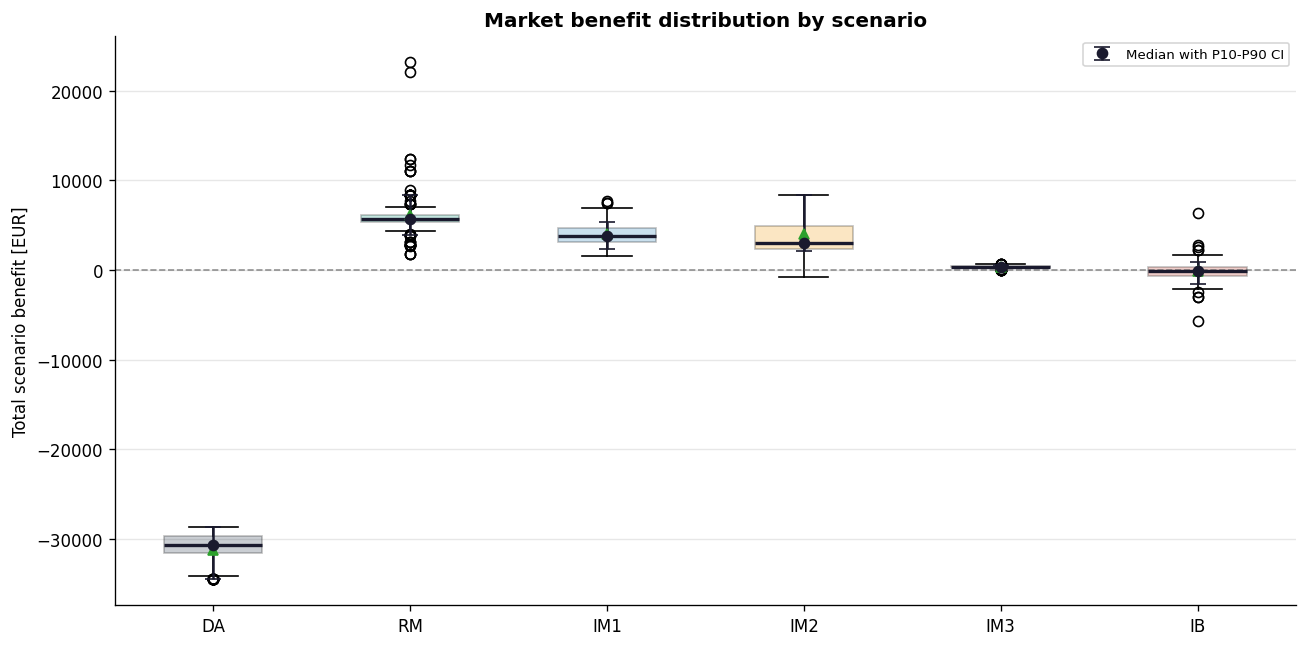

,median,P10,P90,mean
DA,-30680.7986,-34522.8695,-28661.5923,-31186.7016
RM,5662.9829,3955.8293,8404.6060,6116.3945
IM1,3745.3331,2389.7170,5382.7692,4014.7573
IM2,2989.1913,2070.6320,8347.0006,4000.7261
IM3,388.0160,237.2953,521.3638,383.9235
IB,-109.5943,-1514.7285,926.7544,-133.2361


In [31]:
def _aligned_product_total(*dfs):
    dfs = [df for df in dfs if df is not None]
    if not dfs:
        return None
    common_index = dfs[0].index
    common_cols = dfs[0].columns
    for df in dfs[1:]:
        common_index = common_index.intersection(df.index)
        common_cols = common_cols.intersection(df.columns)
    if len(common_index) == 0 or len(common_cols) == 0:
        return None
    prod = dfs[0].loc[common_index, common_cols].copy()
    for df in dfs[1:]:
        prod = prod * df.loc[common_index, common_cols]
    return prod.sum(axis=0)

market_benefits = {}

if {"lD", "eDA_p", "eDA_m"}.issubset(data):
    da_net = data["eDA_p"] - data["eDA_m"]
    market_benefits["DA"] = _aligned_product_total(data["lD"], da_net)

if {"lR", "rU", "rD"}.issubset(data):
    rm_reserve = data["rU"] + data["rD"]
    market_benefits["RM"] = _aligned_product_total(data["lR"], rm_reserve)

for i in [1, 2, 3]:
    li = f"lI_{i}"
    ei = f"eIM_{i}"
    if {li, ei}.issubset(data):
        market_benefits[f"IM{i}"] = _aligned_product_total(data[li], data[ei])

if {"lPIB", "pIB_p", "lNIB", "pIB_m"}.issubset(data):
    ib_income = _aligned_product_total(data["lPIB"], data["pIB_p"])
    ib_costs = _aligned_product_total(data["lNIB"], data["pIB_m"])
    if ib_income is not None and ib_costs is not None:
        common_cols = ib_income.index.intersection(ib_costs.index)
        market_benefits["IB"] = ib_income.loc[common_cols] - ib_costs.loc[common_cols]

market_order = ["DA", "RM", "IM1", "IM2", "IM3", "IB"]
market_benefits = {k: market_benefits[k].dropna() for k in market_order if k in market_benefits and market_benefits[k] is not None}

if not market_benefits:
    print("No market benefit data available for this run.")
else:
    labels = list(market_benefits.keys())
    values = [market_benefits[k].values for k in labels]
    positions = np.arange(1, len(labels) + 1)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bp = ax.boxplot(values, positions=positions, labels=labels, patch_artist=True, showmeans=True)
    for patch, color in zip(bp["boxes"], [COLORS["da"], COLORS["reserve"], COLORS["wind"], COLORS["pv"], COLORS["fd"], COLORS["imbal"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
    for med in bp["medians"]:
        med.set_color(COLORS["median"])
        med.set_linewidth(2)

    ci_low, ci_high = CONFIG["ci_low"], CONFIG["ci_high"]
    medians = np.array([np.median(v) for v in values])
    lo = np.array([np.percentile(v, ci_low) for v in values])
    hi = np.array([np.percentile(v, ci_high) for v in values])
    ax.errorbar(positions, medians, yerr=[medians - lo, hi - medians], fmt="o",
                color=COLORS["median"], ecolor=COLORS["median"], capsize=5,
                label=f"Median with P{ci_low}-P{ci_high} CI")
    ax.axhline(0, color="#666666", lw=1, ls="--", alpha=0.7)
    ax.set_ylabel("Total scenario benefit [EUR]")
    ax.set_title("Market benefit distribution by scenario", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout(); _save(fig, "fig_market_benefits_boxplot"); plt.show()

    benefit_summary = pd.DataFrame({
        "median": medians,
        f"P{ci_low}": lo,
        f"P{ci_high}": hi,
        "mean": [np.mean(v) for v in values],
    }, index=labels)
    display(benefit_summary)


## 11 · Fig 8 – Correlation Heatmap

**What to look for:**
- Strong positive correlation (dark blue) between PV/Wind and reserve/FD → renewable surplus drives reserve provision.
- Strong negative correlation between `socV` and `pIB_m` → better SoC management reduces imbalance penalties.
- Any unexpected high correlation that reveals hidden structural coupling in the model.


Excluded constant variables from correlation heatmap: ['eDA_p', 'ieDA_p', 'pIB_p']
Correlation heatmap uses 30 operational variables with shared index 96 time points.


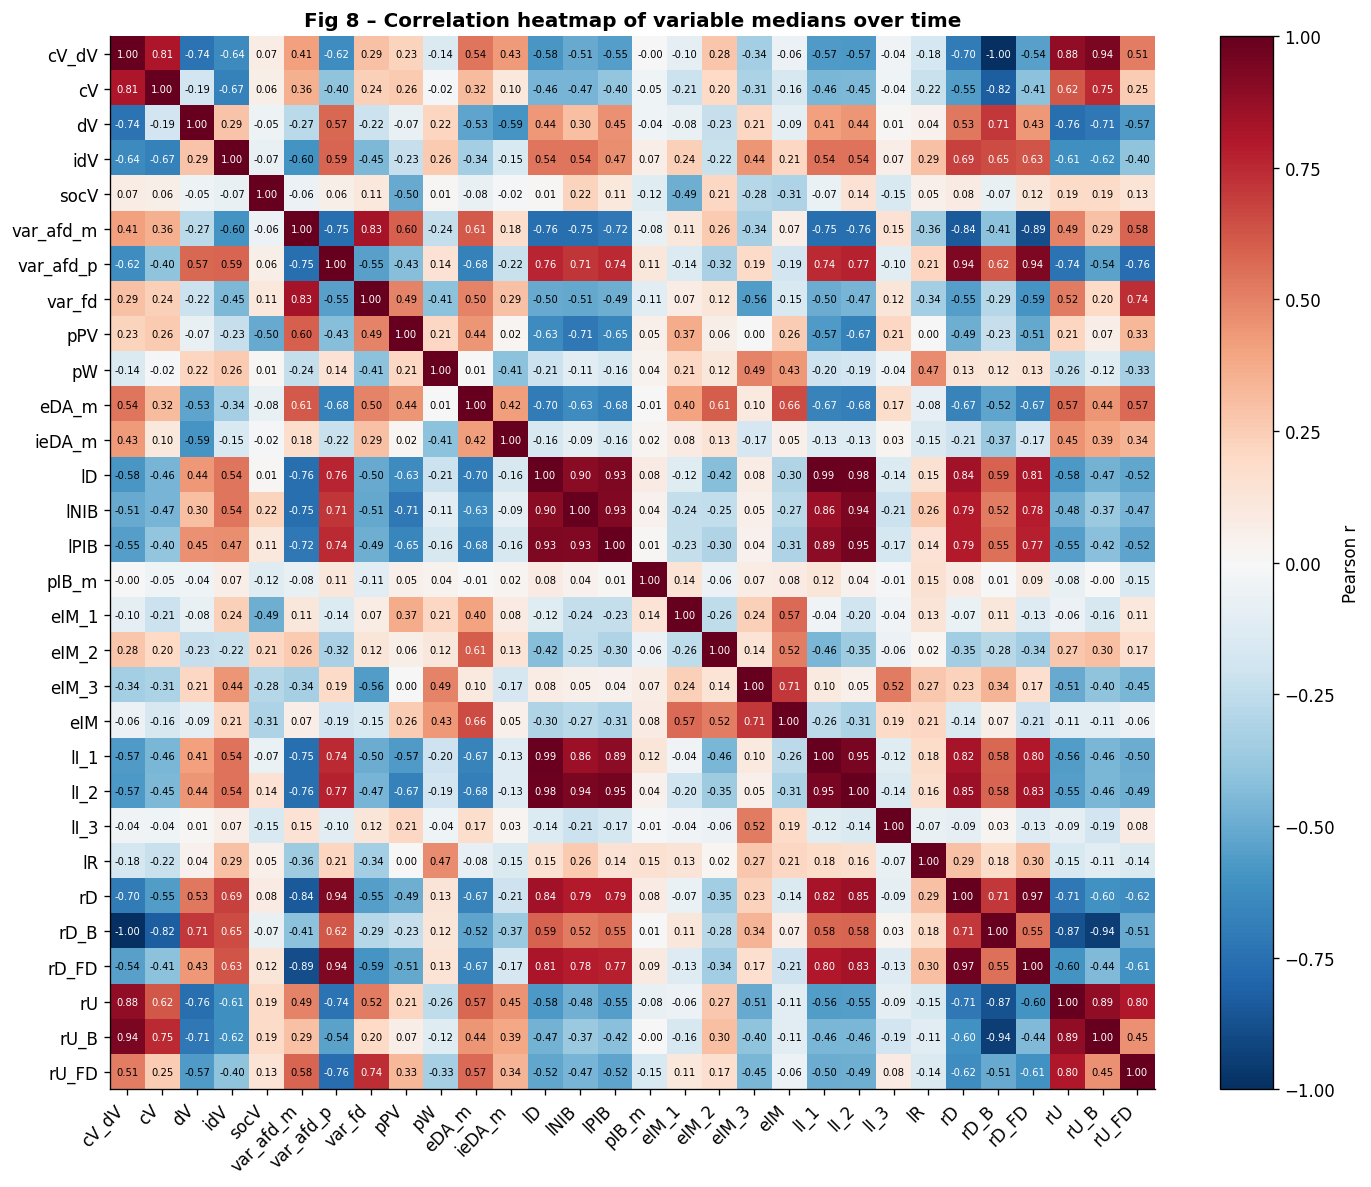

In [32]:
op_data = _operational_ts_data(data)
med_df = pd.DataFrame({v: df.median(axis=1) for v, df in op_data.items()})
empty_vars = med_df.columns[med_df.isna().all()].tolist()
if empty_vars:
    print("Dropped empty variables from correlation heatmap:", empty_vars)
med_df = med_df.dropna(axis=1, how="all")
std = med_df.std(axis=0)
constant_vars = std[std <= 1e-12].index.tolist()
if constant_vars:
    print("Excluded constant variables from correlation heatmap:", constant_vars)
med_df = med_df.loc[:, std > 1e-12]
corr = med_df.corr(min_periods=2)
if corr.isna().any().any():
    print("Warning: correlation contains NaN values due to insufficient data for some variable pairs. NaN values are preserved.")
print(f"Correlation heatmap uses {med_df.shape[1]} operational variables with shared index {med_df.shape[0]} time points.")

fig, ax = plt.subplots(figsize=(12,10))
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#d3d3d3")
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i,j]
        text = f"{val:.2f}" if not np.isnan(val) else "NaN"
        color = "white" if not np.isnan(val) and abs(val) > 0.6 else "black"
        ax.text(j, i, text, ha="center", va="center",
                fontsize=6, color=color)
ax.set_title("Fig 8 – Correlation heatmap of variable medians over time", fontweight="bold")
plt.tight_layout(); _save(fig, "fig8_correlation"); plt.show()


## 12 · Fig 9 – Commitment Failure Dashboard ⚠️ KEY FIGURE

One-page answer to *"when and how severely did the EC miss its day-ahead commitments?"*

| Sub-panel | What it shows |
|---|---|
| **(a) Risk strip** | colour = fraction of scenarios with `pIB_m > 0`; red hours = most risky |
| **(b) Shortfall bars** | median magnitude of `pIB_m` (CI band) |
| **(c) Delivered power** | actual delivered power from `pPV + pW - cV_dV` when available; otherwise show `pIB_m` under-delivery proxy |
| **(d) CDF** | cumulative distribution of total daily under-delivery across all scenarios; P90 marks the tail risk |


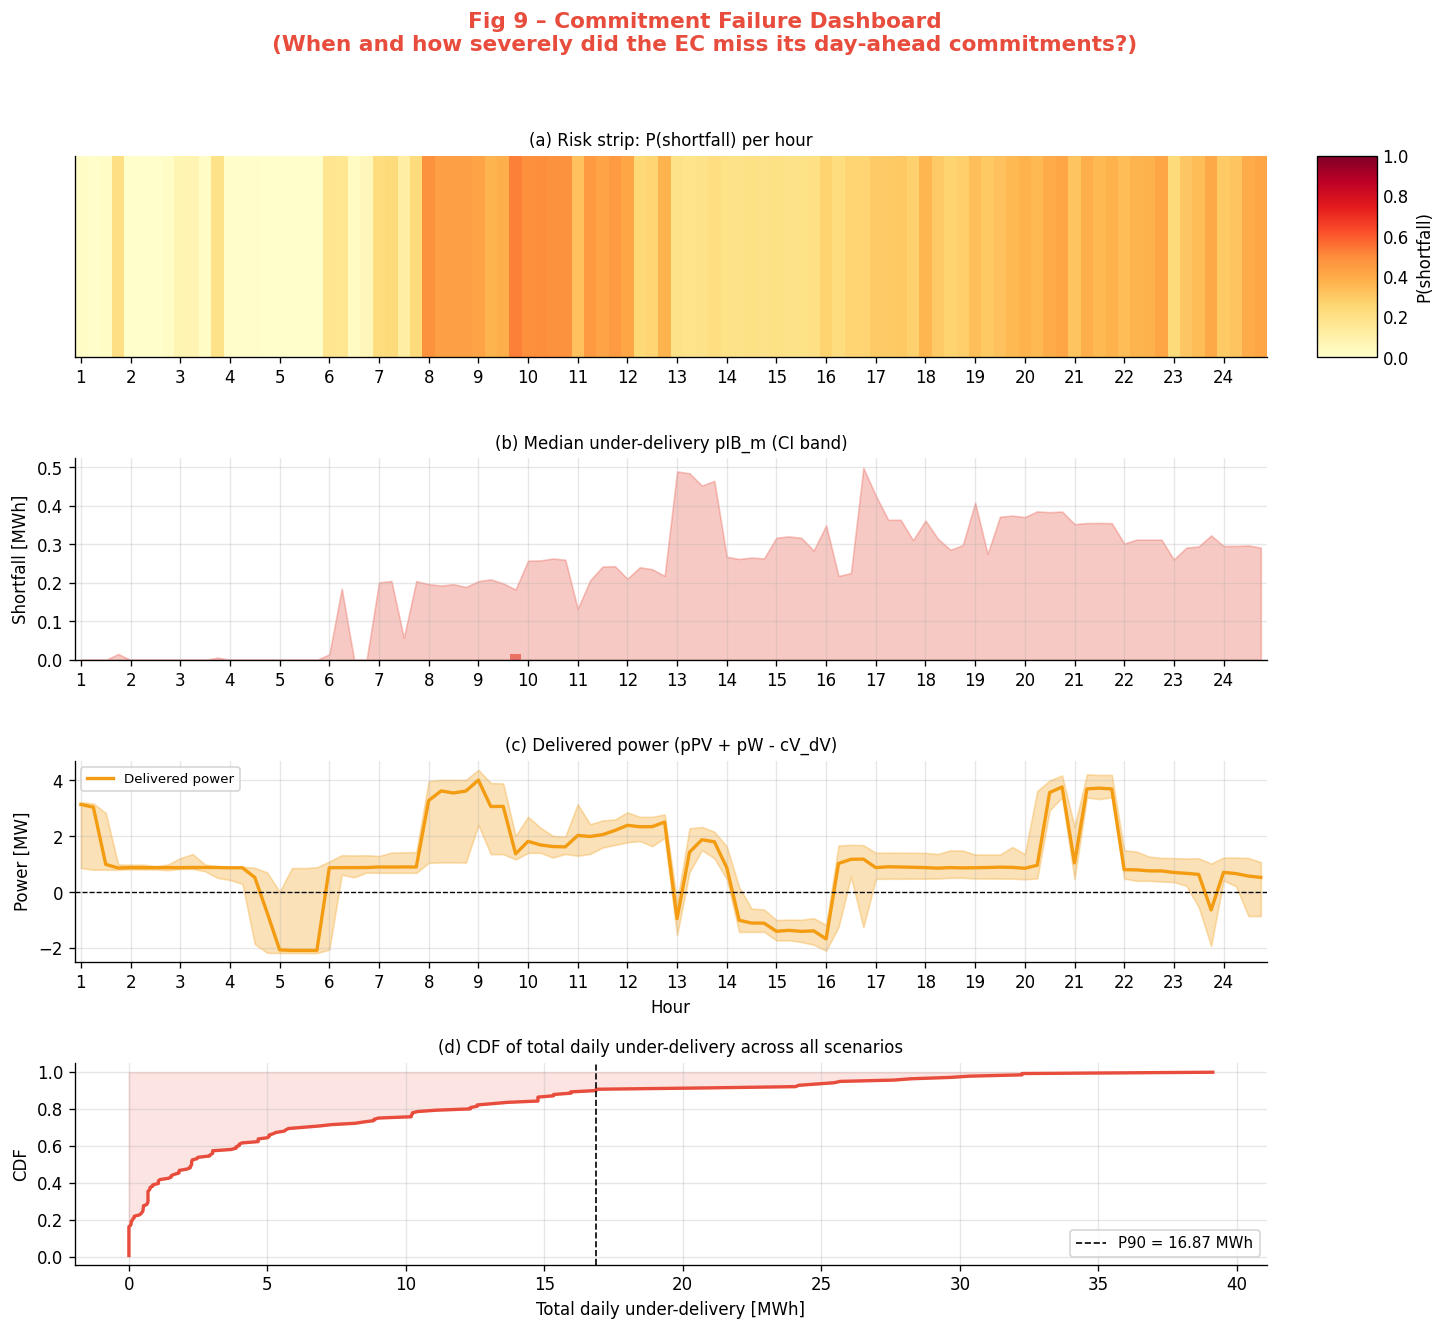

In [33]:
fig = plt.figure(figsize=(14,12))
fig.suptitle("Fig 9 – Commitment Failure Dashboard\n"
             "(When and how severely did the EC miss its day-ahead commitments?)",
             fontweight="bold", color=COLORS["neg"], fontsize=13)

gs = gridspec.GridSpec(4, 2, width_ratios=[20, 1], wspace=0.08, hspace=0.5)
ax1 = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax4 = fig.add_subplot(gs[3, 0])

t_arr = _t(next(iter(data.values())))
T = len(t_arr)
step = float(np.min(np.diff(t_arr))) if len(t_arr) > 1 else 1.0
x_edges = np.concatenate([t_arr - step/2, [t_arr[-1] + step/2]])
bar_width = min(0.8, step * 0.9)

# (a) risk heat-strip
prob = np.zeros(T)
if "pIB_m" in data:
    prob = (data["pIB_m"] > 1e-6).mean(axis=1).values
heat = ax1.pcolormesh(x_edges, [0, 1], prob[None, :], cmap="YlOrRd",
                      vmin=0, vmax=1, shading="auto")
fig.colorbar(heat, cax=cax, orientation="vertical")
cax.set_ylabel("P(shortfall)")
cax.yaxis.set_label_position("right")
cax.tick_params(axis="both", which="both", length=0)
ax1.set_yticks([])
ax1.set_title("(a) Risk strip: P(shortfall) per hour", fontsize=10)
ax1.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
ax1.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
ax1.set_xlim(x_edges[0], x_edges[-1])

# (b) shortfall bars
if "pIB_m" in data:
    med, lo, hi = _ci(data["pIB_m"])
    ax2.fill_between(t_arr, lo, hi, color=COLORS["neg"], alpha=0.3)
    ax2.bar(t_arr, med, color=COLORS["neg"], alpha=0.7, width=bar_width)
ax2.set_ylabel("Shortfall [MWh]"); ax2.grid(alpha=0.3)
ax2.set_title("(b) Median under-delivery pIB_m (CI band)", fontsize=10)

# (c) delivered power
if {"pPV", "pW", "cV_dV"}.issubset(data):
    delivered = data["pPV"] + data["pW"] - data["cV_dV"]
    med_del, lo_del, hi_del = _ci(delivered)
    ax3.fill_between(t_arr, lo_del, hi_del, color=COLORS["pv"], alpha=0.3)
    ax3.plot(t_arr, med_del, color=COLORS["pv"], lw=2, label="Delivered power")
    ax3.axhline(0, color="k", lw=0.8, ls="--")
    ax3.set_ylabel("Power [MW]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Delivered power (pPV + pW - cV_dV)", fontsize=10)
else:
    if "pIB_m" in data:
        med_ib, lo_ib, hi_ib = _ci(data["pIB_m"])
        ax3.fill_between(t_arr, lo_ib, hi_ib, color=COLORS["imbal"], alpha=0.3)
        ax3.plot(t_arr, med_ib, color=COLORS["imbal"], lw=2, label="pIB_m median")
    ax3.set_ylabel("pIB_m [MWh]"); ax3.set_xlabel(CONFIG["period_label"])
    ax3.set_xticks(np.arange(1, int(CONFIG["n_periods"]) + 1))
    ax3.set_xticklabels([str(i) for i in range(1, int(CONFIG["n_periods"]) + 1)])
    ax3.set_xlim(x_edges[0], x_edges[-1])
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)
    ax3.set_title("(c) Negative imbalance pIB_m – proxy for under-delivery cost", fontsize=10)

# (d) CDF of total daily under-delivery
if "pIB_m" in data:
    sf_tot = data["pIB_m"].sum(axis=0).values
    sf_s   = np.sort(sf_tot)
    cdf    = np.arange(1,len(sf_s)+1)/len(sf_s)
    ax4.plot(sf_s, cdf, color=COLORS["neg"], lw=2)
    ax4.fill_betweenx(cdf, 0, sf_s, color=COLORS["neg"], alpha=0.15)
    p90 = np.percentile(sf_s,90)
    ax4.axvline(p90, color="k", ls="--", lw=1, label=f"P90 = {p90:.2f} MWh")
    ax4.set_xlabel("Total daily under-delivery [MWh]")
    ax4.set_ylabel("CDF"); ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
    ax4.set_title("(d) CDF of total daily under-delivery across all scenarios", fontsize=10)
else:
    ax4.text(0.5, 0.5, "No pIB_m data available for daily under-delivery CDF",
             ha="center", va="center", transform=ax4.transAxes)
    ax4.set_axis_off()

_save(fig, "fig9_commitment_dashboard"); plt.show()

## 13 · Export Descriptive Statistics to CSV

In [34]:
if CONFIG["save_figs"]:
    os.makedirs(CONFIG["fig_dir"], exist_ok=True)
    out = os.path.join(CONFIG["fig_dir"], "descriptive_stats.csv")
    summary.to_csv(out)
    print(f"Saved → {out}")
else:
    print("Set CONFIG['save_figs'] = True to export.")


Saved → figures/dif_ren/descriptive_stats.csv


## 14 · Batch Analysis — Scenario-Reduction Method Comparison (Same-Ren vs Different-Ren)

Everything above analyzes **one** simulation run in detail (per-scenario, per-timestep).
This section instead compares **many** runs produced by `codes/batch_run_scenarios.py`,
which solves the DA market once per scenario-count folder for two scenario-reduction
methodologies:

- **`same_ren`** – renewable profiles shared across the scenario tree (`results_batch_same_ren.csv`)
- **`dif_ren`** – renewable profiles differ per scenario (`results_batch_dif_ren.csv`)

**Data sources:**
1. The two batch CSVs (one row per solved scenario-count folder) — timing, resources,
   objective-function breakdown, and the `results_dir` of each run.
2. The per-run result files saved under `results/<scenario_folder>/DA/...` for that
   run (used here to compare Day-Ahead commitments, `eDA_p`/`eDA_m`).

This section is safe to run before all batch jobs finish: missing CSVs/rows/result
files are skipped with a printed warning rather than raising an error, so re-running
it later (once more scenario counts have completed) will simply show more data points.


In [35]:
try:
    display
except NameError:
    display = print

BATCH_METHOD_LABELS = {"same_ren": "Same-Ren", "dif_ren": "Different-Ren"}
BATCH_METHOD_COLORS = {"same_ren": "#2980b9", "dif_ren": "#e67e22"}

BATCH_CSVS = {
    "same_ren": os.path.join("..", "..", "HG", "results_batch_same_ren.csv"),
    "dif_ren":  os.path.join("..", "..", "QHS", "results_batch_dif_ren.csv"),
}

# Batch-comparison figures go in their own subfolder, distinct from the
# single-run same_ren/ and dif_ren/ figure sets above.
CONFIG["save_figs"] = True
CONFIG["fig_dir"] = "figures/batch_comparison/"

def _find_batch_csv(path):
    for candidate in (path, os.path.join("..", path), os.path.join(os.getcwd(), path)):
        if os.path.isfile(candidate):
            return candidate
    return None

_batch_frames = []
for _method, _path in BATCH_CSVS.items():
    _found = _find_batch_csv(_path)
    if _found is None:
        print(f"[batch] {_path} not found yet - skipping '{_method}'.")
        continue
    _df = pd.read_csv(_found)
    _df["method"] = _method
    _batch_frames.append(_df)
    print(f"[batch] loaded {len(_df):>4d} rows from {_found}  (method={_method})")

batch_raw = pd.concat(_batch_frames, ignore_index=True) if _batch_frames else pd.DataFrame()
print(f"\nTotal batch rows loaded: {len(batch_raw)}")

if not batch_raw.empty:
    display(batch_raw.groupby(["method", "status"]).size().rename("n_runs").to_frame())


[batch] loaded   56 rows from ../../HG/results_batch_same_ren.csv  (method=same_ren)
[batch] loaded   26 rows from ../../QHS/results_batch_dif_ren.csv  (method=dif_ren)

Total batch rows loaded: 82


n_runs
method   status                     
dif_ren  ok                       14
         timeout_no_solution      12
same_ren ok                       56

In [36]:
# Clean, de-duplicate (resumed batches append a new row per attempt, so a
# scenario count that first timed out and was later retried has one row per
# attempt) and derive convenience columns used throughout this section.
#
# We keep only the LATEST attempt per (method, num_scenarios_folder) — CSV
# rows are appended in chronological order, so `keep="last"` reflects the
# current state of each scenario-count folder rather than double-counting
# retried folders as both "failed" and "ok".
BATCH_NUMERIC_COLS = [
    "num_scenarios_folder", "num_scenarios_original", "num_scenarios_reduced", "num_scenarios_in_model",
    "preprocess_time_s", "build_instance_time_s", "solve_time_s", "wall_time_total_s",
    "num_variables", "num_constraints", "num_binary_vars", "num_integer_vars",
    "lower_bound", "upper_bound", "gurobi_gap_pct",
    "obj_fun", "obj_DA_income", "obj_RM_income", "obj_IM_income",
    "obj_IB_income", "obj_IB_costs", "obj_IB_net", "obj_FD_costs",
    "concurrency_lanes", "threads_per_solve",
]

# batch_run_scenarios.py doesn't record the --time-limit it was invoked
# with, so we track it here manually. Default is the script's own default
# (7200s = 2h). All dif_ren scenario counts have since been (re-)run at
# --time-limit 14400 (4h): first the 16 that timed out at 2h (sc>=140),
# then on 2026-08-23 the remaining 10 that had solved at 2h but wrote
# corrupted IB output due to a postprocess.py bug (fixed) - resaved at 4h
# to get correct pIB_p/pIB_m/lPIB/lNIB alongside the re-solve.
DEFAULT_TIME_LIMIT_S = 7200
RETRY_TIME_LIMIT_S = 14400
RETRY_4H_SCENARIOS = {
    "dif_ren": {50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170,
                180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300},
}

def _time_limit_for(row):
    wanted = RETRY_4H_SCENARIOS.get(row["method"], set())
    try:
        folder = int(row["num_scenarios_folder"])
    except (TypeError, ValueError):
        return DEFAULT_TIME_LIMIT_S
    return RETRY_TIME_LIMIT_S if folder in wanted else DEFAULT_TIME_LIMIT_S

if not batch_raw.empty:
    for _c in BATCH_NUMERIC_COLS:
        if _c in batch_raw.columns:
            batch_raw[_c] = pd.to_numeric(batch_raw[_c], errors="coerce")

    batch_latest = (
        batch_raw
        .drop_duplicates(subset=["method", "num_scenarios_folder"], keep="last")
        .copy()
    )
    batch_latest["time_limit_s"] = batch_latest.apply(_time_limit_for, axis=1)
    n_retried = int((batch_latest["time_limit_s"] == RETRY_TIME_LIMIT_S).sum())
    print(f"Latest attempt per scenario-count folder: {len(batch_latest)} "
          f"(deduplicated from {len(batch_raw)} total attempts logged); "
          f"{n_retried} of those ran with the {RETRY_TIME_LIMIT_S/3600:.0f}h retry limit.")

    batch_ok = (
        batch_latest[batch_latest["status"] == "ok"]
        .sort_values("num_scenarios_original")
        .copy()
    )
    batch_ok["method_label"] = batch_ok["method"].map(BATCH_METHOD_LABELS)
    batch_ok["reduction_ratio"] = batch_ok["num_scenarios_reduced"] / batch_ok["num_scenarios_original"]
    batch_ok["solve_time_per_scenario_s"] = batch_ok["solve_time_s"] / batch_ok["num_scenarios_reduced"]
    batch_ok = batch_ok.sort_values(["method", "num_scenarios_original"]).reset_index(drop=True)

    batch_not_ok = batch_latest[batch_latest["status"] != "ok"].copy()
else:
    batch_latest = pd.DataFrame()
    batch_ok = pd.DataFrame()
    batch_not_ok = pd.DataFrame()

print(f"Usable ('ok') runs: {len(batch_ok)}   |   Non-'ok' runs (latest attempt only): {len(batch_not_ok)}")
if not batch_ok.empty:
    display(batch_ok[["method_label", "num_scenarios_original", "num_scenarios_reduced",
                       "reduction_ratio", "solve_time_s", "obj_fun"]].head(10))


Latest attempt per scenario-count folder: 82 (deduplicated from 82 total attempts logged); 26 of those ran with the 4h retry limit.
Usable ('ok') runs: 70   |   Non-'ok' runs (latest attempt only): 12


,method_label,num_scenarios_original,num_scenarios_reduced,reduction_ratio,solve_time_s,obj_fun
0,Different-Ren,50,46,0.9200,429.4159,-17533.5596
1,Different-Ren,60,51,0.8500,1141.2002,-17217.3172
2,Different-Ren,70,60,0.8571,718.5871,-16767.1685
3,Different-Ren,80,75,0.9375,1842.9654,-16204.0603
4,Different-Ren,90,88,0.9778,3246.5755,-17639.6899
5,Different-Ren,100,90,0.9000,2768.9630,-17285.6471
6,Different-Ren,110,88,0.8000,2234.0260,-17238.0188
7,Different-Ren,120,94,0.7833,3965.8847,-17064.2837
8,Different-Ren,130,109,0.8385,6032.0257,-17354.7551
9,Different-Ren,140,120,0.8571,9506.0070,-16813.0243


### 14.1 · Insight 1 — Time & Resources vs. Scenario Count

Compares wall-clock time (preprocessing, instance build, solve) and model size
(variables/constraints) between `same_ren` and `dif_ren`, as a function of both
the **original** number of scenarios (before reduction) and the **reduced**
number actually solved.


In [37]:
TIME_COLS = ["preprocess_time_s", "build_instance_time_s", "solve_time_s", "wall_time_total_s"]
RESOURCE_COLS = ["num_variables", "num_constraints", "num_binary_vars", "num_integer_vars"]

if batch_ok.empty:
    print("No batch data available yet - run batch_run_scenarios.py first.")
else:
    print("Mean time components [s] by method and original scenario count:")
    time_table = batch_ok.pivot_table(
        index="num_scenarios_original", columns="method_label", values=TIME_COLS, aggfunc="mean"
    ).sort_index()
    display(time_table)

    print("\nMean model-size components by method and original scenario count:")
    resource_table = batch_ok.pivot_table(
        index="num_scenarios_original", columns="method_label", values=RESOURCE_COLS, aggfunc="mean"
    ).sort_index()
    display(resource_table)


Mean time components [s] by method and original scenario count:


build_instance_time_s          preprocess_time_s  \
method_label                   Different-Ren Same-Ren     Different-Ren   
num_scenarios_original                                                    
50                                    1.0666   0.2314            0.4955   
60                                    0.4602   0.8214            0.6558   
70                                    1.4610   0.8517            0.7209   
80                                    0.6520   0.6106            0.8268   
90                                    0.7662   0.6768            0.9941   
100                                   0.7934   0.8478            1.0590   
110                                   0.7942   0.3963            1.0858   
120                                   0.8366   0.4257            1.2111   
130                                   0.9689   0.4384            1.2497   
140                                   1.0516   1.4225            1.3729   
150                                   1.1362   0.4947            1.5271   
160                                   1.2426   1.3625            1.5980   
170                                   1.2532   0.5918            1.6943   
180                                   1.2961   0.5792            1.7658   
190                                      NaN   1.2544               NaN   
200                                      NaN   0.5914               NaN   
210                                      NaN   0.6868               NaN   
220                                      NaN   0.7194               NaN   
230                                      NaN   0.7010               NaN   
240                                      NaN   0.8009               NaN   
250                                      NaN   0.7482               NaN   
260                                      NaN   0.8390               NaN   
270                                      NaN   0.8310               NaN   
280                                      NaN   0.8384               NaN   
290                                      NaN   0.9018               NaN   
300                                      NaN   0.9346               NaN   
310                                      NaN   0.9148               NaN   
320                                      NaN   0.9982               NaN   
330                                      NaN   1.0827               NaN   
340                                      NaN   1.0114               NaN   
350                                      NaN   1.1184               NaN   
360                                      NaN   1.1617               NaN   
370                                      NaN   1.1437               NaN   
380                                      NaN   1.1738               NaN   
390                                      NaN   1.2699               NaN   
400                                      NaN   1.1746               NaN   
410                                      NaN   1.2762               NaN   
420                                      NaN   1.3806               NaN   
430                                      NaN   1.2888               NaN   
440                                      NaN   1.3255               NaN   
450                                      NaN   1.3866               NaN   
460                                      NaN   1.2724               NaN   
470                                      NaN   1.3674               NaN   
480                                      NaN   1.3448               NaN   
490                                      NaN   1.4314               NaN   
500                                      NaN   1.4471               NaN   
510                                      NaN   1.5403               NaN   
520                                      NaN   1.6622               NaN   
530                                      NaN   1.6510               NaN   
540                                      NaN   1.5417               NaN   
550                                      NaN   1


Mean model-size components by method and original scenario count:


num_binary_vars            num_constraints  \
method_label             Different-Ren   Same-Ren   Different-Ren   
num_scenarios_original                                              
50                          13248.0000  8640.0000     455099.0000   
60                          14688.0000 10368.0000     518753.0000   
70                          17280.0000 10944.0000     682021.0000   
80                          21600.0000 11232.0000     994734.0000   
90                          25344.0000 12672.0000    1235255.0000   
100                         25920.0000 10656.0000    1263544.0000   
110                         25344.0000 13248.0000    1227086.0000   
120                         27072.0000 14688.0000    1348439.0000   
130                         31392.0000 14976.0000    1759050.0000   
140                         34560.0000 17280.0000    2068019.0000   
150                         37440.0000 16992.0000    2360479.0000   
160                         40320.0000 16992.0000    2731319.0000   
170                         40608.0000 21024.0000    2748659.0000   
180                         42624.0000 19872.0000    2971133.0000   
190                                NaN 22176.0000             NaN   
200                                NaN 18720.0000             NaN   
210                                NaN 23328.0000             NaN   
220                                NaN 23616.0000             NaN   
230                                NaN 22176.0000             NaN   
240                                NaN 26784.0000             NaN   
250                                NaN 22464.0000             NaN   
260                                NaN 27936.0000             NaN   
270                                NaN 26784.0000             NaN   
280                                NaN 25632.0000             NaN   
290                                NaN 29088.0000             NaN   
300                                NaN 29952.0000             NaN   
310                                NaN 28512.0000             NaN   
320                                NaN 31680.0000             NaN   
330                                NaN 36000.0000             NaN   
340                                NaN 29952.0000             NaN   
350                                NaN 36288.0000             NaN   
360                                NaN 37152.0000             NaN   
370                                NaN 36000.0000             NaN   
380                                NaN 37440.0000             NaN   
390                                NaN 39744.0000             NaN   
400                                NaN 34848.0000             NaN   
410                                NaN 40032.0000             NaN   
420                                NaN 44064.0000             NaN   
430                                NaN 39168.0000             NaN   
440                                NaN 40608.0000             NaN   
450                                NaN 42336.0000             NaN   
460                                NaN 36288.0000             NaN   
470                                NaN 38592.0000             NaN   
480                                NaN 37440.0000             NaN   
490                                NaN 42336.0000             NaN   
500                                NaN 43200.0000             NaN   
510                                NaN 46368.0000             NaN   
520                                NaN 51264.0000             NaN   
530                                NaN 51264.0000             NaN   
540                                NaN 43200.0000             NaN   
550                                NaN 46368.0000             NaN   
560                                NaN 43488.0000             NaN   
570                                NaN 48960.0000             NaN   
580                                NaN 47232.0000             NaN   
590                                NaN 45216.0000             NaN   
600                  

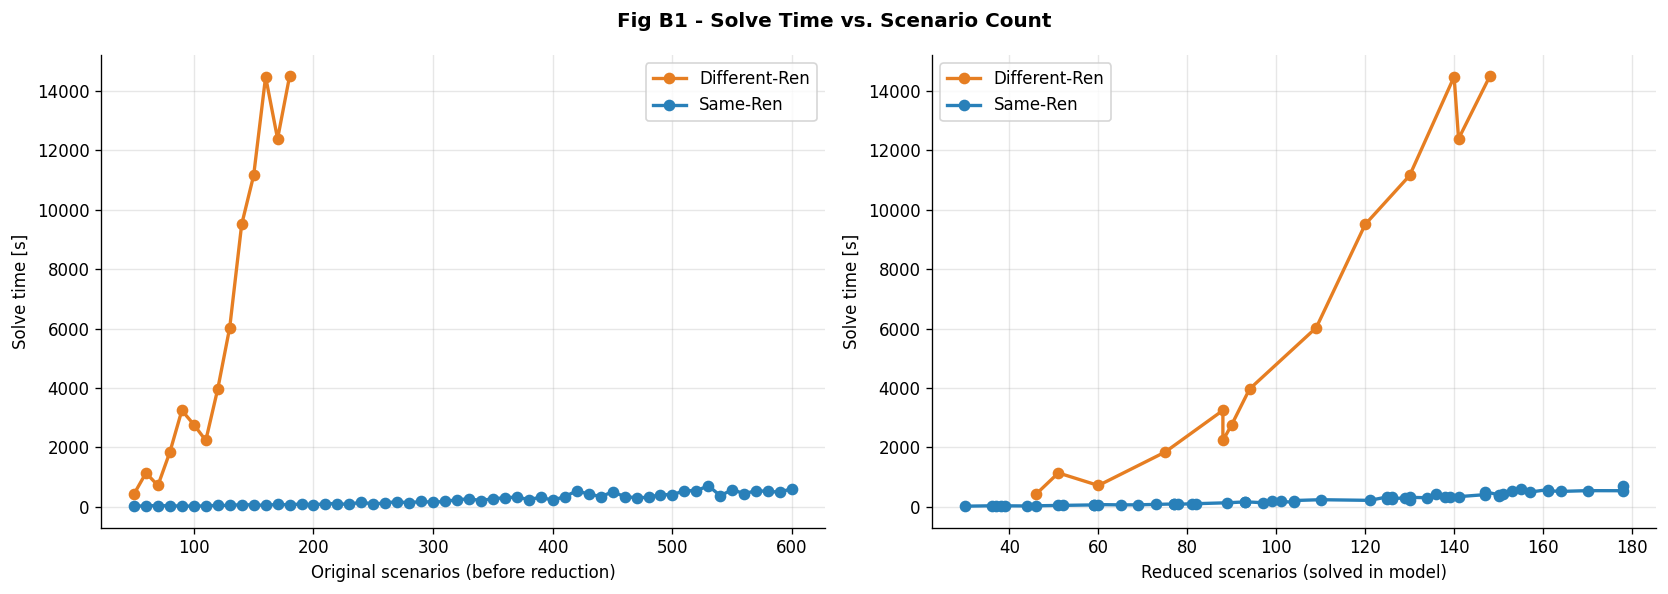

In [38]:
if not batch_ok.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Fig B1 - Solve Time vs. Scenario Count", fontweight="bold")

    for ax, xcol, xlabel in zip(
        axes,
        ["num_scenarios_original", "num_scenarios_reduced"],
        ["Original scenarios (before reduction)", "Reduced scenarios (solved in model)"],
    ):
        for method, g in batch_ok.groupby("method"):
            g = g.sort_values(xcol)
            ax.plot(g[xcol], g["solve_time_s"], marker="o", lw=2,
                    color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Solve time [s]")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    _save(fig, "fig_b1_solve_time_vs_scenarios")
    plt.show()
else:
    print("Skipped: no batch data.")


Original scenario counts completed by BOTH methods so far: [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180]


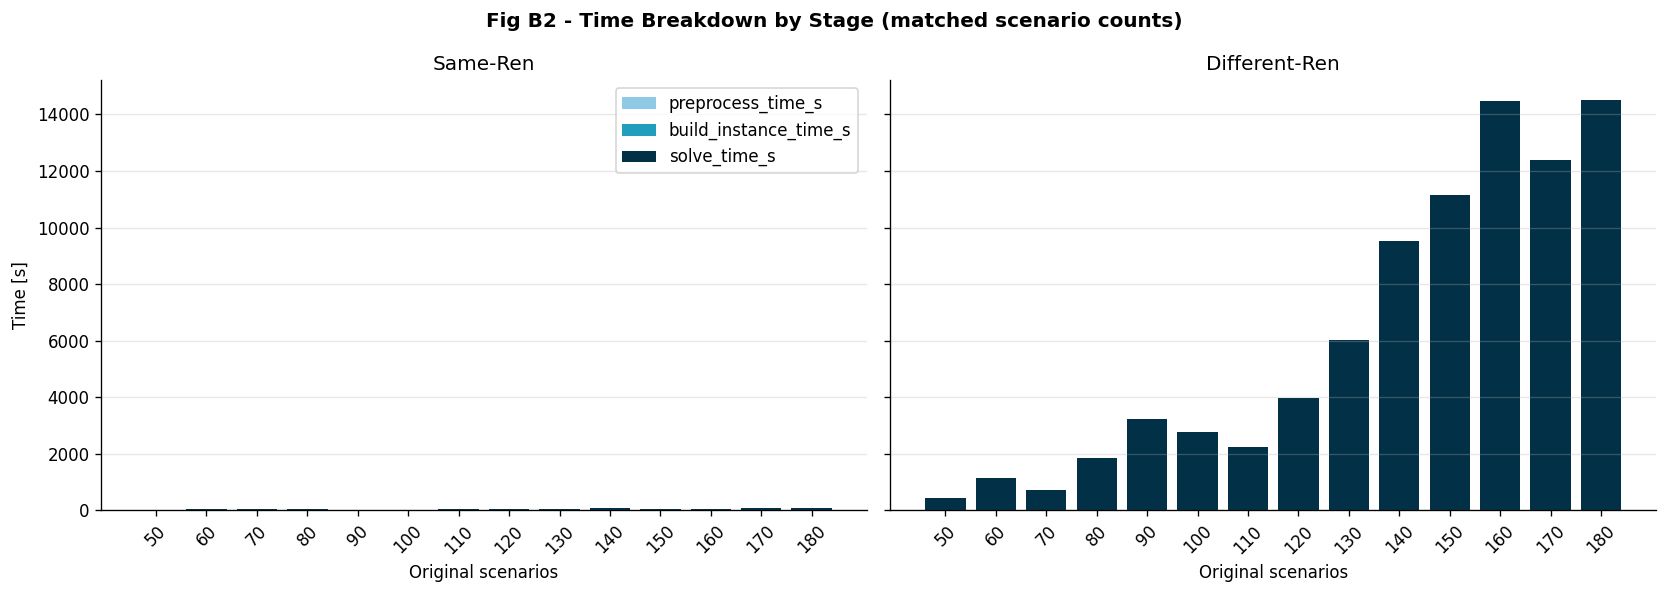

In [39]:
if not batch_ok.empty:
    common_counts = sorted(
        set(batch_ok.loc[batch_ok.method == "same_ren", "num_scenarios_original"])
        & set(batch_ok.loc[batch_ok.method == "dif_ren", "num_scenarios_original"])
    )
    print("Original scenario counts completed by BOTH methods so far:", common_counts)

    if common_counts:
        stage_colors = ["#8ecae6", "#219ebc", "#023047"]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        fig.suptitle("Fig B2 - Time Breakdown by Stage (matched scenario counts)", fontweight="bold")
        for ax, method in zip(axes, ["same_ren", "dif_ren"]):
            g = (batch_ok[batch_ok.method == method]
                 .set_index("num_scenarios_original").reindex(common_counts))
            xpos = np.arange(len(common_counts))
            bottom = np.zeros(len(common_counts))
            for col, color in zip(TIME_COLS[:3], stage_colors):
                vals = g[col].fillna(0).values
                ax.bar(xpos, vals, bottom=bottom, color=color, label=col)
                bottom += vals
            ax.set_xticks(xpos)
            ax.set_xticklabels(common_counts, rotation=45)
            ax.set_title(BATCH_METHOD_LABELS[method])
            ax.set_xlabel("Original scenarios")
            ax.grid(alpha=0.3, axis="y")
        axes[0].set_ylabel("Time [s]")
        axes[0].legend()
        plt.tight_layout()
        _save(fig, "fig_b2_time_breakdown")
        plt.show()
    else:
        print("No overlapping scenario counts between methods yet - re-run later once more jobs finish.")
else:
    print("Skipped: no batch data.")


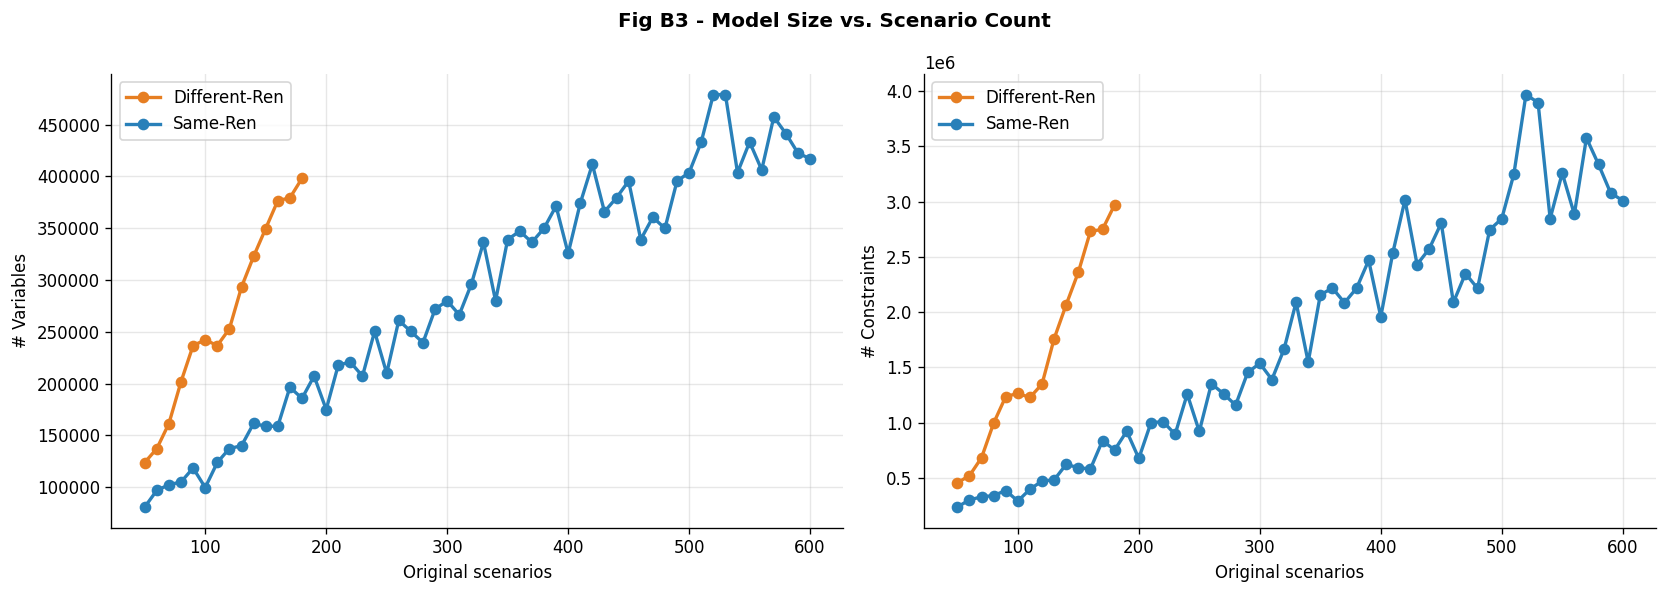

In [40]:
if not batch_ok.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Fig B3 - Model Size vs. Scenario Count", fontweight="bold")
    for ax, col, ylabel in zip(axes, ["num_variables", "num_constraints"], ["# Variables", "# Constraints"]):
        for method, g in batch_ok.groupby("method"):
            g = g.sort_values("num_scenarios_original")
            ax.plot(g["num_scenarios_original"], g[col], marker="o", lw=2,
                    color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
        ax.set_xlabel("Original scenarios")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    _save(fig, "fig_b3_model_size_vs_scenarios")
    plt.show()
else:
    print("Skipped: no batch data.")


### 14.2 · Insight 2 — Objective Function vs. Scenario Count

Compares the total objective value and its income/cost components between the
two methodologies, again as a function of both original and reduced scenario counts.


In [41]:
OBJ_COLS = ["obj_fun", "obj_DA_income", "obj_RM_income", "obj_IM_income",
            "obj_IB_income", "obj_IB_costs", "obj_IB_net", "obj_FD_costs"]

if not batch_ok.empty:
    print("Mean objective-function components by method and original scenario count:")
    obj_table = batch_ok.pivot_table(
        index="num_scenarios_original", columns="method_label", values=OBJ_COLS, aggfunc="mean"
    ).sort_index()
    display(obj_table)
else:
    print("Skipped: no batch data.")


Mean objective-function components by method and original scenario count:


obj_DA_income              obj_FD_costs           \
method_label           Different-Ren    Same-Ren Different-Ren Same-Ren   
num_scenarios_original                                                    
50                       -23149.8766 -32733.4771       95.6519  97.9028   
60                       -27807.5171 -42842.6797       90.1208  88.7609   
70                       -28667.6837 -36699.7345       87.8090  90.5769   
80                       -27688.7611 -41573.9746       92.2943  89.9158   
90                       -31997.7414 -38534.4709       86.5098  92.1522   
100                      -27349.8540 -37814.0079       92.9382  92.7601   
110                      -26636.9929 -38264.2906       91.4043  91.2581   
120                      -27669.4639 -34997.2297       91.6769  88.8577   
130                      -27036.6180 -33289.8385       91.8934  88.0310   
140                      -26696.0541 -35812.1516       91.5016  89.4275   
150                      -29869.1347 -37431.0527       90.9322  89.2713   
160                      -26132.4594 -38284.4070       87.4720  90.3025   
170                      -31100.7123 -34439.0459       90.8892  90.9150   
180                      -28460.0633 -35969.9234       84.1760  88.6319   
190                              NaN -38704.1957           NaN  90.6520   
200                              NaN -39323.1805           NaN  88.7249   
210                              NaN -39894.7983           NaN  90.7176   
220                              NaN -36395.4871           NaN  91.4382   
230                              NaN -35157.6337           NaN  90.8428   
240                              NaN -34367.7902           NaN  90.1199   
250                              NaN -36521.4713           NaN  91.3229   
260                              NaN -36472.5459           NaN  89.6499   
270                              NaN -34195.4648           NaN  90.2383   
280                              NaN -34035.2433           NaN  89.8167   
290                              NaN -35112.6380           NaN  89.7054   
300                              NaN -36090.0520           NaN  90.4414   
310                              NaN -34784.1404           NaN  89.6009   
320                              NaN -34391.0047           NaN  90.7094   
330                              NaN -34067.0044           NaN  88.3133   
340                              NaN -33994.3909           NaN  89.5301   
350                              NaN -33655.7354           NaN  88.6798   
360                              NaN -32056.8203           NaN  87.9616   
370                              NaN -34672.8489           NaN  87.9271   
380                              NaN -35202.3396           NaN  87.5483   
390                              NaN -36216.5621           NaN  88.2462   
400                              NaN -34197.3229           NaN  87.4096   
410                              NaN -35034.1285           NaN  86.9433   
420                              NaN -35336.4369           NaN  88.1011   
430                              NaN -35831.3440           NaN  86.7257   
440                              NaN -35455.7393           NaN  88.5561   
450                              NaN -35605.9884           NaN  87.8658   
460                              NaN -35319.5068           NaN  87.7947   
470                              NaN -36156.3419           NaN  88.2376   
480                              NaN -34912.7233           NaN  87.9826   
490                              NaN -34252.2839           NaN  87.7857   
500                              NaN -36019.9252           NaN  86.6395   
510                              NaN -33703.4693           NaN  86.2315   
520                              NaN -35949.2603           NaN  86.5366   
530                              NaN -33791.9945           NaN  87.0985   
540                              NaN -33047.3994           NaN  87.4169   
550                              NaN -34033.8604

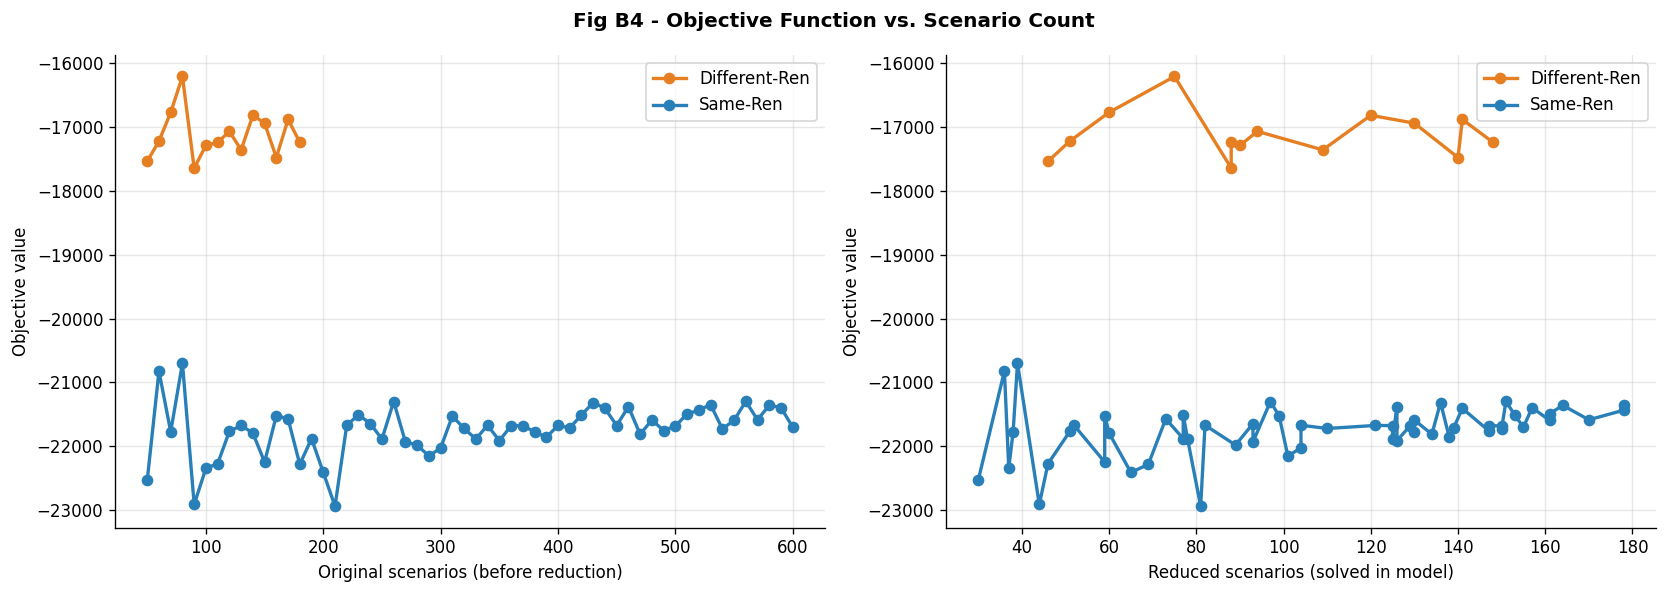

In [42]:
if not batch_ok.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Fig B4 - Objective Function vs. Scenario Count", fontweight="bold")
    for ax, xcol, xlabel in zip(
        axes,
        ["num_scenarios_original", "num_scenarios_reduced"],
        ["Original scenarios (before reduction)", "Reduced scenarios (solved in model)"],
    ):
        for method, g in batch_ok.groupby("method"):
            g = g.sort_values(xcol)
            ax.plot(g[xcol], g["obj_fun"], marker="o", lw=2,
                    color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Objective value")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    _save(fig, "fig_b4_objective_vs_scenarios")
    plt.show()
else:
    print("Skipped: no batch data.")


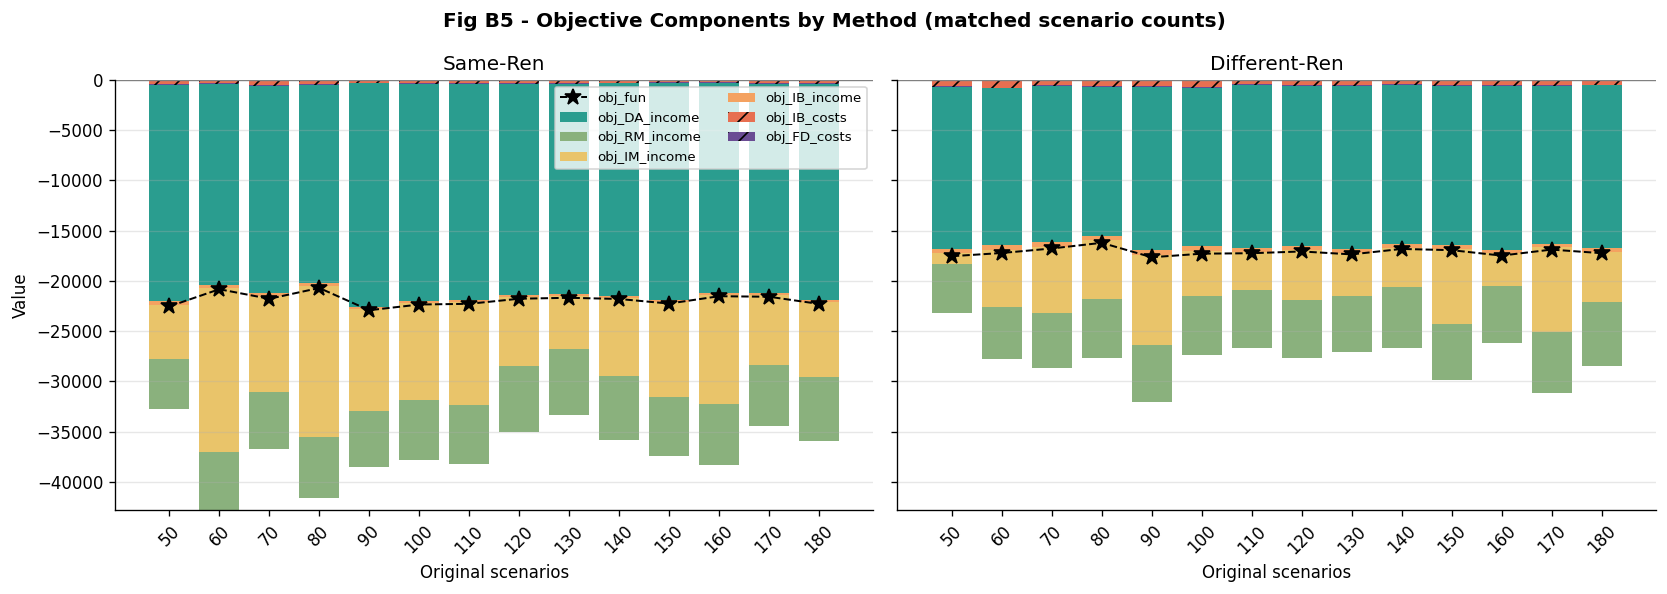

In [43]:
if not batch_ok.empty and common_counts:
    income_cols = ["obj_DA_income", "obj_RM_income", "obj_IM_income", "obj_IB_income"]
    cost_cols = ["obj_IB_costs", "obj_FD_costs"]
    income_colors = ["#2a9d8f", "#8ab17d", "#e9c46a", "#f4a261"]
    cost_colors = ["#e76f51", "#6a4c93"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle("Fig B5 - Objective Components by Method (matched scenario counts)", fontweight="bold")
    for ax, method in zip(axes, ["same_ren", "dif_ren"]):
        g = (batch_ok[batch_ok.method == method]
             .set_index("num_scenarios_original").reindex(common_counts))
        xpos = np.arange(len(common_counts))

        bottom = np.zeros(len(common_counts))
        for col, color in zip(income_cols, income_colors):
            vals = g[col].fillna(0).values
            ax.bar(xpos, vals, bottom=bottom, color=color, label=col)
            bottom += vals

        bottom = np.zeros(len(common_counts))
        for col, color in zip(cost_cols, cost_colors):
            vals = -g[col].fillna(0).values  # costs plotted as negative bars
            ax.bar(xpos, vals, bottom=bottom, color=color, label=col, hatch="//")
            bottom += vals

        ax.plot(xpos, g["obj_fun"].values, "k*--", lw=1.2, ms=10, label="obj_fun")
        ax.axhline(0, color="grey", lw=0.8)
        ax.set_xticks(xpos)
        ax.set_xticklabels(common_counts, rotation=45)
        ax.set_title(BATCH_METHOD_LABELS[method])
        ax.set_xlabel("Original scenarios")
        ax.grid(alpha=0.3, axis="y")
    axes[0].set_ylabel("Value")
    axes[0].legend(fontsize=8, ncol=2)
    plt.tight_layout()
    _save(fig, "fig_b5_objective_components")
    plt.show()
else:
    print("Skipped: no batch data or no overlapping scenario counts yet.")


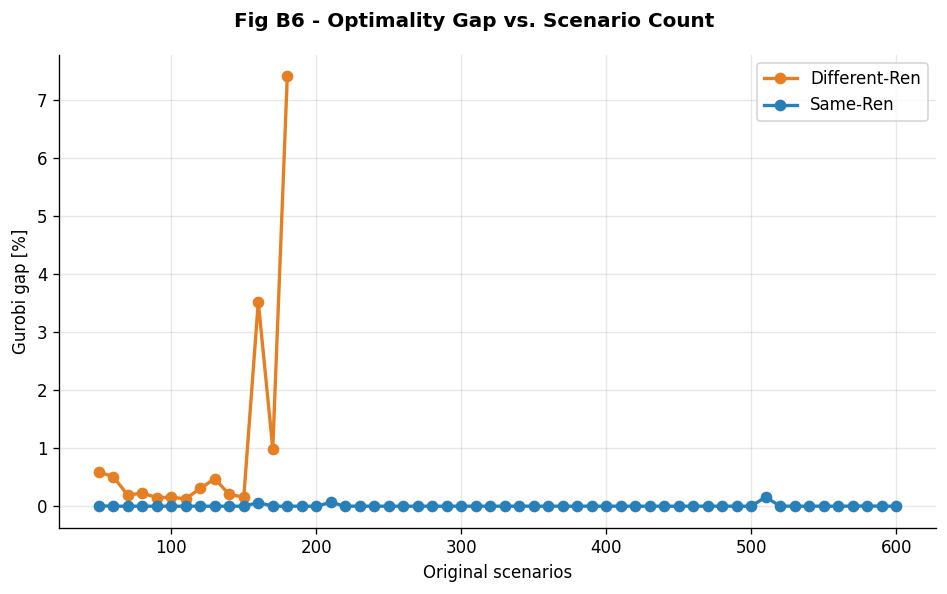

In [44]:
if not batch_ok.empty and batch_ok["gurobi_gap_pct"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle("Fig B6 - Optimality Gap vs. Scenario Count", fontweight="bold")
    for method, g in batch_ok.groupby("method"):
        g = g.sort_values("num_scenarios_original")
        ax.plot(g["num_scenarios_original"], g["gurobi_gap_pct"], marker="o", lw=2,
                color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
    ax.set_xlabel("Original scenarios")
    ax.set_ylabel("Gurobi gap [%]")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    _save(fig, "fig_b6_optimality_gap")
    plt.show()
else:
    print("Skipped: no gap data available.")


### 14.3 · Insight 3 — Day-Ahead Commitment Comparison

Compares the actual DA commitments (`eDA_p` = sold, `eDA_m` = bought) produced by
each methodology, matched at the **same** (or closest) original scenario count so
the comparison isolates the effect of the reduction method rather than scenario count.

Each run's `results_dir` (from the batch CSV, e.g. `.../DA/ec/001`) is converted to
its sibling market-results folder (`.../DA/market/001/DA/eDA_p.txt`) where the
per-scenario, per-period commitments are stored as one row per (reduced) scenario:
`scenario_id  probability  v_t=1 ... v_t=T`. Profiles below are probability-weighted
means across scenarios.


In [45]:
def _da_market_dir(results_dir):
    # '.../<famscen>/DA/ec/<sim>' -> '.../<famscen>/DA/market/<sim>' (see simulation_context.py)
    results_dir = str(results_dir)
    marker = os.sep + "ec" + os.sep
    if marker not in results_dir:
        return None
    return results_dir.replace(marker, os.sep + "market" + os.sep)


def load_da_commitment(results_dir, filename):
    # eDA_p.txt / eDA_m.txt: rows = reduced scenarios, cols = [id, prob, v_t=1..T]
    market_dir = _da_market_dir(results_dir)
    if market_dir is None:
        return None
    path = os.path.join(market_dir, "DA", filename)
    if not os.path.isfile(path):
        return None
    df = pd.read_csv(path, sep=r"\s+", header=None, engine="python")
    if df.shape[1] < 3:
        return None
    probs = df.iloc[:, 1].to_numpy(dtype=float)
    values = df.iloc[:, 2:].to_numpy(dtype=float)
    if probs.sum() > 0 and not np.isclose(probs.sum(), 1.0, atol=1e-3):
        probs = probs / probs.sum()
    return probs, values  # probs: (S,), values: (S, T)


def weighted_commitment_profile(results_dir):
    # Probability-weighted mean eDA_p, eDA_m and net (sold - bought) profile over T periods.
    p = load_da_commitment(results_dir, "eDA_p.txt")
    m = load_da_commitment(results_dir, "eDA_m.txt")
    if p is None or m is None:
        return None
    probs_p, vals_p = p
    probs_m, vals_m = m
    mean_p = (probs_p[:, None] * vals_p).sum(axis=0)
    mean_m = (probs_m[:, None] * vals_m).sum(axis=0)
    return mean_p, mean_m, mean_p - mean_m

print("Commitment-loading helpers ready.")


Commitment-loading helpers ready.


In [46]:
commit_records = []
if not batch_ok.empty:
    for _, row in batch_ok.iterrows():
        prof = weighted_commitment_profile(row["results_dir"])
        if prof is None:
            continue
        mean_p, mean_m, net = prof
        dt_h = 24.0 / len(mean_p)  # hours per period (e.g. 0.25 for 15-min, 96 periods)
        commit_records.append({
            "method": row["method"],
            "num_scenarios_original": row["num_scenarios_original"],
            "num_scenarios_reduced": row["num_scenarios_reduced"],
            "results_dir": row["results_dir"],
            "T_periods": len(mean_p),
            "total_sold_MWh": mean_p.sum() * dt_h,
            "total_bought_MWh": mean_m.sum() * dt_h,
            "net_MWh": net.sum() * dt_h,
            "peak_sold_MW": mean_p.max(),
            "peak_bought_MW": mean_m.max(),
        })

commit_df = pd.DataFrame(commit_records)
if not commit_df.empty:
    commit_df["method_label"] = commit_df["method"].map(BATCH_METHOD_LABELS)
    commit_df = commit_df.sort_values(["method", "num_scenarios_original"]).reset_index(drop=True)

print(f"Loaded commitment profiles for {len(commit_df)} / {len(batch_ok)} 'ok' runs.")
if not commit_df.empty:
    display(commit_df.drop(columns=["results_dir"]).head(10))


Loaded commitment profiles for 70 / 70 'ok' runs.


,method,num_scenarios_original,num_scenarios_reduced,T_periods,total_sold_MWh,total_bought_MWh,net_MWh,peak_sold_MW,peak_bought_MW,method_label
0,dif_ren,50,46,96,0.4661,100.2616,-99.7955,0.3875,11.0300,Different-Ren
1,dif_ren,60,51,96,0.3765,117.9171,-117.5405,0.3675,11.0300,Different-Ren
2,dif_ren,70,60,96,0.3534,121.5842,-121.2309,0.3428,11.0300,Different-Ren
3,dif_ren,80,75,96,0.3668,118.3809,-118.0142,0.3768,11.0300,Different-Ren
4,dif_ren,90,88,96,0.3455,128.4372,-128.0918,0.4318,11.0300,Different-Ren
5,dif_ren,100,90,96,0.1660,117.1081,-116.9421,0.3809,11.0300,Different-Ren
6,dif_ren,110,88,96,0.2971,114.4724,-114.1753,0.2788,11.0300,Different-Ren
7,dif_ren,120,94,96,0.3943,119.1274,-118.7331,0.3849,11.0300,Different-Ren
8,dif_ren,130,109,96,0.4619,116.1103,-115.6484,0.4387,11.0300,Different-Ren
9,dif_ren,140,120,96,0.3470,114.8498,-114.5028,0.4093,11.0300,Different-Ren


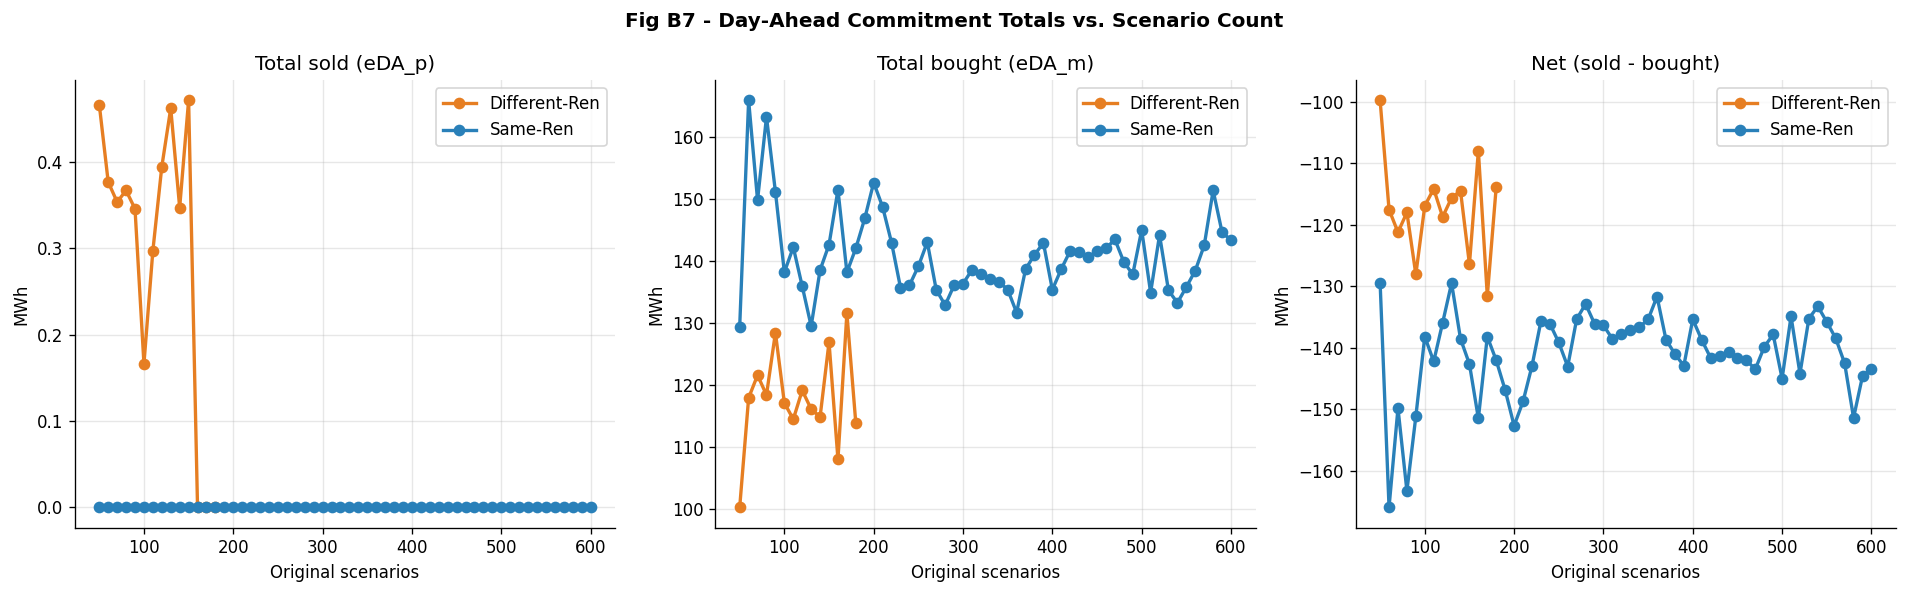

In [47]:
if not commit_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Fig B7 - Day-Ahead Commitment Totals vs. Scenario Count", fontweight="bold")
    for ax, col, title in zip(
        axes,
        ["total_sold_MWh", "total_bought_MWh", "net_MWh"],
        ["Total sold (eDA_p)", "Total bought (eDA_m)", "Net (sold - bought)"],
    ):
        for method, g in commit_df.groupby("method"):
            g = g.sort_values("num_scenarios_original")
            ax.plot(g["num_scenarios_original"], g[col], marker="o", lw=2,
                    color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
        ax.set_title(title)
        ax.set_xlabel("Original scenarios")
        ax.set_ylabel("MWh")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    _save(fig, "fig_b7_commitment_totals")
    plt.show()
else:
    print("Skipped: no commitment data available yet (result files not generated, or path pattern mismatch).")


Scenario counts shown (matched between methods): [50, 80, 100, 130, 150, 180]


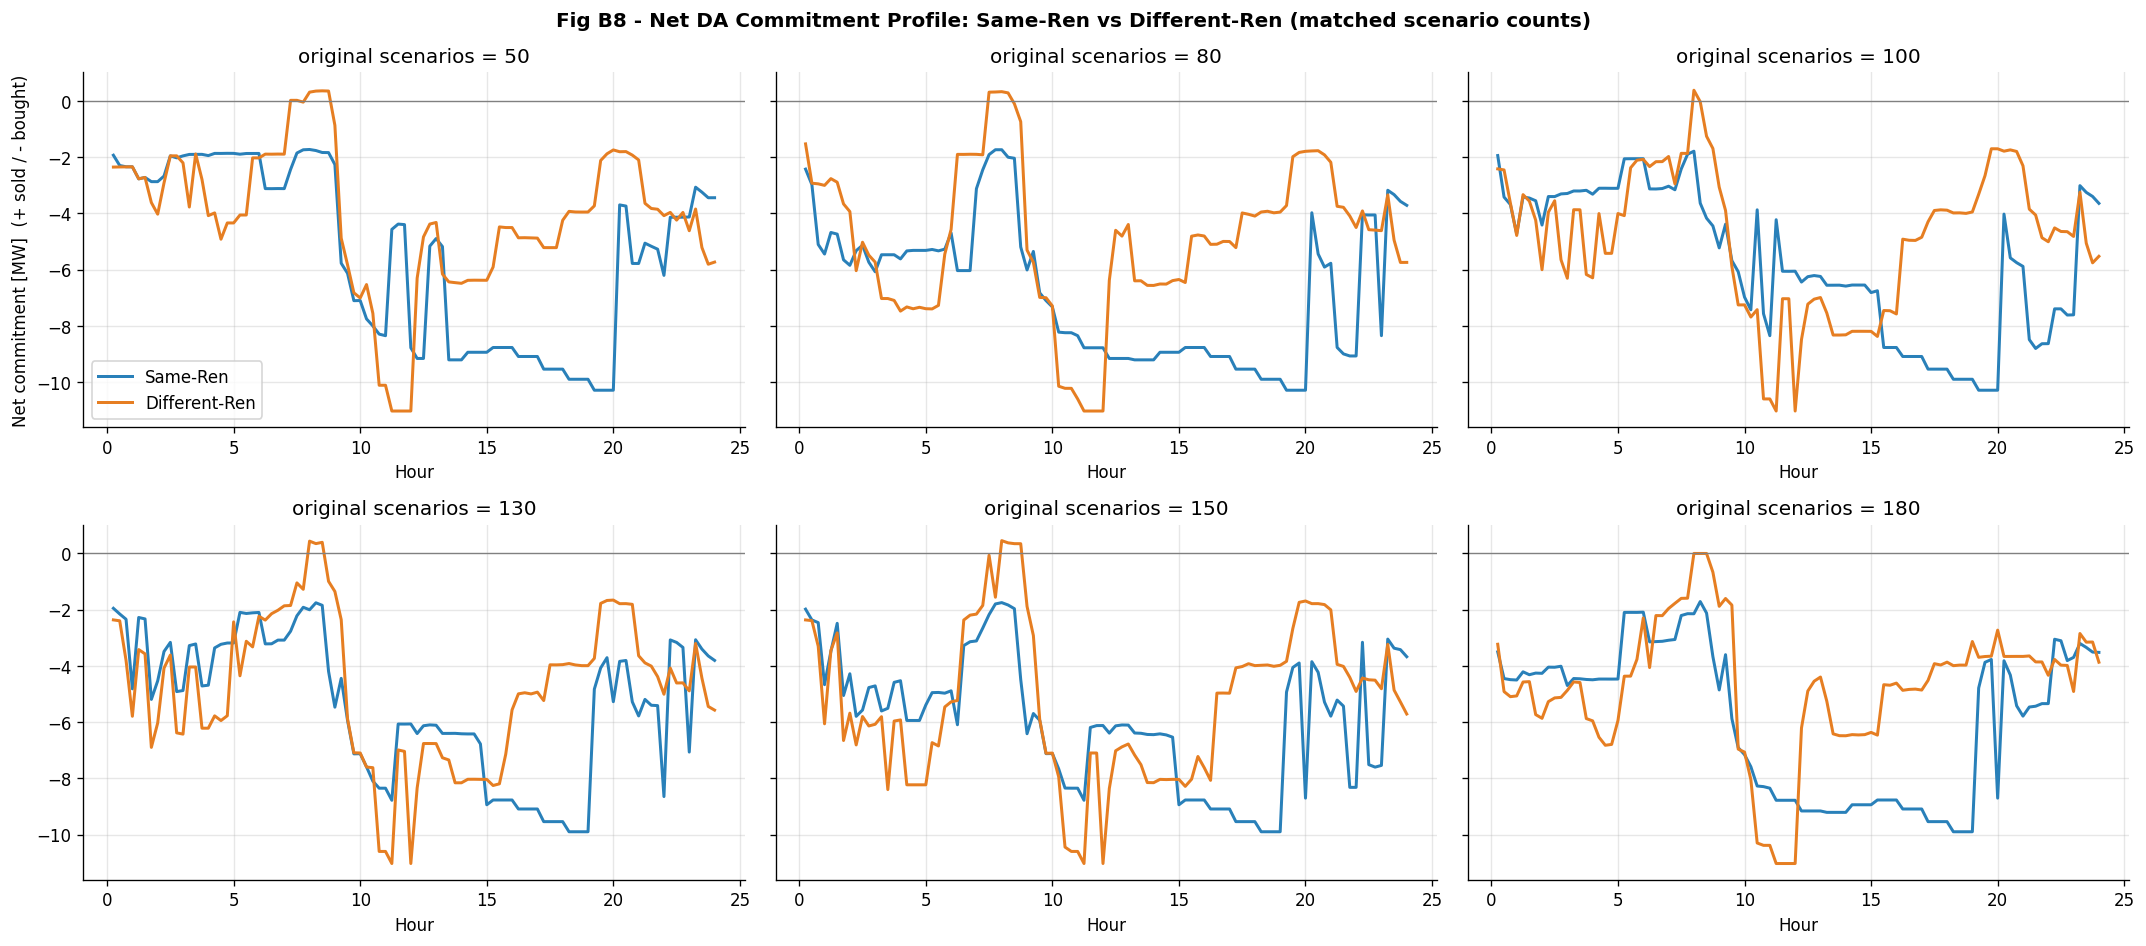

In [48]:
if not commit_df.empty:
    matched_counts = sorted(
        set(commit_df.loc[commit_df.method == "same_ren", "num_scenarios_original"])
        & set(commit_df.loc[commit_df.method == "dif_ren", "num_scenarios_original"])
    )
    show_counts = matched_counts
    if len(matched_counts) > 6:
        idx = np.linspace(0, len(matched_counts) - 1, 6).round().astype(int)
        show_counts = [matched_counts[i] for i in sorted(set(idx))]
    print("Scenario counts shown (matched between methods):", show_counts)

    if show_counts:
        ncols = min(3, len(show_counts))
        nrows = int(np.ceil(len(show_counts) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=True, squeeze=False)
        axes = axes.flatten()
        fig.suptitle("Fig B8 - Net DA Commitment Profile: Same-Ren vs Different-Ren (matched scenario counts)",
                     fontweight="bold")
        for ax, sc in zip(axes, show_counts):
            for method in ["same_ren", "dif_ren"]:
                r = batch_ok[(batch_ok.method == method) & (batch_ok.num_scenarios_original == sc)]
                if r.empty:
                    continue
                prof = weighted_commitment_profile(r.iloc[0]["results_dir"])
                if prof is None:
                    continue
                _, _, net = prof
                t = np.arange(1, len(net) + 1) * (24.0 / len(net))
                ax.plot(t, net, lw=1.8, color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
            ax.axhline(0, color="grey", lw=0.8)
            ax.set_title(f"original scenarios = {sc}")
            ax.set_xlabel("Hour")
            ax.grid(alpha=0.3)
        axes[0].set_ylabel("Net commitment [MW]  (+ sold / - bought)")
        axes[0].legend()
        for ax in axes[len(show_counts):]:
            ax.axis("off")
        plt.tight_layout()
        _save(fig, "fig_b8_commitment_profiles")
        plt.show()
    else:
        print("No scenario count is present for both methods yet - re-run later.")
else:
    print("Skipped: no commitment data.")


,num_scenarios_original,mean_abs_diff_MW
0,50,2.4237
1,60,2.9014
2,70,2.4560
3,80,2.8110
4,90,2.5094
5,100,2.4422
6,110,2.1926
7,120,2.2195
8,130,1.9398
9,140,2.0376


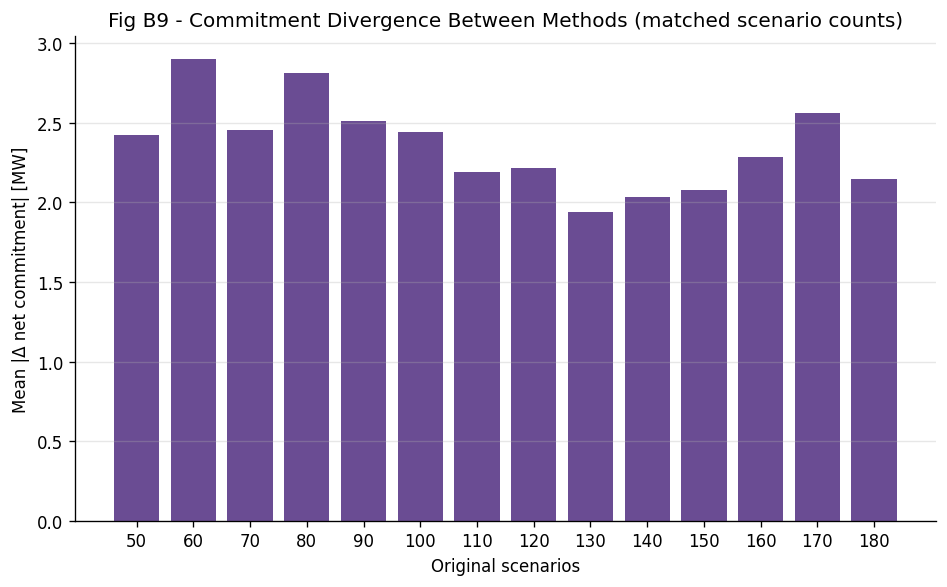

In [49]:
if not commit_df.empty and matched_counts:
    diffs = []
    for sc in matched_counts:
        profiles = {}
        for method in ["same_ren", "dif_ren"]:
            r = batch_ok[(batch_ok.method == method) & (batch_ok.num_scenarios_original == sc)]
            if r.empty:
                continue
            prof = weighted_commitment_profile(r.iloc[0]["results_dir"])
            if prof is None:
                continue
            profiles[method] = prof[2]  # net profile
        if "same_ren" in profiles and "dif_ren" in profiles and \
                len(profiles["same_ren"]) == len(profiles["dif_ren"]):
            mad = float(np.mean(np.abs(profiles["same_ren"] - profiles["dif_ren"])))
            diffs.append({"num_scenarios_original": sc, "mean_abs_diff_MW": mad})

    diff_df = pd.DataFrame(diffs)
    display(diff_df)

    if not diff_df.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(diff_df["num_scenarios_original"].astype(str), diff_df["mean_abs_diff_MW"], color="#6a4c93")
        ax.set_xlabel("Original scenarios")
        ax.set_ylabel("Mean |Δ net commitment| [MW]")
        ax.set_title("Fig B9 - Commitment Divergence Between Methods (matched scenario counts)")
        ax.grid(alpha=0.3, axis="y")
        plt.tight_layout()
        _save(fig, "fig_b9_commitment_divergence")
        plt.show()
else:
    print("Skipped: no matched scenario counts with commitment data yet.")


### 14.4 · Additional Metrics

A few extra diagnostics that are useful when judging which reduction method is
"better" beyond the three requested comparisons:

- **Reduction ratio** — how aggressively each method prunes the original scenario tree.
- **Solve time per (reduced) scenario** — a size-normalized efficiency metric, since
  `dif_ren` and `same_ren` can keep a different number of scenarios for the same
  original count.
- **Run-status summary** — surfaces any `error` / `timeout_no_solution` rows so
  incomplete batches are visible at a glance.


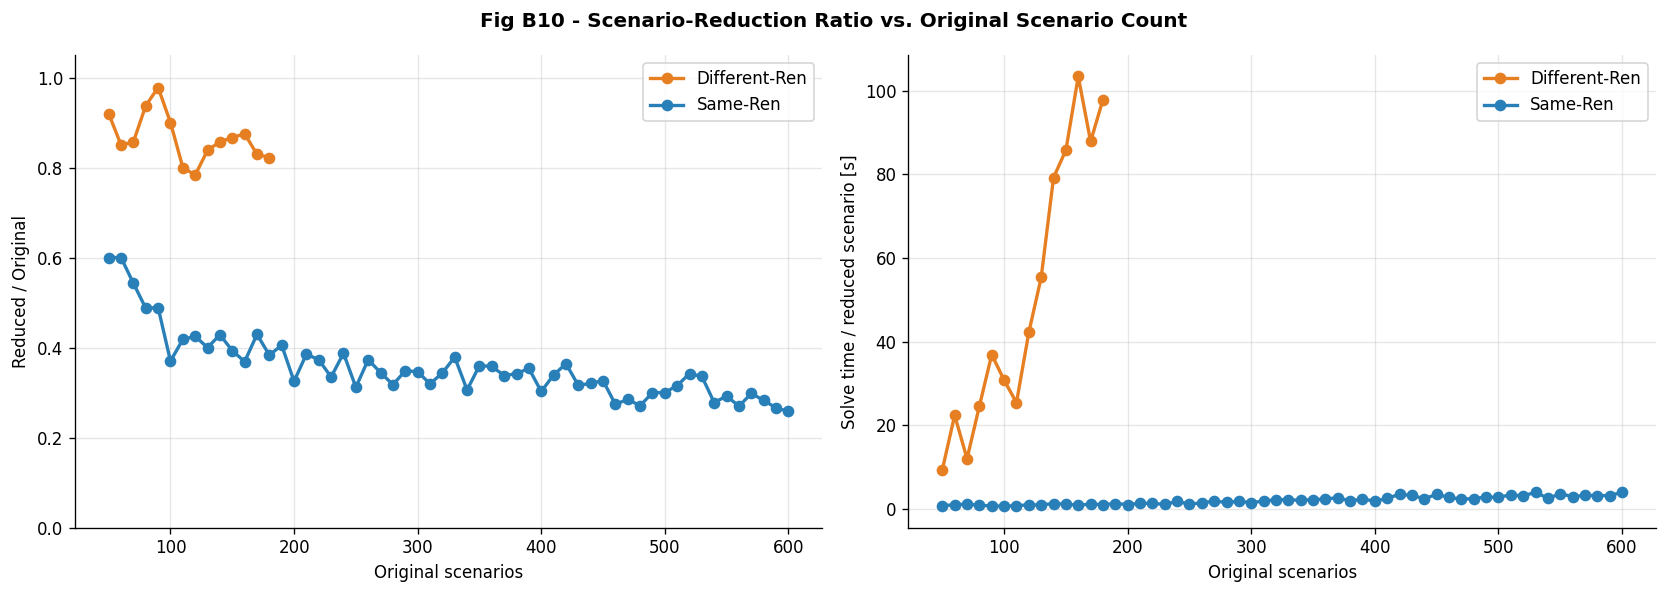

In [50]:
if not batch_ok.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Fig B10 - Scenario-Reduction Ratio vs. Original Scenario Count", fontweight="bold")

    ax = axes[0]
    for method, g in batch_ok.groupby("method"):
        g = g.sort_values("num_scenarios_original")
        ax.plot(g["num_scenarios_original"], g["reduction_ratio"], marker="o", lw=2,
                color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
    ax.set_xlabel("Original scenarios")
    ax.set_ylabel("Reduced / Original")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend()

    ax = axes[1]
    for method, g in batch_ok.groupby("method"):
        g = g.sort_values("num_scenarios_original")
        ax.plot(g["num_scenarios_original"], g["solve_time_per_scenario_s"], marker="o", lw=2,
                color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
    ax.set_xlabel("Original scenarios")
    ax.set_ylabel("Solve time / reduced scenario [s]")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    _save(fig, "fig_b10_reduction_ratio_and_efficiency")
    plt.show()
else:
    print("Skipped: no batch data.")


In [51]:
if not batch_latest.empty:
    print("Run-status summary by method (latest attempt per scenario-count folder):")
    display(batch_latest.groupby(["method", "status"]).size().rename("n_runs").to_frame())

    if not batch_not_ok.empty:
        print("\nNon-'ok' runs - latest attempt only (inspect 'error' for details):")
        display(batch_not_ok[["method", "num_scenarios_folder", "status",
                               "time_limit_s", "solve_time_s", "error"]]
                .sort_values(["method", "num_scenarios_folder"]))
    else:
        print("\nAll loaded scenario-count folders completed with status 'ok'.")
else:
    print("Skipped: no batch data.")


Run-status summary by method (latest attempt per scenario-count folder):


n_runs
method   status                     
dif_ren  ok                       14
         timeout_no_solution      12
same_ren ok                       56


Non-'ok' runs - latest attempt only (inspect 'error' for details):


,method,num_scenarios_folder,status,time_limit_s,solve_time_s,error
70,dif_ren,190,timeout_no_solution,14400,14490.6919,ValueError: Cannot load a SolverResults object...
71,dif_ren,200,timeout_no_solution,14400,14504.2288,ValueError: Cannot load a SolverResults object...
72,dif_ren,210,timeout_no_solution,14400,14521.3099,ValueError: Cannot load a SolverResults object...
73,dif_ren,220,timeout_no_solution,14400,14541.4190,ValueError: Cannot load a SolverResults object...
74,dif_ren,230,timeout_no_solution,14400,14531.5033,ValueError: Cannot load a SolverResults object...
75,dif_ren,240,timeout_no_solution,14400,14576.0431,ValueError: Cannot load a SolverResults object...
76,dif_ren,250,timeout_no_solution,14400,14541.7413,ValueError: Cannot load a SolverResults object...
77,dif_ren,260,timeout_no_solution,14400,14552.7299,ValueError: Cannot load a SolverResults object...
78,dif_ren,270,timeout_no_solution,14400,14558.7748,ValueError: Cannot load a SolverResults object...
79,dif_ren,280,timeout_no_solution,14400,14571.5909,ValueError: Cannot load a SolverResults object...


### 14.5 · Export Batch Summary Tables


In [52]:
if CONFIG["save_figs"]:
    os.makedirs(CONFIG["fig_dir"], exist_ok=True)
    if not batch_ok.empty:
        out1 = os.path.join(CONFIG["fig_dir"], "batch_summary.csv")
        batch_ok.drop(columns=[c for c in ["traceback"] if c in batch_ok.columns]).to_csv(out1, index=False)
        print(f"Saved -> {out1}")
    if not commit_df.empty:
        out2 = os.path.join(CONFIG["fig_dir"], "commitment_summary.csv")
        commit_df.drop(columns=["results_dir"]).to_csv(out2, index=False)
        print(f"Saved -> {out2}")
else:
    print("Set CONFIG['save_figs'] = True to export batch_summary.csv / commitment_summary.csv.")


Saved -> figures/batch_comparison/batch_summary.csv
Saved -> figures/batch_comparison/commitment_summary.csv


### 14.6 · Insight 4 — Scenario-Tree Structure vs Solve Outcome

Ties the batch results above to the scenario trees' own structural properties, computed
independently in `analisis_scenario_generation.ipynb` (`Results/Scenario tree results/
scenario_tree_summary.csv`). This explains *why* `dif_ren` times out where it does
(§14.1), rather than only observing *that* it does: `dif_ren` branches renewable data
every 15 minutes instead of hourly, so its tree already has far more nodes at the same
nominal scenario count than `same_ren` -- the same mechanism that keeps its
post-reduction probability mass close to uniform is what makes the resulting model
intractable past a fairly low count.

A more rigorous, 30-day-mean, matched-retained-count version of this same comparison
(`tab:cliff`, `fig:sg-cliff`) lives in `Results/Execution of model/
section_4_2_results_of_simulations.ipynb` §0.2b; this section is the same idea at
exploratory/single-day grain, using the raw per-run batch data already loaded above.

In [53]:
TREE_SUMMARY_CANDIDATES = [
    os.path.join("..", "Scenario tree results", "scenario_tree_summary.csv"),
    os.path.join("..", "Results", "Scenario tree results", "scenario_tree_summary.csv"),
    "scenario_tree_summary.csv",
]
_tree_summary_path = next((p for p in TREE_SUMMARY_CANDIDATES if os.path.isfile(p)), None)

if _tree_summary_path is None or batch_ok.empty:
    print("Skipped: scenario_tree_summary.csv not found, or no batch data.")
    struct_agg = pd.DataFrame()
    joined = pd.DataFrame()
else:
    tree_summary = pd.read_csv(_tree_summary_path)
    struct_agg = (tree_summary.groupby(["method", "sc_folder"])
                  [["num_nodes", "num_tree_stages", "effective_num_scenarios", "prob_max"]]
                  .mean()
                  .reset_index()
                  .rename(columns={"sc_folder": "num_scenarios_original"}))

    joined = batch_ok.merge(struct_agg, on=["method", "num_scenarios_original"], how="left")
    print(f"Loaded {_tree_summary_path}: {len(tree_summary)} raw tree rows -> "
          f"{len(struct_agg)} (method, scenario-count) means; joined onto {len(joined)} batch rows.")
    display(joined[["method_label", "num_scenarios_original", "num_scenarios_reduced",
                     "solve_time_s", "obj_fun", "num_nodes", "effective_num_scenarios"]]
            .sort_values(["method_label", "num_scenarios_original"]).head(10))

Loaded ../Scenario tree results/scenario_tree_summary.csv: 2542 raw tree rows -> 82 (method, scenario-count) means; joined onto 70 batch rows.


,method_label,num_scenarios_original,num_scenarios_reduced,solve_time_s,obj_fun,num_nodes,effective_num_scenarios
0,Different-Ren,50,46,429.4159,-17533.5596,2407.0645,39.6839
1,Different-Ren,60,51,1141.2002,-17217.3172,3633.6774,44.6883
2,Different-Ren,70,60,718.5871,-16767.1685,3550.2581,51.9556
3,Different-Ren,80,75,1842.9654,-16204.0603,3888.0968,58.4396
4,Different-Ren,90,88,3246.5755,-17639.6899,5482.2258,68.4235
5,Different-Ren,100,90,2768.9630,-17285.6471,5639.1613,69.2714
6,Different-Ren,110,88,2234.0260,-17238.0188,6122.0000,71.8004
7,Different-Ren,120,94,3965.8847,-17064.2837,6592.2903,72.8027
8,Different-Ren,130,109,6032.0257,-17354.7551,6627.9032,87.2485
9,Different-Ren,140,120,9506.0070,-16813.0243,7053.8710,83.8042


In [54]:
if not struct_agg.empty:
    attempted = (batch_latest[["method", "num_scenarios_folder", "status"]]
                 .rename(columns={"num_scenarios_folder": "num_scenarios_original"}))
    coverage = attempted.merge(struct_agg, on=["method", "num_scenarios_original"], how="left")
    print("dif_ren status vs. tree structure (all attempted scenario counts):")
    display(coverage[coverage["method"] == "dif_ren"]
            .sort_values("num_scenarios_original")
            [["num_scenarios_original", "status", "num_nodes", "effective_num_scenarios"]])
else:
    print("Skipped: no tree structure data.")

dif_ren status vs. tree structure (all attempted scenario counts):


,num_scenarios_original,status,num_nodes,effective_num_scenarios
56,50,ok,2407.0645,39.6839
58,60,ok,3633.6774,44.6883
57,70,ok,3550.2581,51.9556
59,80,ok,3888.0968,58.4396
62,90,ok,5482.2258,68.4235
61,100,ok,5639.1613,69.2714
60,110,ok,6122.0000,71.8004
63,120,ok,6592.2903,72.8027
64,130,ok,6627.9032,87.2485
65,140,ok,7053.8710,83.8042


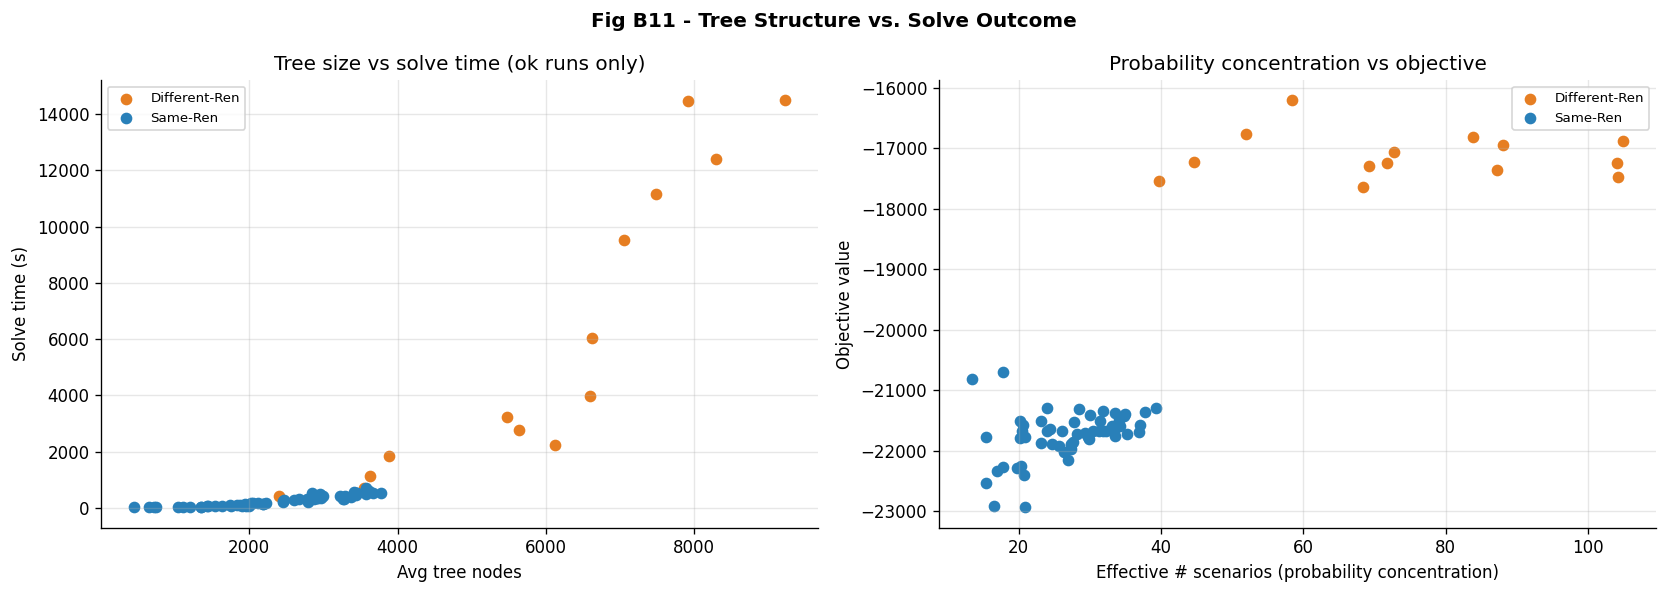

In [55]:
if not joined.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Fig B11 - Tree Structure vs. Solve Outcome", fontweight="bold")
    for method, g in joined.groupby("method"):
        axes[0].scatter(g["num_nodes"], g["solve_time_s"],
                         color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
        axes[1].scatter(g["effective_num_scenarios"], g["obj_fun"],
                         color=BATCH_METHOD_COLORS[method], label=BATCH_METHOD_LABELS[method])
    axes[0].set_xlabel("Avg tree nodes")
    axes[0].set_ylabel("Solve time (s)")
    axes[0].set_title("Tree size vs solve time (ok runs only)")
    axes[1].set_xlabel("Effective # scenarios (probability concentration)")
    axes[1].set_ylabel("Objective value")
    axes[1].set_title("Probability concentration vs objective")
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    _save(fig, "fig_b11_tree_structure_vs_outcome")
    plt.show()
else:
    print("Skipped: nothing to plot.")

**Reading this:** `dif_ren`'s timeouts start right around the scenario counts where its
tree already has thousands more nodes than `same_ren` at the same nominal scenario
count -- the finer 15-minute renewable branching that gives it a near-uniform
post-reduction probability distribution is the same mechanism making the resulting
model intractable past a fairly low count. The two methods sit at different points on
the same trade-off: `same_ren` buys solvability by concentrating probability onto few
scenarios early, `dif_ren` buys resolution/uniformity by growing the tree, and pays for
it in solve time.